In [1]:
import pandas as pd
import subprocess
import os
from pathlib import Path
from collections import defaultdict

In [2]:
PLINK2_PATH = "/opt/conda/envs/mf_cm/bin/plink2"

In [4]:
import numpy as np

OUTPUT_DIR = "/home/jupyter/variant_counts"

myh7_file = "/home/jupyter/MYH7_var.txt" 
myh7_variants = pd.read_csv(myh7_file, header=None, names=['variant_id'])
print(f"Loaded {len(myh7_variants)} MYH7 variants")

hcm_ids = pd.read_csv('/home/jupyter/prs_output/hcm_cohort.keep', sep='\s+', header=None, names=['IID', 'FID'])
hcm_iid_set = set(hcm_ids['IID'].astype(str))

variant_file = f"{OUTPUT_DIR}/myh7_variants_to_extract.txt"
myh7_variants.to_csv(variant_file, header=False, index=False)
print(f"Created variant list: {variant_file}")

chrom_dir = f"/home/jupyter/gcs/chrom-14/postproc-pgen"
pfile_prefix = f"{chrom_dir}/dragen"
output_prefix = f"{OUTPUT_DIR}/myh7_dosages"

cmd = [
    PLINK2_PATH,
    "--pfile", pfile_prefix,
    "--extract", variant_file,
    "--export", "A",
    "--out", output_prefix
]

result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)

dosage_file = f"{OUTPUT_DIR}/myh7_dosages.raw"
dosages = pd.read_csv(dosage_file, sep='\s+')

print(f" Loaded dosages: {dosages.shape}")
print(f"  Total samples: {len(dosages)}")

standard_cols = ['FID', 'IID', 'PAT', 'MAT', 'SEX', 'PHENOTYPE']
variant_cols = [col for col in dosages.columns if col not in standard_cols]
print(f"  Variants extracted: {len(variant_cols)}")


Loaded 30 MYH7 variants
Created variant list: /home/jupyter/variant_counts/myh7_variants_to_extract.txt
PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /home/jupyter/variant_counts/myh7_dosages.log.
Options in effect:
  --export A
  --extract /home/jupyter/variant_counts/myh7_variants_to_extract.txt
  --out /home/jupyter/variant_counts/myh7_dosages
  --pfile /home/jupyter/gcs/chrom-14/postproc-pgen/dragen

Start time: Tue Jul  7 20:32:13 2026
64317 MiB RAM detected, ~61447 available; reserving 32158 MiB for main
workspace.
Using up to 16 threads (change this with --threads).
250115 samples (144800 females, 105310 males, 5 ambiguous; 250115 founders)
loaded from /home/jupyter/gcs/chrom-14/postproc-pgen/dragen.psam.
31208015 variants loaded from
/home/jupyter/gcs/chrom-14/postproc-pgen/dragen.pvar.
Note: No phenotype data present.
--extract: 20 variants remaining.
20 v

In [8]:
# Invert dosages
for col in variant_cols:
    dosages[col] = 2 - dosages[col]

print(f"\nExample after conversion (first variant):")
print(dosages[variant_cols[0]].value_counts().sort_index())

dosages['total_myh7_dosage'] = dosages[variant_cols].sum(axis=1)
dosages['is_carrier'] = (dosages['total_myh7_dosage'] > 0).astype(int)
dosages['num_variants'] = (dosages[variant_cols] > 0).sum(axis=1)

# Label
dosages['IID'] = dosages['IID'].astype(str)
dosages['is_hcm'] = dosages['IID'].isin(hcm_iid_set).astype(int)

# Get subsets
hcm_samples = dosages[dosages['is_hcm'] == 1]
all_samples = dosages

print("MYH7 VARIANT CARRIER COUNTS")

print(f"\nALL SAMPLES (n={len(all_samples)}):")
n_all_carriers = all_samples['is_carrier'].sum()
pct_all = (n_all_carriers / len(all_samples)) * 100
print(f"  Carriers: {n_all_carriers} ({pct_all:.4f}%)")
print(f"  Non-carriers: {len(all_samples) - n_all_carriers} ({100-pct_all:.4f}%)")

print(f"\n  Distribution of variant count among carriers:")
carrier_dist = all_samples[all_samples['is_carrier'] == 1]['num_variants'].value_counts().sort_index()
for n_var, count in carrier_dist.items():
    print(f"    {int(n_var)} variant(s): {count} samples")

print(f"\nHCM COHORT (n={len(hcm_samples)}):")
if len(hcm_samples) == 0:
    print("  WARNING: No HCM samples found in dosage file")
else:
    n_hcm_carriers = hcm_samples['is_carrier'].sum()
    pct_hcm = (n_hcm_carriers / len(hcm_samples)) * 100
    print(f"  Carriers: {n_hcm_carriers} ({pct_hcm:.2f}%)")
    print(f"  Non-carriers: {len(hcm_samples) - n_hcm_carriers} ({100-pct_hcm:.2f}%)")
    
    print(f"\n  Distribution of variant count among HCM carriers:")
    hcm_carrier_dist = hcm_samples[hcm_samples['is_carrier'] == 1]['num_variants'].value_counts().sort_index()
    for n_var, count in hcm_carrier_dist.items():
        print(f"    {int(n_var)} variant(s): {count} samples")
    
    if pct_all > 0:
        enrichment = pct_hcm / pct_all
        print(f"ENRICHMENT IN HCM COHORT: {enrichment:.2f}x")
    
    # Save 
    all_carriers = all_samples[all_samples['is_carrier'] == 1][['FID', 'IID', 'total_myh7_dosage', 'num_variants', 'is_hcm'] + variant_cols]
    hcm_carriers = hcm_samples[hcm_samples['is_carrier'] == 1][['FID', 'IID', 'total_myh7_dosage', 'num_variants'] + variant_cols]
    
    all_carriers.to_csv(f"{OUTPUT_DIR}/myh7_all_carriers.tsv", sep='\t', index=False)
    hcm_carriers.to_csv(f"{OUTPUT_DIR}/myh7_hcm_carriers.tsv", sep='\t', index=False)
    
    print(f"\n Saved detailed carrier lists:")
    print(f"   {OUTPUT_DIR}/myh7_all_carriers.tsv (n={len(all_carriers)})")
    print(f"   {OUTPUT_DIR}/myh7_hcm_carriers.tsv (n={len(hcm_carriers)})")


CONVERTING DOSAGES:
Original: 2=ref/ref, 1=ref/alt, 0=alt/alt
Converted: 0=no variant, 1=het carrier, 2=hom carrier

Example after conversion (first variant):
chr14:23415651:C:T_C
0.0    250103
1.0        11
Name: count, dtype: int64
MYH7 VARIANT CARRIER COUNTS

ALL SAMPLES (n=250115):
  Carriers: 108 (0.0432%)
  Non-carriers: 250007 (99.9568%)

  Distribution of variant count among carriers:
    1 variant(s): 108 samples

HCM COHORT (n=331):
  Carriers: 13 (3.93%)
  Non-carriers: 318 (96.07%)

  Distribution of variant count among HCM carriers:
    1 variant(s): 13 samples

ENRICHMENT IN HCM COHORT: 90.96x

 Saved detailed carrier lists:
   /home/jupyter/variant_counts/myh7_all_carriers.tsv (n=108)
   /home/jupyter/variant_counts/myh7_hcm_carriers.tsv (n=13)
EXAMPLE HCM CARRIERS:

  R205484175:
    Total dosage: 1.0
    Number of variants: 1
    Variants carried:
      chr14:23425971:G:A_G: dosage=1

  R206555390:
    Total dosage: 1.0
    Number of variants: 1
    Variants carried:
 

In [9]:
import pandas as pd
import subprocess
import os

genes = {
    'MYBPC3': {
        'variant_file': '/home/jupyter/MYBPC3.txt',  
    },
    'TNNI3': {
        'variant_file': '/home/jupyter/TNNI3.txt',  
    },
    'ACTC1': {
        'variant_file': '/home/jupyter/ACTC1.txt',  
    }
}

# Paths
OUTPUT_DIR = "/home/jupyter/variant_counts"
GENO_DIR = "/home/jupyter/gcs"


for gene_name, gene_info in genes.items():
    print(f"Processing: {gene_name}")  
    variant_file = gene_info['variant_file']
    
    # Read variants to get chr
    with open(variant_file, 'r') as f:
        first_variant = f.readline().strip()
    
    # (chr:pos:ref:alt)
    CHR = first_variant.split(':')[0].replace('chr', '')
    
    # Count variants
    with open(variant_file, 'r') as f:
        variant_list = [line.strip() for line in f if line.strip()]
    
    n_variants = len(variant_list)
    print(f" Found {n_variants} variants in file")
    print(f"  Chromosome: {CHR}")
    
    chrom_dir = f"{GENO_DIR}/chrom-{CHR}/postproc-pgen"
    pfile_prefix = f"{chrom_dir}/dragen"
    
    gene_lower = gene_name.lower()
    dosage_file = f"{OUTPUT_DIR}/{gene_lower}_dosages.raw"
    
    print(f"\nExtracting dosages for all samples...")
    
    dosage_cmd = [
        PLINK2_PATH,
        "--pfile", pfile_prefix,
        "--extract", variant_file,
        "--recode", "A",
        "--out", f"{OUTPUT_DIR}/{gene_lower}_dosages"
    ]
 
    result = subprocess.run(dosage_cmd, capture_output=True, text=True)
    

PROCESSING: MYBPC3
 Found 1 variants in file
  Chromosome: 11

Extracting dosages for all samples...
 Dosages extracted: /home/jupyter/variant_counts/mybpc3_dosages.raw
PROCESSING: TNNI3
 Found 1 variants in file
  Chromosome: 19

Extracting dosages for all samples...
 Error extracting dosages for TNNI3
STDERR: Error: No variants remaining after main filters.

PROCESSING: ACTC1
 Found 1 variants in file
  Chromosome: 15

Extracting dosages for all samples...
 Dosages extracted: /home/jupyter/variant_counts/actc1_dosages.raw


In [11]:
OUTPUT_DIR = "/home/jupyter/variant_counts"

hcm_ids = pd.read_csv('/home/jupyter/prs_output/hcm_cohort.keep', sep='\s+', header=None, names=['IID', 'FID'])
hcm_iid_set = set(hcm_ids['IID'].astype(str))
print(f"Loaded {len(hcm_ids)} HCM samples")

genes = {
    'MYBPC3': {
        'variant_file': '/home/jupyter/MYBPC3.txt', 
        'chrom': 11
    },
    'ACTC1': {
        'variant_file': '/home/jupyter/ACTC1.txt', 
        'chrom': 15
    }
}

for gene_name, gene_info in genes.items():
    print(f"Processing: {gene_name}")
    
    variant_file = gene_info['variant_file']
    chrom = gene_info['chrom']
    gene_lower = gene_name.lower()
    
    # Count
    with open(variant_file, 'r') as f:
        n_variants = len(f.readlines())
    print(f" Found {n_variants} {gene_name} variant(s)")
    
    chrom_dir = f"/home/jupyter/gcs/chrom-{chrom}/postproc-pgen"
    pfile_prefix = f"{chrom_dir}/dragen"
    output_prefix = f"{OUTPUT_DIR}/{gene_lower}_dosages"
    
    print(f"\nExtracting dosages...")
    cmd = [
        PLINK2_PATH,
        "--pfile", pfile_prefix,
        "--extract", variant_file,  
        "--recode", "A",
        "--out", output_prefix
    ]
    
    result = subprocess.run(cmd, capture_output=True, text=True)
    
    # Load dosages
    dosage_file = f"{output_prefix}.raw"
    dosages = pd.read_csv(dosage_file, sep='\s+')
    
    print(f" Loaded dosages: {dosages.shape}")
    print(f"  Total samples: {len(dosages)}")
    
    # Get variant columns
    standard_cols = ['FID', 'IID', 'PAT', 'MAT', 'SEX', 'PHENOTYPE']
    variant_cols = [col for col in dosages.columns if col not in standard_cols]
    print(f"  Variants extracted: {len(variant_cols)}")
    
    # invert dosages
    print("\n  CONVERTING DOSAGES:")
    print("Original: 2=ref/ref, 1=ref/alt, 0=alt/alt")
    print("Converted: 0=no variant, 1=het carrier, 2=hom carrier")
    
    for col in variant_cols:
        dosages[col] = 2 - dosages[col]
    
    # Calculate carrier status
    dosages['total_dosage'] = dosages[variant_cols].sum(axis=1)
    dosages['is_carrier'] = (dosages['total_dosage'] > 0).astype(int)
    dosages['num_variants'] = (dosages[variant_cols] > 0).sum(axis=1)
    
    # Label HCM samples
    dosages['IID'] = dosages['IID'].astype(str)
    dosages['is_hcm'] = dosages['IID'].isin(hcm_iid_set).astype(int)
    
    # Get subsets
    hcm_samples = dosages[dosages['is_hcm'] == 1]
    all_samples = dosages
    
    print(f"{gene_name} VARIANT CARRIER COUNTS")
    
    print(f"\nALL SAMPLES (n={len(all_samples)}):")
    n_all_carriers = all_samples['is_carrier'].sum()
    pct_all = (n_all_carriers / len(all_samples)) * 100
    print(f"  Carriers: {n_all_carriers} ({pct_all:.4f}%)")
    print(f"  Non-carriers: {len(all_samples) - n_all_carriers} ({100-pct_all:.4f}%)")
    
    print(f"\n  Distribution of variant count among carriers:")
    carrier_dist = all_samples[all_samples['is_carrier'] == 1]['num_variants'].value_counts().sort_index()
    for n_var, count in carrier_dist.items():
        print(f"    {int(n_var)} variant(s): {count} samples")
    
    print(f"\nHCM COHORT (n={len(hcm_samples)}):")
    n_hcm_carriers = hcm_samples['is_carrier'].sum()
    pct_hcm = (n_hcm_carriers / len(hcm_samples)) * 100
    print(f"  Carriers: {n_hcm_carriers} ({pct_hcm:.2f}%)")
    print(f"  Non-carriers: {len(hcm_samples) - n_hcm_carriers} ({100-pct_hcm:.2f}%)")
    
    print(f"\n  Distribution of variant count among HCM carriers:")
    hcm_carrier_dist = hcm_samples[hcm_samples['is_carrier'] == 1]['num_variants'].value_counts().sort_index()
    for n_var, count in hcm_carrier_dist.items():
        print(f"    {int(n_var)} variant(s): {count} samples")
    
    # Calculate enrichment
    if pct_all > 0:
        enrichment = pct_hcm / pct_all
        print(f"ENRICHMENT IN HCM COHORT: {enrichment:.2f}x")
    
    all_carriers = all_samples[all_samples['is_carrier'] == 1][['FID', 'IID', 'total_dosage', 'num_variants', 'is_hcm'] + variant_cols]
    hcm_carriers = hcm_samples[hcm_samples['is_carrier'] == 1][['FID', 'IID', 'total_dosage', 'num_variants'] + variant_cols]
    
    all_carriers.to_csv(f"{OUTPUT_DIR}/{gene_lower}_all_carriers.tsv", sep='\t', index=False)
    hcm_carriers.to_csv(f"{OUTPUT_DIR}/{gene_lower}_hcm_carriers.tsv", sep='\t', index=False)


Loaded 331 HCM samples
PROCESSING: MYBPC3
 Found 1 MYBPC3 variant(s)

Extracting dosages...
 Loaded dosages: (250115, 7)
  Total samples: 250115
  Variants extracted: 1

  CONVERTING DOSAGES:
Original: 2=ref/ref, 1=ref/alt, 0=alt/alt
Converted: 0=no variant, 1=het carrier, 2=hom carrier
MYBPC3 VARIANT CARRIER COUNTS

ALL SAMPLES (n=250115):
  Carriers: 2 (0.0008%)
  Non-carriers: 250113 (99.9992%)

  Distribution of variant count among carriers:
    1 variant(s): 2 samples

HCM COHORT (n=331):
  Carriers: 0 (0.00%)
  Non-carriers: 331 (100.00%)

  Distribution of variant count among HCM carriers:
ENRICHMENT IN HCM COHORT: 0.00x

 Saved detailed carrier lists:
   /home/jupyter/variant_counts/mybpc3_all_carriers.tsv (n=2)
   /home/jupyter/variant_counts/mybpc3_hcm_carriers.tsv (n=0)
PROCESSING: ACTC1
 Found 1 ACTC1 variant(s)

Extracting dosages...
 Loaded dosages: (250115, 7)
  Total samples: 250115
  Variants extracted: 1

  CONVERTING DOSAGES:
Original: 2=ref/ref, 1=ref/alt, 0=alt/alt

In [15]:
import numpy as np

OUTPUT_DIR = "/home/jupyter/variant_counts_tier2"

mybpc3_file = "/home/jupyter/MYBPC3_Tier2.txt" 
mybpc3_variants = pd.read_csv(mybpc3_file, header=None, names=['variant_id'])
print(f"Loaded {len(mybpc3_variants)} MYBPC3 variants")

hcm_ids = pd.read_csv('/home/jupyter/prs_output/hcm_cohort.keep', sep='\s+', header=None, names=['IID', 'FID'])
hcm_iid_set = set(hcm_ids['IID'].astype(str))

chrom_dir = f"/home/jupyter/gcs/chrom-11/postproc-pgen"
pfile_prefix = f"{chrom_dir}/dragen"
output_prefix = f"{OUTPUT_DIR}/mybpc3_dosages_tier2"

cmd = [
    PLINK2_PATH,
    "--pfile", pfile_prefix,
    "--extract", mybpc3_file,
    "--export", "A",
    "--out", output_prefix
]

result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)

dosage_file = f"{OUTPUT_DIR}/mybpc3_dosages_tier2.raw"
dosages = pd.read_csv(dosage_file, sep='\s+')

print(f" Loaded dosages: {dosages.shape}")
print(f"  Total samples: {len(dosages)}")

standard_cols = ['FID', 'IID', 'PAT', 'MAT', 'SEX', 'PHENOTYPE']
variant_cols = [col for col in dosages.columns if col not in standard_cols]
print(f"  Variants extracted: {len(variant_cols)}")


Loaded 26 MYBPC3 variants
PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /home/jupyter/variant_counts_tier2/mybpc3_dosages_tier2.log.
Options in effect:
  --export A
  --extract /home/jupyter/MYBPC3_Tier2.txt
  --out /home/jupyter/variant_counts_tier2/mybpc3_dosages_tier2
  --pfile /home/jupyter/gcs/chrom-11/postproc-pgen/dragen

Start time: Wed Jul  8 16:49:31 2026
64317 MiB RAM detected, ~61799 available; reserving 32158 MiB for main
workspace.
Using up to 16 threads (change this with --threads).
250115 samples (144800 females, 105310 males, 5 ambiguous; 250115 founders)
loaded from /home/jupyter/gcs/chrom-11/postproc-pgen/dragen.psam.
55125203 variants loaded from
/home/jupyter/gcs/chrom-11/postproc-pgen/dragen.pvar.
Note: No phenotype data present.
--extract: 5 variants remaining.
5 variants remaining after main filters.

--export A pass 1/1: writing... done.
--

In [16]:
print("CONVERTING DOSAGES:")
print("Original: 2=ref/ref, 1=ref/alt, 0=alt/alt")
print("Converted: 0=no variant, 1=het carrier, 2=hom carrier")

for col in variant_cols:
    dosages[col] = 2 - dosages[col]

# Verify conversion
print(f"\nExample after conversion (first variant):")
print(dosages[variant_cols[0]].value_counts().sort_index())

# Calculate total alternate allele dosage
dosages['total_mybpc3_dosage'] = dosages[variant_cols].sum(axis=1)
dosages['is_carrier'] = (dosages['total_mybpc3_dosage'] > 0).astype(int)
dosages['num_variants'] = (dosages[variant_cols] > 0).sum(axis=1)

# Label HCM samples
dosages['IID'] = dosages['IID'].astype(str)
dosages['is_hcm'] = dosages['IID'].isin(hcm_iid_set).astype(int)

# Get subsets
hcm_samples = dosages[dosages['is_hcm'] == 1]
all_samples = dosages

print("MYBPC3 VARIANT CARRIER COUNTS")

print(f"\nALL SAMPLES (n={len(all_samples)}):")
n_all_carriers = all_samples['is_carrier'].sum()
pct_all = (n_all_carriers / len(all_samples)) * 100
print(f"  Carriers: {n_all_carriers} ({pct_all:.4f}%)")
print(f"  Non-carriers: {len(all_samples) - n_all_carriers} ({100-pct_all:.4f}%)")

print(f"\n  Distribution of variant count among carriers:")
carrier_dist = all_samples[all_samples['is_carrier'] == 1]['num_variants'].value_counts().sort_index()
for n_var, count in carrier_dist.items():
    print(f"    {int(n_var)} variant(s): {count} samples")

print(f"\nHCM COHORT (n={len(hcm_samples)}):")
if len(hcm_samples) == 0:
    print("  WARNING: No HCM samples found in dosage file")
else:
    n_hcm_carriers = hcm_samples['is_carrier'].sum()
    pct_hcm = (n_hcm_carriers / len(hcm_samples)) * 100
    print(f"  Carriers: {n_hcm_carriers} ({pct_hcm:.2f}%)")
    print(f"  Non-carriers: {len(hcm_samples) - n_hcm_carriers} ({100-pct_hcm:.2f}%)")
    
    # Show distribution of number of variants
    print(f"\n  Distribution of variant count among HCM carriers:")
    hcm_carrier_dist = hcm_samples[hcm_samples['is_carrier'] == 1]['num_variants'].value_counts().sort_index()
    for n_var, count in hcm_carrier_dist.items():
        print(f"    {int(n_var)} variant(s): {count} samples")
    
    if pct_all > 0:
        enrichment = pct_hcm / pct_all
        print(f"ENRICHMENT IN HCM COHORT: {enrichment:.2f}x")
    
    # Save detailed results
    all_carriers = all_samples[all_samples['is_carrier'] == 1][['FID', 'IID', 'total_mybpc3_dosage', 'num_variants', 'is_hcm'] + variant_cols]
    hcm_carriers = hcm_samples[hcm_samples['is_carrier'] == 1][['FID', 'IID', 'total_mybpc3_dosage', 'num_variants'] + variant_cols]
    
    all_carriers.to_csv(f"{OUTPUT_DIR}/mybpc3_all_carriers.tsv", sep='\t', index=False)
    hcm_carriers.to_csv(f"{OUTPUT_DIR}/mybpc3_hcm_carriers.tsv", sep='\t', index=False)


CONVERTING DOSAGES:
Original: 2=ref/ref, 1=ref/alt, 0=alt/alt
Converted: 0=no variant, 1=het carrier, 2=hom carrier

Example after conversion (first variant):
chr11:47331882:C:T_C
0    250108
1         7
Name: count, dtype: int64
MYBPC3 VARIANT CARRIER COUNTS

ALL SAMPLES (n=250115):
  Carriers: 22 (0.0088%)
  Non-carriers: 250093 (99.9912%)

  Distribution of variant count among carriers:
    1 variant(s): 22 samples

HCM COHORT (n=331):
  Carriers: 2 (0.60%)
  Non-carriers: 329 (99.40%)

  Distribution of variant count among HCM carriers:
    1 variant(s): 2 samples
ENRICHMENT IN HCM COHORT: 68.69x

 Saved detailed carrier lists:
   /home/jupyter/variant_counts_tier2/mybpc3_all_carriers.tsv (n=22)
   /home/jupyter/variant_counts_tier2/mybpc3_hcm_carriers.tsv (n=2)


In [6]:
OUTPUT_DIR = "/home/jupyter/Invitae_HCM"
GENE_CSV_DIR = "/home/jupyter/Invitae_HCM"

hcm_ids = pd.read_csv('/home/jupyter/prs_output/hcm_cohort.keep', sep='\s+', header=None, names=['IID', 'FID'])
hcm_iid_set = set(hcm_ids['IID'].astype(str))
print(f"Loaded {len(hcm_ids)} HCM samples\n")

gene_chrom_map = {
    'ACADVL': 17,
    'ACTC1': 15,
    'ACTN2': 1,
    'MYH6': 14,
    'AGL': 1,
    'CPT2': 1,
    'ALPK3': 15,
    'CACNA1C': 12,
    'LAMP2': 23,
    'MYL2': 12,
    'ELAC2': 17,
    'FLNC': 7,
    'MTO1': 6,
    'TCAP': 17,
    'MYH7': 14,
    'TPM1': 15,
    'PRKAG2': 2,
    'MYL3': 3,
    'TNNI3': 19,
    'TNNT2': 1,
    'TNNC1': 3,
    'MYBPC3': 11,
    'BRAF': 7,
    'TBX1': 22
}

csv_files = list(Path(GENE_CSV_DIR).glob("*.csv"))
print(f"Found {len(csv_files)} CSV files")

summary_results = []
all_carriers_long = []
hcm_carriers_long = []

# Process each gene
for csv_file in sorted(csv_files):
    gene_name = csv_file.stem.strip()   
    chrom = gene_chrom_map[gene_name]
    
    print(f"Processing: {gene_name} (chromosome {chrom})")
    try:
        variants_df = pd.read_csv(csv_file, header=None)
        variant_ids = variants_df[0].dropna().astype(str).tolist()
        n_variants = len(variant_ids)
        print(f" Loaded {n_variants} variant(s) from {csv_file.name}")
        
    except Exception as e:
        print(f"Error reading {csv_file.name}: {e}")
        continue
    
    chrom_dir = f"/home/jupyter/gcs/chrom-{chrom}/postproc-pgen"
    pfile_prefix = f"{chrom_dir}/dragen"
    output_prefix = f"{OUTPUT_DIR}/{gene_name}_dosages"
    
    print(f"Extracting dosages from chromosome {chrom}...")
    cmd = [
        PLINK2_PATH,
        "--pfile", pfile_prefix,
        "--extract", str(csv_file),
        "--recode", "A",
        "--out", output_prefix
    ]
    
    result = subprocess.run(cmd, capture_output=True, text=True)
    
    if result.returncode != 0:
        print(f"Error extracting dosages:")
        print("STDERR:", result.stderr)
        continue
    
    extracted_count = 0
    for line in result.stdout.split('\n'):
        if 'variants remaining' in line.lower() and 'after main filters' in line.lower():
            try:
                extracted_count = int(line.split()[0])
            except:
                pass
    
    if extracted_count == 0:
        print(f" No variants found in PGEN file - skipping {gene_name}")
        continue
    
    print(f"Extracted {extracted_count}/{n_variants} variants")
    
    # Load dosages
    dosage_file = f"{output_prefix}.raw"
    dosages = pd.read_csv(dosage_file, sep='\s+')
    
    print(f"Loaded dosages: {dosages.shape}")
    
    standard_cols = ['FID', 'IID', 'PAT', 'MAT', 'SEX', 'PHENOTYPE']
    variant_cols = [col for col in dosages.columns if col not in standard_cols]
    print(f"  Variants in dosage file: {len(variant_cols)}")
    
    # INVERT THE DOSAGES
    for col in variant_cols:
        dosages[col] = 2 - dosages[col]
    
    # Calculate carrier status
    dosages['total_dosage'] = dosages[variant_cols].sum(axis=1)
    dosages['is_carrier'] = (dosages['total_dosage'] > 0).astype(int)
    dosages['num_variants'] = (dosages[variant_cols] > 0).sum(axis=1)
    
    # Label HCM samples
    dosages['IID'] = dosages['IID'].astype(str)
    dosages['is_hcm'] = dosages['IID'].isin(hcm_iid_set).astype(int)
    
    # Get subsets
    hcm_samples = dosages[dosages['is_hcm'] == 1]
    all_samples = dosages
    
    # stats
    n_all_carriers = all_samples['is_carrier'].sum()
    pct_all = (n_all_carriers / len(all_samples)) * 100
    
    n_hcm_carriers = hcm_samples['is_carrier'].sum()
    pct_hcm = (n_hcm_carriers / len(hcm_samples)) * 100 if len(hcm_samples) > 0 else 0
    
    enrichment = pct_hcm / pct_all if pct_all > 0 else 0
    
    # Print results
    print(f"RESULTS: {gene_name}")
    
    print(f"\nALL SAMPLES (n={len(all_samples)}):")
    print(f"  Carriers: {n_all_carriers} ({pct_all:.4f}%)")
    print(f"  Non-carriers: {len(all_samples) - n_all_carriers}")
    
    print(f"\nHCM COHORT (n={len(hcm_samples)}):")
    print(f"  Carriers: {n_hcm_carriers} ({pct_hcm:.2f}%)")
    print(f"  Non-carriers: {len(hcm_samples) - n_hcm_carriers}")
    
    if enrichment > 0:
        print(f"\n ENRICHMENT: {enrichment:.2f}x")
    
    all_carriers_wide = all_samples[all_samples['is_carrier'] == 1][['FID', 'IID', 'total_dosage', 'num_variants', 'is_hcm'] + variant_cols]
    hcm_carriers_wide = hcm_samples[hcm_samples['is_carrier'] == 1][['FID', 'IID', 'total_dosage', 'num_variants'] + variant_cols]
    
    all_carriers_wide.to_csv(f"{OUTPUT_DIR}/{gene_name}_all_carriers_wide.tsv", sep='\t', index=False)
    hcm_carriers_wide.to_csv(f"{OUTPUT_DIR}/{gene_name}_hcm_carriers_wide.tsv", sep='\t', index=False)
    
    for _, row in all_samples[all_samples['is_carrier'] == 1].iterrows():
        for var_col in variant_cols:
            dosage_val = row[var_col]
            if dosage_val > 0:  # Only include variants they carry
                all_carriers_long.append({
                    'Gene': gene_name,
                    'IID': row['IID'],
                    'FID': row['FID'],
                    'is_hcm': row['is_hcm'],
                    'variant_id': var_col.replace('_', ':'),  # Clean up variant ID
                    'dosage': int(dosage_val),
                    'genotype': 'Het' if dosage_val == 1 else 'Hom'
                })
    
    # For HCM cohort
    for _, row in hcm_samples[hcm_samples['is_carrier'] == 1].iterrows():
        for var_col in variant_cols:
            dosage_val = row[var_col]
            if dosage_val > 0:  # Only include variants they carry
                hcm_carriers_long.append({
                    'Gene': gene_name,
                    'IID': row['IID'],
                    'FID': row['FID'],
                    'variant_id': var_col.replace('_', ':'),  # Clean up variant ID
                    'dosage': int(dosage_val),
                    'genotype': 'Het' if dosage_val == 1 else 'Hom'
                })
    
    # Store summary
    summary_results.append({
        'Gene': gene_name,
        'Chromosome': chrom,
        'Variants_Input': n_variants,
        'Variants_Found': extracted_count,
        'All_N': len(all_samples),
        'All_Carriers': n_all_carriers,
        'All_Carrier_Pct': pct_all,
        'HCM_N': len(hcm_samples),
        'HCM_Carriers': n_hcm_carriers,
        'HCM_Carrier_Pct': pct_hcm,
        'Enrichment': enrichment
    })

print("SUMMARY OF ALL GENES")

summary_df = pd.DataFrame(summary_results)
summary_df = summary_df.sort_values('Enrichment', ascending=False)

# Display summary
print(summary_df.to_string(index=False))

# Save summary
summary_df.to_csv(f"{OUTPUT_DIR}/summary_all_genes.tsv", sep='\t', index=False)
print(f"\nSaved summary to: {OUTPUT_DIR}/summary_all_genes.tsv")

#LONG FORMAT files
if all_carriers_long:
    all_long_df = pd.DataFrame(all_carriers_long)
    all_long_df = all_long_df.sort_values(['IID', 'Gene', 'variant_id'])
    all_long_df.to_csv(f"{OUTPUT_DIR}/all_carriers_long_format.tsv", sep='\t', index=False)
    print(f" ALL COHORT (long format): {len(all_long_df)} person-variant records")
    print(f"  - {all_long_df['IID'].nunique()} unique carriers")
    print(f"  - Saved to: {OUTPUT_DIR}/all_carriers_long_format.tsv")

if hcm_carriers_long:
    hcm_long_df = pd.DataFrame(hcm_carriers_long)
    hcm_long_df = hcm_long_df.sort_values(['IID', 'Gene', 'variant_id'])
    hcm_long_df.to_csv(f"{OUTPUT_DIR}/hcm_carriers_long_format.tsv", sep='\t', index=False)
    print(f"\n HCM COHORT (long format): {len(hcm_long_df)} person-variant records")
    print(f"  - {hcm_long_df['IID'].nunique()} unique HCM carriers")
    print(f"  - Saved to: {OUTPUT_DIR}/hcm_carriers_long_format.tsv")

Loaded 331 HCM samples

Found 24 CSV files
PROCESSING: ACADVL (chromosome 17)
 Loaded 47 variant(s) from  ACADVL.csv
Extracting dosages from chromosome 17...
Extracted 16/47 variants
Loaded dosages: (250115, 22)
  Variants in dosage file: 16
RESULTS: ACADVL

ALL SAMPLES (n=250115):
  Carriers: 233 (0.0932%)
  Non-carriers: 249882

HCM COHORT (n=331):
  Carriers: 0 (0.00%)
  Non-carriers: 331
PROCESSING: ACTC1 (chromosome 15)
 Loaded 2 variant(s) from ACTC1.csv
Extracting dosages from chromosome 15...
 No variants found in PGEN file - skipping ACTC1
PROCESSING: ACTN2 (chromosome 1)
 Loaded 2 variant(s) from ACTN2.csv
Extracting dosages from chromosome 1...
Error extracting dosages:
STDERR: Error: No variants remaining after main filters.

PROCESSING: AGL (chromosome 1)
 Loaded 66 variant(s) from AGL.csv
Extracting dosages from chromosome 1...
Extracted 30/66 variants
Loaded dosages: (250115, 36)
  Variants in dosage file: 30
RESULTS: AGL

ALL SAMPLES (n=250115):
  Carriers: 312 (0.1247%

Original PRS samples: 250115
PRS range: -6.6096 to -0.6894

Total unique carriers: 1558
  - HCM carriers: 46
  - General population carriers: -1604

Carriers with PRS data: 1558

 HCM carriers with PRS: 46
 General population carriers with PRS: 1512
PRS STATISTICS FOR CARRIERS

HCM Carriers (n=46):
  Mean ± SD: -3.6669 ± 0.6887
  Median [IQR]: -3.6625 [-4.1511--3.2987]

General Population Carriers (n=1512):
  Mean ± SD: -4.0380 ± 0.6412
  Median [IQR]: -4.0623 [-4.4914--3.6192]
STATIS
Mann-Whitney U test: U=45477.00, p=3.7124e-04
Cohen's d (effect size): 0.577
Effect size interpretation: medium

 Saved plot to: /home/jupyter/Invitae_HCM/prs_comparison_carriers.png


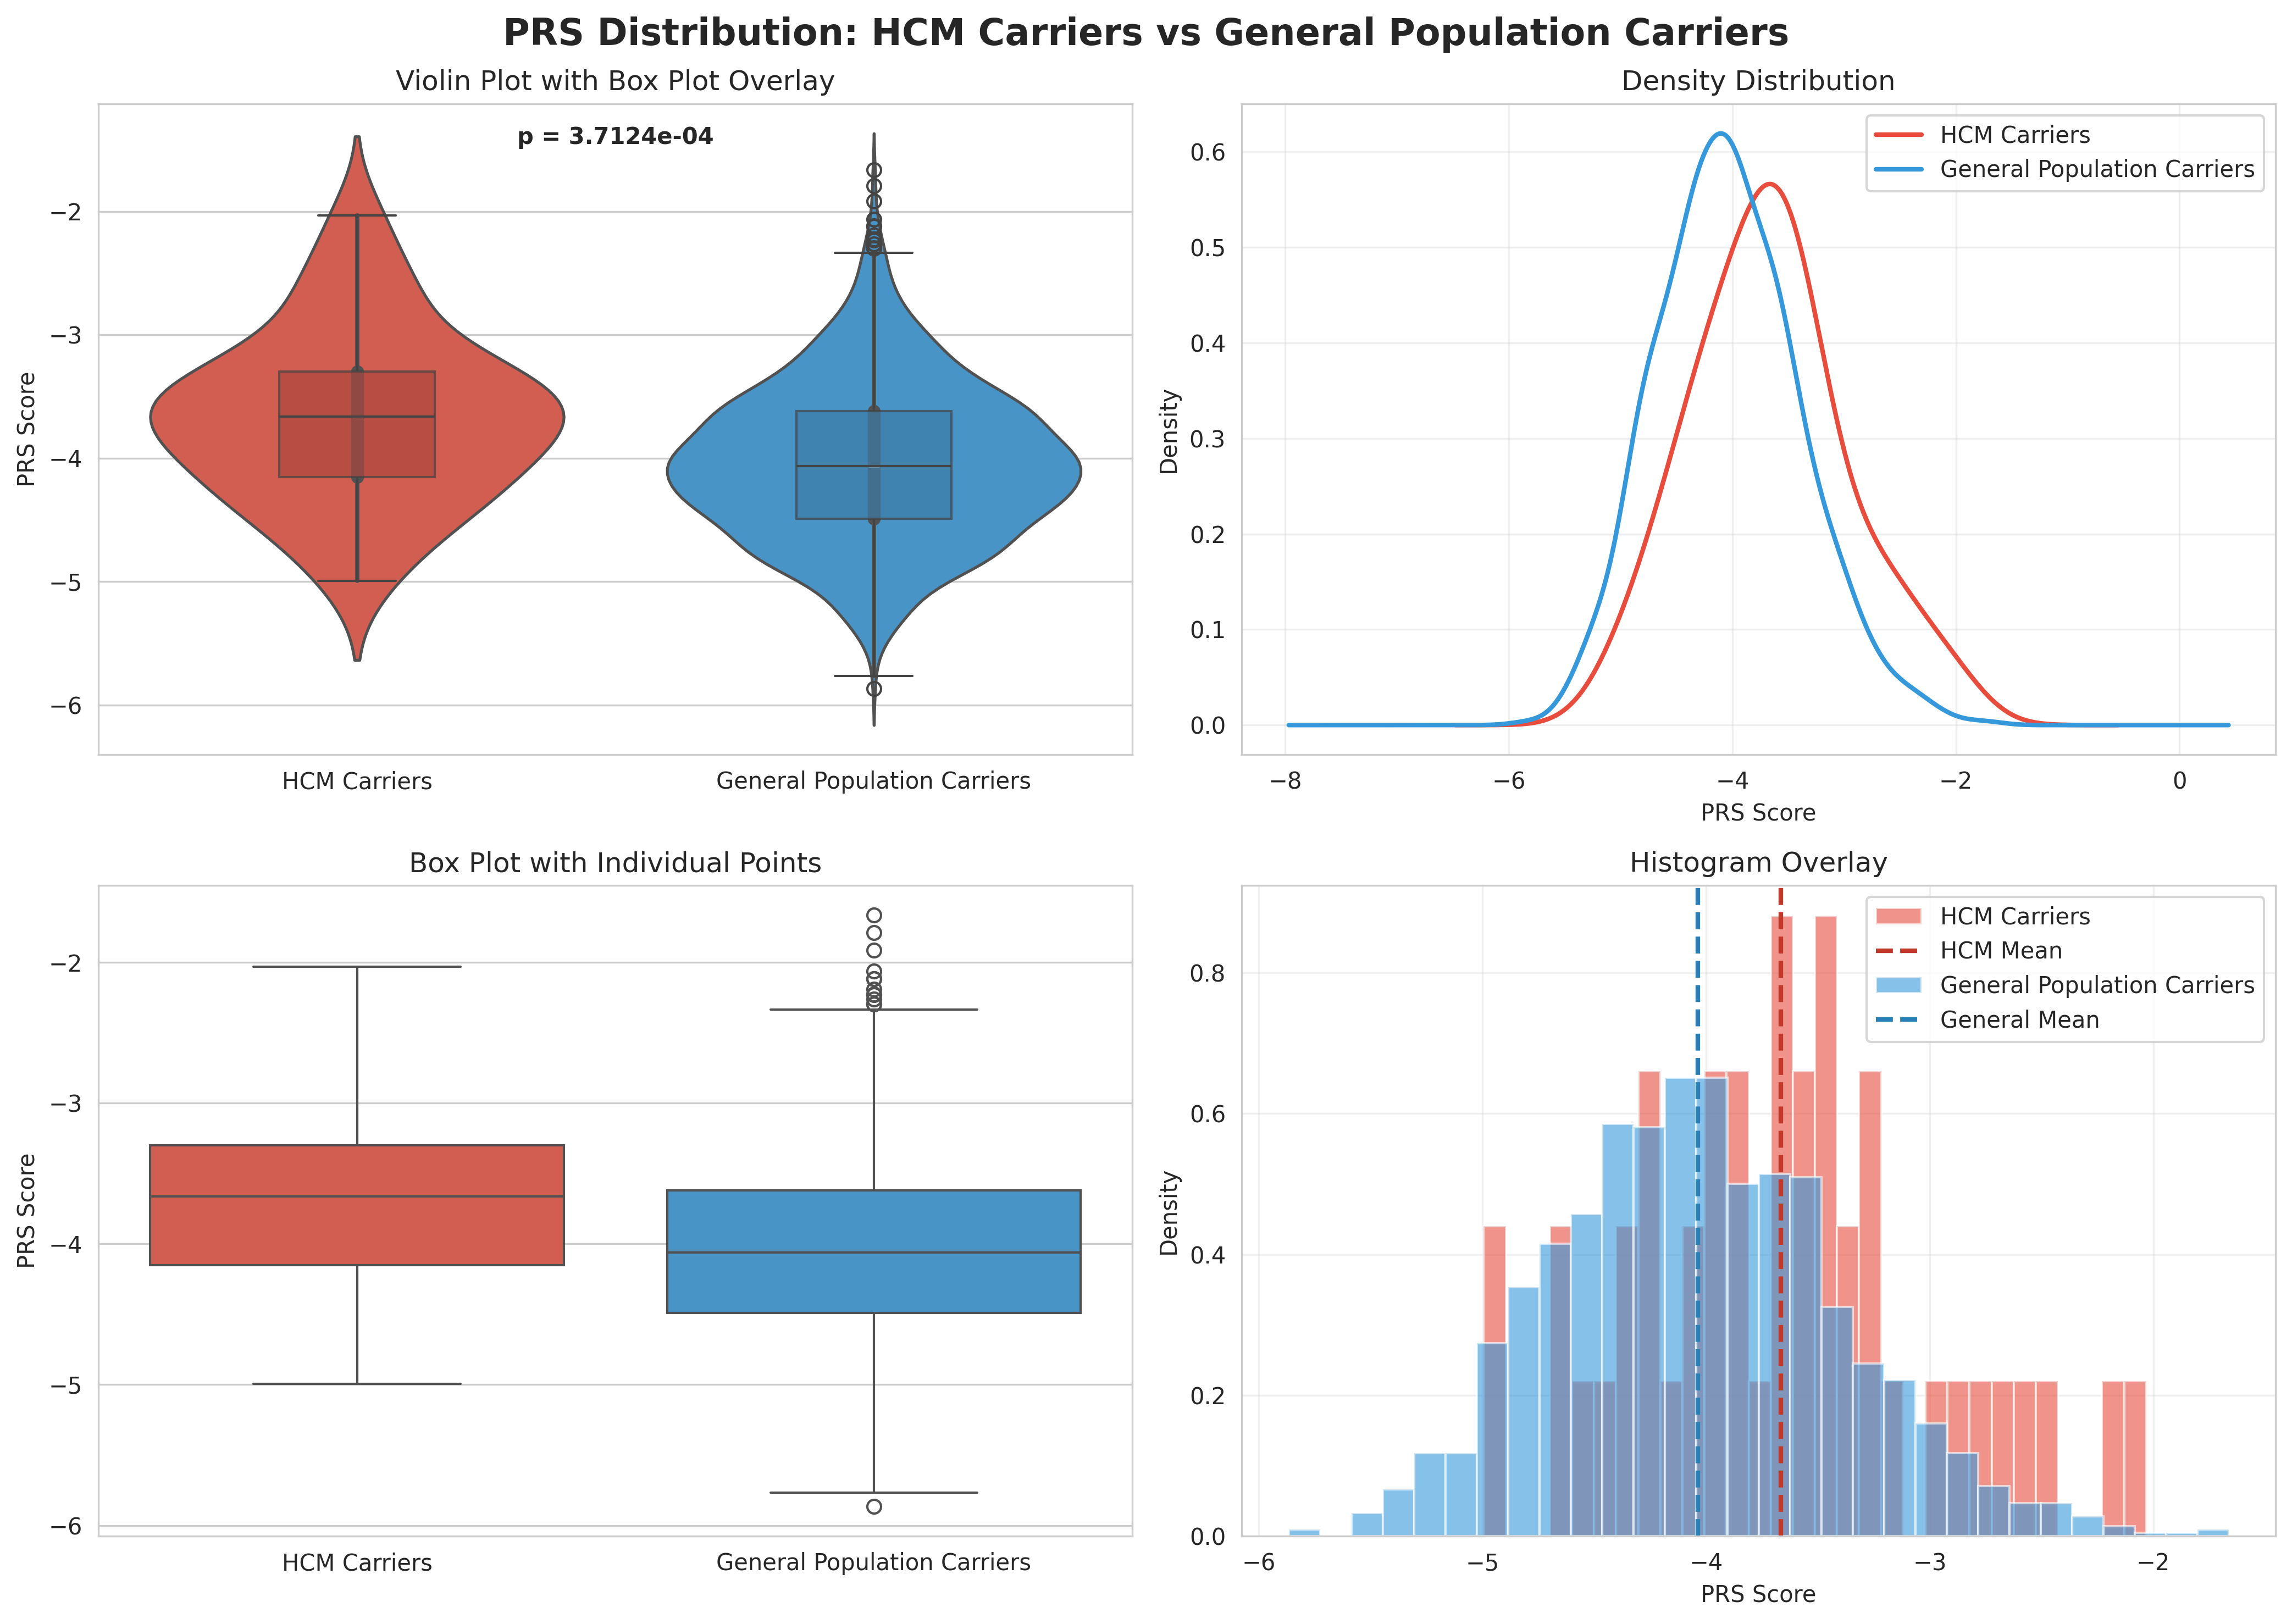

 Saved summary table to: /home/jupyter/Invitae_HCM/prs_comparison_summary.tsv


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

OUTPUT_DIR = "/home/jupyter/Invitae_HCM"
prs_file = "/home/jupyter/prs_output/prs_scores_all_samples.tsv"
prs_df = pd.read_csv(prs_file, sep='\t')

print(f"Original PRS samples: {len(prs_df)}")

prs_df = prs_df[~prs_df['IID'].str.contains('_PrecFDA|_DeCODE', na=False)]

print(f"PRS range: {prs_df['PRS'].min():.4f} to {prs_df['PRS'].max():.4f}")

# Load carrier status
carriers_file = f"{OUTPUT_DIR}/all_carriers_long_format.tsv"
carriers_df = pd.read_csv(carriers_file, sep='\t')

# Get unique carriers (IID) and their HCM status
unique_carriers = carriers_df[['IID', 'is_hcm']].drop_duplicates()
print(f"\nTotal unique carriers: {len(unique_carriers)}")
print(f"  - HCM carriers: {unique_carriers['is_hcm'].sum()}")
print(f"  - General population carriers: {(~unique_carriers['is_hcm']).sum()}")

# Merge PRS with carrier status
carriers_prs = unique_carriers.merge(prs_df, on='IID', how='inner')
print(f"\nCarriers with PRS data: {len(carriers_prs)}")

# Split by cohort
hcm_carriers_prs = carriers_prs[carriers_prs['is_hcm'] == True]['PRS']
general_carriers_prs = carriers_prs[carriers_prs['is_hcm'] == False]['PRS']

print(f"\n HCM carriers with PRS: {len(hcm_carriers_prs)}")
print(f" General population carriers with PRS: {len(general_carriers_prs)}")

# Calculate statistics
print("PRS STATISTICS FOR CARRIERS")

print(f"\nHCM Carriers (n={len(hcm_carriers_prs)}):")
print(f"  Mean ± SD: {hcm_carriers_prs.mean():.4f} ± {hcm_carriers_prs.std():.4f}")
print(f"  Median [IQR]: {hcm_carriers_prs.median():.4f} [{hcm_carriers_prs.quantile(0.25):.4f}-{hcm_carriers_prs.quantile(0.75):.4f}]")

print(f"\nGeneral Population Carriers (n={len(general_carriers_prs)}):")
print(f"  Mean ± SD: {general_carriers_prs.mean():.4f} ± {general_carriers_prs.std():.4f}")
print(f"  Median [IQR]: {general_carriers_prs.median():.4f} [{general_carriers_prs.quantile(0.25):.4f}-{general_carriers_prs.quantile(0.75):.4f}]")

#Mann-Whitney U
statistic, pvalue = stats.mannwhitneyu(hcm_carriers_prs, general_carriers_prs, alternative='two-sided')

# Cohen's d effect size
cohens_d = (hcm_carriers_prs.mean() - general_carriers_prs.mean()) / np.sqrt(
    ((len(hcm_carriers_prs)-1)*hcm_carriers_prs.std()**2 + 
     (len(general_carriers_prs)-1)*general_carriers_prs.std()**2) / 
    (len(hcm_carriers_prs) + len(general_carriers_prs) - 2)
)

print("STATIS")
print(f"Mann-Whitney U test: U={statistic:.2f}, p={pvalue:.4e}")
print(f"Cohen's d (effect size): {cohens_d:.3f}")
if abs(cohens_d) < 0.2:
    effect_interp = "negligible"
elif abs(cohens_d) < 0.5:
    effect_interp = "small"
elif abs(cohens_d) < 0.8:
    effect_interp = "medium"
else:
    effect_interp = "large"
print(f"Effect size interpretation: {effect_interp}")

# visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('PRS Distribution: HCM Carriers vs General Population Carriers', 
             fontsize=16, fontweight='bold')

# Prepare data for plotting
plot_data = pd.DataFrame({
    'PRS': pd.concat([hcm_carriers_prs, general_carriers_prs]),
    'Group': ['HCM Carriers']*len(hcm_carriers_prs) + ['General Population Carriers']*len(general_carriers_prs)
})

# 1. Violin plot with box plot
ax1 = axes[0, 0]
sns.violinplot(data=plot_data, x='Group', y='PRS', hue='Group', ax=ax1, 
               palette=['#e74c3c', '#3498db'], legend=False)
sns.boxplot(data=plot_data, x='Group', y='PRS', hue='Group', ax=ax1, width=0.3, 
            boxprops=dict(alpha=0.7), palette=['#c0392b', '#2980b9'], legend=False)
ax1.set_title('Violin Plot with Box Plot Overlay')
ax1.set_ylabel('PRS Score')
ax1.set_xlabel('')

# p-value annotation
y_max = plot_data['PRS'].max()
y_min = plot_data['PRS'].min()
y_range = y_max - y_min
ax1.text(0.5, y_max + y_range*0.05, f'p = {pvalue:.4e}', 
         ha='center', fontsize=10, fontweight='bold')

# 2. Density plot
ax2 = axes[0, 1]
if len(hcm_carriers_prs) > 1:
    hcm_carriers_prs.plot(kind='density', ax=ax2, color='#e74c3c', label='HCM Carriers', linewidth=2)
if len(general_carriers_prs) > 1:
    general_carriers_prs.plot(kind='density', ax=ax2, color='#3498db', label='General Population Carriers', linewidth=2)
ax2.set_title('Density Distribution')
ax2.set_xlabel('PRS Score')
ax2.set_ylabel('Density')
ax2.legend()
ax2.grid(alpha=0.3)

# 3. Box plot with swarm plot (individual points)
ax3 = axes[1, 0]
sns.boxplot(data=plot_data, x='Group', y='PRS', hue='Group', ax=ax3, 
            palette=['#e74c3c', '#3498db'], legend=False)
# Only add swarm if not too many points
if len(plot_data) < 500:
    sns.swarmplot(data=plot_data, x='Group', y='PRS', ax=ax3, 
                  color='black', alpha=0.3, size=3)
ax3.set_title('Box Plot with Individual Points')
ax3.set_ylabel('PRS Score')
ax3.set_xlabel('')

# 4. Histogram overlay
ax4 = axes[1, 1]
if len(hcm_carriers_prs) > 1:
    ax4.hist(hcm_carriers_prs, bins=30, alpha=0.6, color='#e74c3c', label='HCM Carriers', density=True)
    ax4.axvline(hcm_carriers_prs.mean(), color='#c0392b', linestyle='--', linewidth=2, label='HCM Mean')
if len(general_carriers_prs) > 1:
    ax4.hist(general_carriers_prs, bins=30, alpha=0.6, color='#3498db', label='General Population Carriers', density=True)
    ax4.axvline(general_carriers_prs.mean(), color='#2980b9', linestyle='--', linewidth=2, label='General Mean')
ax4.set_title('Histogram Overlay')
ax4.set_xlabel('PRS Score')
ax4.set_ylabel('Density')
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/prs_comparison_carriers.png", dpi=300, bbox_inches='tight')
print(f"\n Saved plot to: {OUTPUT_DIR}/prs_comparison_carriers.png")
plt.show()

# Save summary table
summary_table = pd.DataFrame({
    'Group': ['HCM Carriers', 'General Population Carriers'],
    'N': [len(hcm_carriers_prs), len(general_carriers_prs)],
    'Mean': [hcm_carriers_prs.mean(), general_carriers_prs.mean()],
    'SD': [hcm_carriers_prs.std(), general_carriers_prs.std()],
    'Median': [hcm_carriers_prs.median(), general_carriers_prs.median()],
    'Q1': [hcm_carriers_prs.quantile(0.25), general_carriers_prs.quantile(0.25)],
    'Q3': [hcm_carriers_prs.quantile(0.75), general_carriers_prs.quantile(0.75)],
    'Min': [hcm_carriers_prs.min(), general_carriers_prs.min()],
    'Max': [hcm_carriers_prs.max(), general_carriers_prs.max()]
})

summary_table.to_csv(f"{OUTPUT_DIR}/prs_comparison_summary.tsv", sep='\t', index=False)
print(f" Saved summary table to: {OUTPUT_DIR}/prs_comparison_summary.tsv")

In [5]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client()
OUTPUT_DIR = "/home/jupyter/Invitae_HCM"
OMOP_DATASET = "nb-tre-dev-2-483522.omop_dataset_v2026_1_1"

carriers_file = f"{OUTPUT_DIR}/all_carriers_long_format.tsv"
carriers_df = pd.read_csv(carriers_file, sep='\t')

# Get unique gen population carriers
general_carriers = carriers_df[carriers_df['is_hcm'] == False]['IID'].unique()
print(f"Number of general population carriers: {len(general_carriers)}")

carrier_ids = "', '".join(general_carriers)

query_check = f"""
SELECT COUNT(DISTINCT person_id) as n_found
FROM `{OMOP_DATASET}.person`
WHERE person_id IN ('{carrier_ids}')
"""

result = client.query(query_check).to_dataframe()
print(f"Carriers found in OMOP person table: {result['n_found'].iloc[0]}")

query_icd = f"""
WITH carrier_list AS (
    SELECT person_id
    FROM `{OMOP_DATASET}.person`
    WHERE person_id IN ('{carrier_ids}')
),

-- Get conditions (ICD-10-CM, ICD-9-CM)
condition_codes AS (
    SELECT 
        co.person_id,
        'condition' as source_table,
        co.condition_concept_id,
        co.condition_source_value as code,
        co.condition_source_concept_id,
        c.concept_name as code_description,
        c.vocabulary_id,
        co.condition_start_date as event_date
    FROM `{OMOP_DATASET}.condition_occurrence` co
    JOIN carrier_list cl ON co.person_id = cl.person_id
    LEFT JOIN `{OMOP_DATASET}.concept` c ON co.condition_source_concept_id = c.concept_id
    WHERE co.condition_source_value IS NOT NULL
),

-- Get measurements
measurement_codes AS (
    SELECT 
        m.person_id,
        'measurement' as source_table,
        m.measurement_concept_id as condition_concept_id,
        m.measurement_source_value as code,
        m.measurement_source_concept_id as condition_source_concept_id,
        c.concept_name as code_description,
        c.vocabulary_id,
        m.measurement_date as event_date
    FROM `{OMOP_DATASET}.measurement` m
    JOIN carrier_list cl ON m.person_id = cl.person_id
    LEFT JOIN `{OMOP_DATASET}.concept` c ON m.measurement_source_concept_id = c.concept_id
    WHERE m.measurement_source_value IS NOT NULL
),

-- Get observations
observation_codes AS (
    SELECT 
        o.person_id,
        'observation' as source_table,
        o.observation_concept_id as condition_concept_id,
        o.observation_source_value as code,
        o.observation_source_concept_id as condition_source_concept_id,
        c.concept_name as code_description,
        c.vocabulary_id,
        o.observation_date as event_date
    FROM `{OMOP_DATASET}.observation` o
    JOIN carrier_list cl ON o.person_id = cl.person_id
    LEFT JOIN `{OMOP_DATASET}.concept` c ON o.observation_source_concept_id = c.concept_id
    WHERE o.observation_source_value IS NOT NULL
),

-- Get procedures
procedure_codes AS (
    SELECT 
        p.person_id,
        'procedure' as source_table,
        p.procedure_concept_id as condition_concept_id,
        p.procedure_source_value as code,
        p.procedure_source_concept_id as condition_source_concept_id,
        c.concept_name as code_description,
        c.vocabulary_id,
        p.procedure_date as event_date
    FROM `{OMOP_DATASET}.procedure_occurrence` p
    JOIN carrier_list cl ON p.person_id = cl.person_id
    LEFT JOIN `{OMOP_DATASET}.concept` c ON p.procedure_source_concept_id = c.concept_id
    WHERE p.procedure_source_value IS NOT NULL
),

-- Combine all codes
all_codes AS (
    SELECT * FROM condition_codes
    UNION ALL
    SELECT * FROM measurement_codes
    UNION ALL
    SELECT * FROM observation_codes
    UNION ALL
    SELECT * FROM procedure_codes
)

SELECT 
    person_id,
    source_table,
    code,
    code_description,
    vocabulary_id,
    event_date,
    COUNT(*) OVER (PARTITION BY person_id, code) as occurrence_count
FROM all_codes
WHERE vocabulary_id LIKE 'ICD%' OR code LIKE 'I%' OR code LIKE 'E%' OR code LIKE 'D%'
ORDER BY person_id, event_date DESC
"""


icd_results = client.query(query_icd).to_dataframe()

print(f"\n Found {len(icd_results)} ICD code records")
print(f" Unique codes: {icd_results['code'].nunique()}")
print(f" Carriers with at least one ICD code: {icd_results['person_id'].nunique()}")

# Save full results
icd_results.to_csv(f"{OUTPUT_DIR}/general_carriers_icd_codes_full.tsv", sep='\t', index=False)
print(f" Saved full results to: {OUTPUT_DIR}/general_carriers_icd_codes_full.tsv")

# Display sample
print("SAMPLE OF ICD CODES (first 20 records)")
print(icd_results.head(20).to_string())

Number of general population carriers: 1512
Carriers found in OMOP person table: 1510

 Found 1001613 ICD code records
 Unique codes: 16669
 Carriers with at least one ICD code: 1507
 Saved full results to: /home/jupyter/Invitae_HCM/general_carriers_icd_codes_full.tsv
SAMPLE OF ICD CODES (first 20 records)
     person_id source_table      code                                                code_description vocabulary_id  event_date  occurrence_count
0   R200125275    condition     D12.3                             Benign neoplasm of transverse colon       ICD10CM  2022-12-05                 4
1   R200125275    condition     D12.3                             Benign neoplasm of transverse colon       ICD10CM  2022-12-05                 4
2   R200125275    condition     D12.3                             Benign neoplasm of transverse colon       ICD10CM  2022-12-05                 4
3   R200125275    condition     D12.3                             Benign neoplasm of transverse colon       

In [8]:
#Summary statistics and cardiovascular focus
query_summary = f"""
WITH carrier_list AS (
    SELECT person_id
    FROM `{OMOP_DATASET}.person`
    WHERE person_id IN ('{carrier_ids}')
),

all_conditions AS (
    SELECT 
        co.person_id,
        co.condition_source_value as code,
        c.concept_name as description,
        c.vocabulary_id,
        COUNT(*) as occurrence_count,
        MIN(co.condition_start_date) as first_occurrence,
        MAX(co.condition_start_date) as last_occurrence
    FROM `{OMOP_DATASET}.condition_occurrence` co
    JOIN carrier_list cl ON co.person_id = cl.person_id
    LEFT JOIN `{OMOP_DATASET}.concept` c ON co.condition_source_concept_id = c.concept_id
    WHERE c.vocabulary_id IN ('ICD10CM', 'ICD9CM')
    GROUP BY co.person_id, co.condition_source_value, c.concept_name, c.vocabulary_id
)

SELECT 
    code,
    description,
    vocabulary_id,
    COUNT(DISTINCT person_id) as n_carriers,
    ROUND(COUNT(DISTINCT person_id) * 100.0 / {len(general_carriers)}, 2) as percent_carriers,
    SUM(occurrence_count) as total_occurrences,
    MIN(first_occurrence) as earliest_date,
    MAX(last_occurrence) as latest_date,
    -- Flag cardiovascular codes
    CASE 
        WHEN code LIKE 'I%' THEN 'Cardiovascular'
        WHEN code LIKE 'E%' THEN 'Endocrine/Metabolic'
        WHEN code LIKE 'D%' THEN 'Blood/Immune'
        WHEN code LIKE 'N%' THEN 'Genitourinary'
        WHEN code LIKE 'J%' THEN 'Respiratory'
        WHEN code LIKE 'K%' THEN 'Digestive'
        WHEN code LIKE 'M%' THEN 'Musculoskeletal'
        WHEN code LIKE 'R%' THEN 'Symptoms/Signs'
        WHEN code LIKE 'Z%' THEN 'Health Status'
        ELSE 'Other'
    END as code_category
FROM all_conditions
GROUP BY code, description, vocabulary_id
HAVING COUNT(DISTINCT person_id) >= 2  -- Only codes in 2+ carriers
ORDER BY n_carriers DESC, code
"""

summary_results = client.query(query_summary).to_dataframe()
summary_results.to_csv(f"{OUTPUT_DIR}/general_carriers_icd_summary.tsv", sep='\t', index=False)

print(f"TOP ICD CODES IN GENERAL POPULATION CARRIERS (n={len(general_carriers)})")
print(summary_results.head(50).to_string())

# Cardiovascular-specific summary
cv_codes = summary_results[summary_results['code_category'] == 'Cardiovascular']
print("CARDIOVASCULAR CODES (ICD I-codes)")
print(cv_codes.to_string())

# Category breakdown
category_summary = summary_results.groupby('code_category').agg({
    'code': 'count',
    'n_carriers': 'sum'
}).reset_index()
category_summary.columns = ['Category', 'Unique_Codes', 'Total_Carrier_Occurrences']
category_summary = category_summary.sort_values('Total_Carrier_Occurrences', ascending=False)

print("ICD CODE CATEGORY BREAKDOWN")
print(category_summary.to_string())

TOP ICD CODES IN GENERAL POPULATION CARRIERS (n=1512)
       code                                                                      description vocabulary_id  n_carriers  percent_carriers  total_occurrences earliest_date latest_date        code_category
0       I10                                                 Essential (primary) hypertension       ICD10CM         490             32.41              15515    2014-07-22  2026-02-11       Cardiovascular
1     401.9                                               Unspecified essential hypertension        ICD9CM         430             28.44               4797    1991-11-07  2017-10-20                Other
2     K21.9                             Gastro-esophageal reflux disease without esophagitis       ICD10CM         348             23.02               3138    2014-12-08  2026-02-03            Digestive
3    786.50                                                          Chest pain, unspecified        ICD9CM         315             20.

In [2]:
OUTPUT_DIR = "/home/jupyter/Invitae_HCM"

General population carriers: 1512

Querying cardiovascular conditions for general population carriers...
 Found 126750 CV condition records for carriers
 959 carriers (63.4%) have at least one CV condition

Getting age distribution of carriers...
 Carrier age - Mean: 57.3, Median: 59.0

Querying cardiovascular conditions for age-matched non-carriers...
 Found 13559 CV condition records for non-carriers
 412 non-carriers (27.2%) have at least one CV condition
CARDIOVASCULAR CONDITION ENRICHMENT ANALYSIS

Carriers with CV conditions: 959/1512 (63.4%)
Non-carriers with CV conditions: 412/1512 (27.2%)
Fold enrichment: 2.33x
Fisher's exact test: OR=4.63, p=1.3853e-90
CONDITION-SPECIFIC ENRICHMENT

Top 20 most enriched conditions:
icd_prefix                                             condition_name  carrier_count  noncarrier_count  fold_enrichment       pvalue
       430                                    Subarachnoid hemorrhage           27.0               1.0        27.000000 1.938029e-07

/opt/conda/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


 Saved plot to: /home/jupyter/Invitae_HCM/cv_enrichment_analysis.png


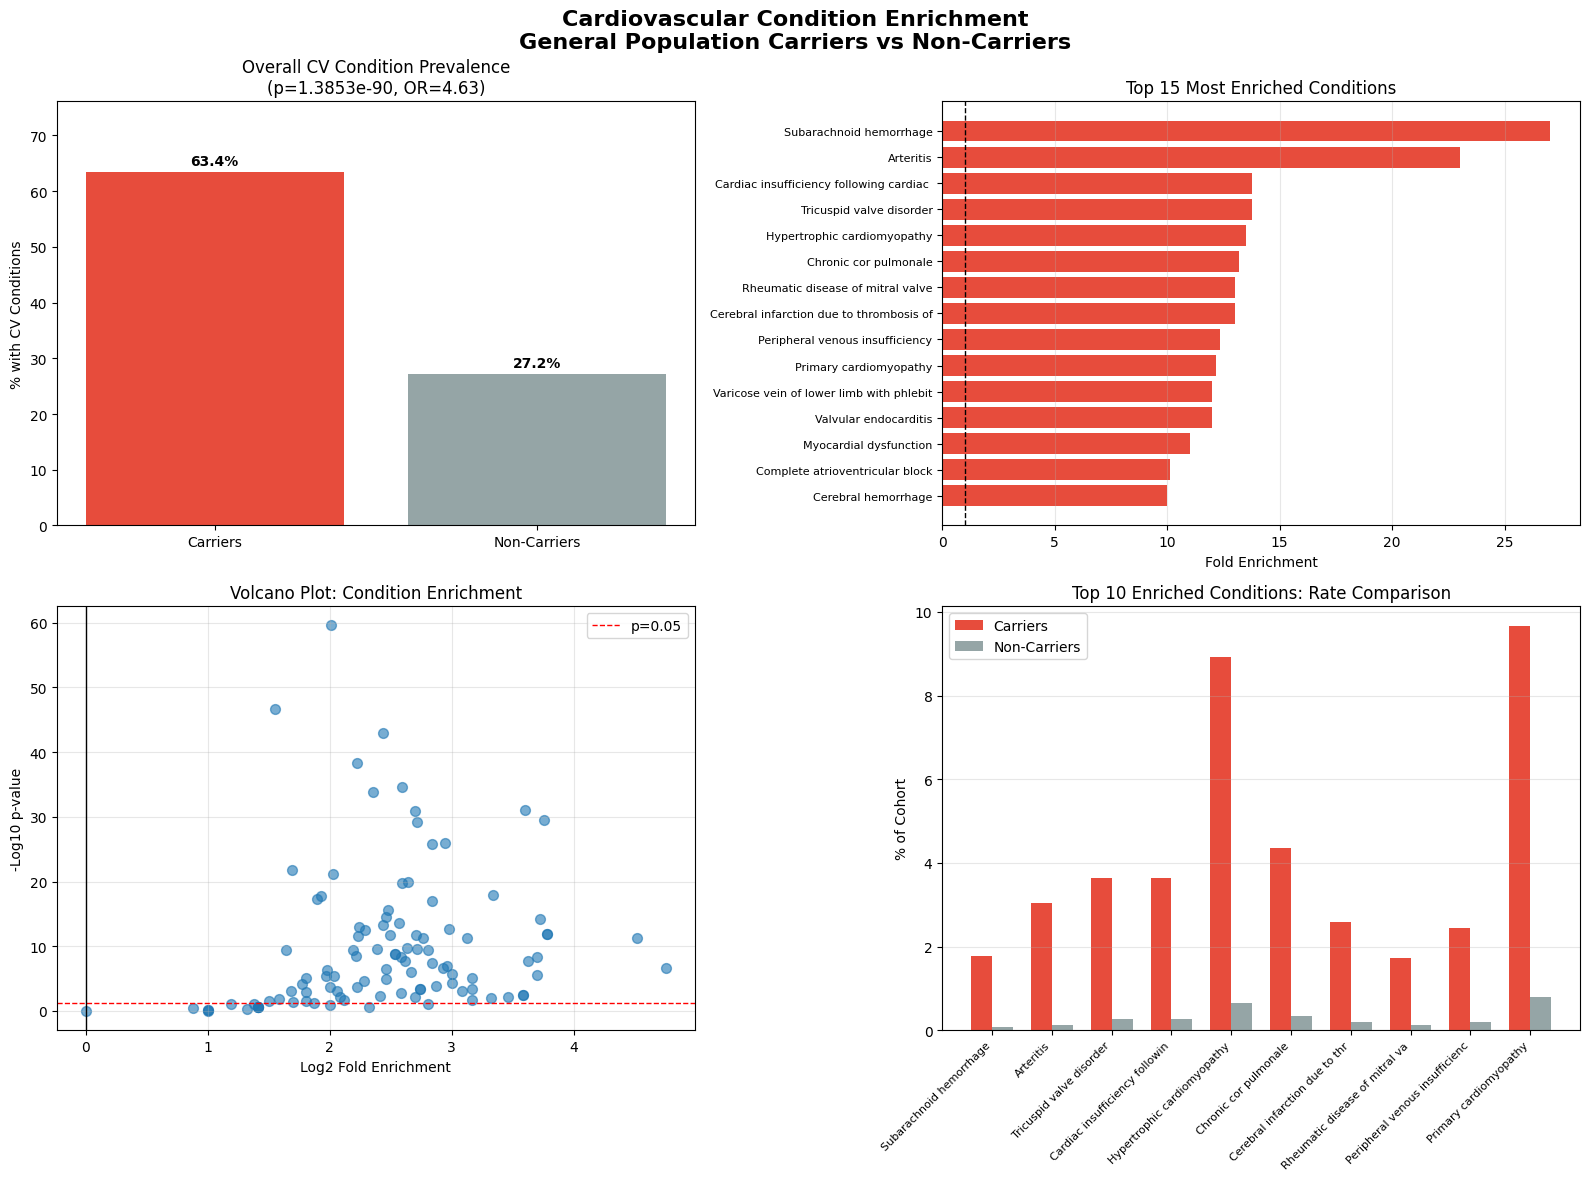

In [8]:
from google.cloud import bigquery
import pandas as pd
from scipy import stats
import numpy as np

client = bigquery.Client()
OMOP_DATASET = "nb-tre-dev-2-483522.omop_dataset_v2026_1_1"

# Load carriers
carriers_file = f"{OUTPUT_DIR}/all_carriers_long_format.tsv"
carriers_df = pd.read_csv(carriers_file, sep='\t')

# Get general population carriers
general_carriers = carriers_df[carriers_df['is_hcm'] == False]['IID'].unique()
print(f"General population carriers: {len(general_carriers)}")

# Convert to strings for SQL
general_carrier_ids = "', '".join(general_carriers)

# Query 1: Get cardiovascular conditions for general population carriers with names
query_carriers_cv = f"""
WITH carriers AS (
    SELECT person_id
    FROM `{OMOP_DATASET}.person`
    WHERE person_id IN ('{general_carrier_ids}')
),

cv_conditions AS (
    SELECT 
        co.person_id,
        co.condition_source_value,
        co.condition_start_date,
        c.concept_name AS condition_name,
        p.birth_datetime,
        DATE_DIFF(co.condition_start_date, p.birth_datetime, YEAR) AS age_at_dx
    FROM `{OMOP_DATASET}.condition_occurrence` co
    INNER JOIN `{OMOP_DATASET}.person` p ON co.person_id = p.person_id
    LEFT JOIN `{OMOP_DATASET}.concept` c ON co.condition_concept_id = c.concept_id
    WHERE (
        co.condition_source_value LIKE 'I%'  -- ICD-10 cardiovascular
        OR (co.condition_source_value >= '390' AND co.condition_source_value < '460')  -- ICD-9 cardiovascular
    )
    AND co.person_id IN (SELECT person_id FROM carriers)
)

SELECT 
    person_id,
    condition_source_value,
    condition_name,
    condition_start_date,
    age_at_dx
FROM cv_conditions
ORDER BY person_id, condition_start_date
"""

print("\nQuerying cardiovascular conditions for general population carriers...")
carriers_cv = client.query(query_carriers_cv).to_dataframe()
print(f" Found {len(carriers_cv)} CV condition records for carriers")

# Count unique people with CV conditions
carriers_with_cv = carriers_cv['person_id'].nunique()
print(f" {carriers_with_cv} carriers ({carriers_with_cv/len(general_carriers)*100:.1f}%) have at least one CV condition")

# Query 2: Sample non-carriers matched by age distribution
# First get age distribution of carriers
query_carriers_age = f"""
SELECT 
    person_id,
    DATE_DIFF(CURRENT_DATE(), birth_datetime, YEAR) AS current_age
FROM `{OMOP_DATASET}.person`
WHERE person_id IN ('{general_carrier_ids}')
"""

print("\nGetting age distribution of carriers...")
carriers_age = client.query(query_carriers_age).to_dataframe()
print(f" Carrier age - Mean: {carriers_age['current_age'].mean():.1f}, Median: {carriers_age['current_age'].median():.1f}")

# Get non-carriers matched by age (sample size equal to carriers)
mean_age = carriers_age['current_age'].mean()
std_age = carriers_age['current_age'].std()
min_age = max(0, mean_age - 2*std_age)
max_age = mean_age + 2*std_age

query_noncarriers_cv = f"""
WITH all_carriers AS (
    SELECT person_id
    FROM `{OMOP_DATASET}.person`
    WHERE person_id IN ('{general_carrier_ids}')
),

age_matched_noncarriers AS (
    SELECT 
        person_id,
        DATE_DIFF(CURRENT_DATE(), birth_datetime, YEAR) AS current_age
    FROM `{OMOP_DATASET}.person`
    WHERE person_id NOT IN (SELECT person_id FROM all_carriers)
        AND DATE_DIFF(CURRENT_DATE(), birth_datetime, YEAR) BETWEEN {min_age} AND {max_age}
    ORDER BY RAND()
    LIMIT {len(general_carriers)}
),

cv_conditions AS (
    SELECT 
        co.person_id,
        co.condition_source_value,
        co.condition_start_date,
        c.concept_name AS condition_name,
        p.birth_datetime,
        DATE_DIFF(co.condition_start_date, p.birth_datetime, YEAR) AS age_at_dx
    FROM `{OMOP_DATASET}.condition_occurrence` co
    INNER JOIN `{OMOP_DATASET}.person` p ON co.person_id = p.person_id
    LEFT JOIN `{OMOP_DATASET}.concept` c ON co.condition_concept_id = c.concept_id
    WHERE (
        co.condition_source_value LIKE 'I%'  -- ICD-10 cardiovascular
        OR (co.condition_source_value >= '390' AND co.condition_source_value < '460')  -- ICD-9 cardiovascular
    )
    AND co.person_id IN (SELECT person_id FROM age_matched_noncarriers)
)

SELECT 
    person_id,
    condition_source_value,
    condition_name,
    condition_start_date,
    age_at_dx
FROM cv_conditions
ORDER BY person_id, condition_start_date
"""

print("\nQuerying cardiovascular conditions for age-matched non-carriers...")
noncarriers_cv = client.query(query_noncarriers_cv).to_dataframe()
print(f" Found {len(noncarriers_cv)} CV condition records for non-carriers")

noncarriers_with_cv = noncarriers_cv['person_id'].nunique()
print(f" {noncarriers_with_cv} non-carriers ({noncarriers_with_cv/len(general_carriers)*100:.1f}%) have at least one CV condition")

# Calculate enrichment stats
print("CARDIOVASCULAR CONDITION ENRICHMENT ANALYSIS")

carriers_rate = carriers_with_cv / len(general_carriers)
noncarriers_rate = noncarriers_with_cv / len(general_carriers)
fold_enrichment = carriers_rate / noncarriers_rate if noncarriers_rate > 0 else float('inf')

print(f"\nCarriers with CV conditions: {carriers_with_cv}/{len(general_carriers)} ({carriers_rate*100:.1f}%)")
print(f"Non-carriers with CV conditions: {noncarriers_with_cv}/{len(general_carriers)} ({noncarriers_rate*100:.1f}%)")
print(f"Fold enrichment: {fold_enrichment:.2f}x")

# Fisher's exact test
contingency_table = [
    [carriers_with_cv, len(general_carriers) - carriers_with_cv],
    [noncarriers_with_cv, len(general_carriers) - noncarriers_with_cv]
]
odds_ratio, pvalue = stats.fisher_exact(contingency_table)
print(f"Fisher's exact test: OR={odds_ratio:.2f}, p={pvalue:.4e}")

# Condition-specific enrichment with names
print("CONDITION-SPECIFIC ENRICHMENT")

# Get most common condition name for each ICD prefix
def get_most_common_name(df, icd_prefix):
    subset = df[df['condition_source_value'].str.startswith(icd_prefix)]
    if len(subset) == 0 or subset['condition_name'].isna().all():
        return icd_prefix
    return subset['condition_name'].mode()[0] if len(subset['condition_name'].mode()) > 0 else icd_prefix

carriers_cv['icd_prefix'] = carriers_cv['condition_source_value'].str[:3]
noncarriers_cv['icd_prefix'] = noncarriers_cv['condition_source_value'].str[:3]

carrier_condition_counts = carriers_cv.groupby('icd_prefix')['person_id'].nunique().reset_index()
carrier_condition_counts.columns = ['icd_prefix', 'carrier_count']

noncarrier_condition_counts = noncarriers_cv.groupby('icd_prefix')['person_id'].nunique().reset_index()
noncarrier_condition_counts.columns = ['icd_prefix', 'noncarrier_count']

condition_comparison = carrier_condition_counts.merge(
    noncarrier_condition_counts, 
    on='icd_prefix', 
    how='outer'
).fillna(0)

# Add condition names
all_cv = pd.concat([carriers_cv, noncarriers_cv])
condition_comparison['condition_name'] = condition_comparison['icd_prefix'].apply(
    lambda x: get_most_common_name(all_cv, x)
)

condition_comparison['carrier_rate'] = condition_comparison['carrier_count'] / len(general_carriers)
condition_comparison['noncarrier_rate'] = condition_comparison['noncarrier_count'] / len(general_carriers)
condition_comparison['fold_enrichment'] = condition_comparison['carrier_rate'] / condition_comparison['noncarrier_rate'].replace(0, np.nan)

# Calculate p-values
def calculate_fisher_pvalue(row):
    table = [
        [row['carrier_count'], len(general_carriers) - row['carrier_count']],
        [row['noncarrier_count'], len(general_carriers) - row['noncarrier_count']]
    ]
    _, p = stats.fisher_exact(table)
    return p

condition_comparison['pvalue'] = condition_comparison.apply(calculate_fisher_pvalue, axis=1)
condition_comparison = condition_comparison.sort_values('fold_enrichment', ascending=False)

condition_comparison['display_name'] = condition_comparison['condition_name'].str[:50]

print("\nTop 20 most enriched conditions:")
print(condition_comparison[['icd_prefix', 'condition_name', 'carrier_count', 'noncarrier_count', 
                            'fold_enrichment', 'pvalue']].head(20).to_string(index=False))

# Save results
condition_comparison.to_csv(f"{OUTPUT_DIR}/cv_enrichment_analysis.tsv", sep='\t', index=False)
print(f"\n\ Saved enrichment analysis to: {OUTPUT_DIR}/cv_enrichment_analysis.tsv")

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Cardiovascular Condition Enrichment\nGeneral Population Carriers vs Non-Carriers', 
             fontsize=16, fontweight='bold')

# 1. Overall comparison
ax1 = axes[0, 0]
categories = ['Carriers', 'Non-Carriers']
rates = [carriers_rate * 100, noncarriers_rate * 100]
bars = ax1.bar(categories, rates, color=['#e74c3c', '#95a5a6'])
ax1.set_ylabel('% with CV Conditions')
ax1.set_title(f'Overall CV Condition Prevalence\n(p={pvalue:.4e}, OR={odds_ratio:.2f})')
ax1.set_ylim(0, max(rates) * 1.2)
for i, (bar, rate) in enumerate(zip(bars, rates)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(rates)*0.02, 
             f'{rate:.1f}%', ha='center', fontweight='bold')

# 2. Top enriched conditions
ax2 = axes[0, 1]
top_conditions = condition_comparison.head(15).copy()
top_conditions = top_conditions.sort_values('fold_enrichment')
# Truncate names for plot
top_conditions['plot_name'] = top_conditions['display_name'].str[:40]
ax2.barh(top_conditions['plot_name'], top_conditions['fold_enrichment'], color='#e74c3c')
ax2.set_xlabel('Fold Enrichment')
ax2.set_title('Top 15 Most Enriched Conditions')
ax2.axvline(1, color='black', linestyle='--', linewidth=1)
ax2.grid(axis='x', alpha=0.3)
ax2.tick_params(axis='y', labelsize=8)

# 3. Volcano plot
ax3 = axes[1, 0]
condition_comparison['neg_log10_p'] = -np.log10(condition_comparison['pvalue'].replace(0, 1e-300))
ax3.scatter(np.log2(condition_comparison['fold_enrichment']), 
            condition_comparison['neg_log10_p'],
            alpha=0.6, s=50)
ax3.axhline(-np.log10(0.05), color='red', linestyle='--', linewidth=1, label='p=0.05')
ax3.axvline(0, color='black', linestyle='-', linewidth=1)
ax3.set_xlabel('Log2 Fold Enrichment')
ax3.set_ylabel('-Log10 p-value')
ax3.set_title('Volcano Plot: Condition Enrichment')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Top conditions comparison
ax4 = axes[1, 1]
top_10 = condition_comparison.head(10).copy()
top_10['plot_name'] = top_10['display_name'].str[:30]
x = np.arange(len(top_10))
width = 0.35
ax4.bar(x - width/2, top_10['carrier_rate']*100, width, label='Carriers', color='#e74c3c')
ax4.bar(x + width/2, top_10['noncarrier_rate']*100, width, label='Non-Carriers', color='#95a5a6')
ax4.set_ylabel('% of Cohort')
ax4.set_title('Top 10 Enriched Conditions: Rate Comparison')
ax4.set_xticks(x)
ax4.set_xticklabels(top_10['plot_name'], rotation=45, ha='right', fontsize=8)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/cv_enrichment_analysis.png", dpi=300, bbox_inches='tight')
print(f" Saved plot to: {OUTPUT_DIR}/cv_enrichment_analysis.png")
plt.show()

In [9]:
# Check overlap between general population carriers with HCM and the HCM cohort
# Get carriers with HCM diagnosis (I42 codes)
carriers_with_hcm = carriers_cv[carriers_cv['condition_source_value'].str.startswith('I42')]['person_id'].unique()
print(f"General population carriers with HCM diagnosis (I42.x codes): {len(carriers_with_hcm)}")

hcm_cohort_ids = carriers_df[carriers_df['is_hcm'] == True]['IID'].unique()
print(f"Total in HCM cohort: {len(hcm_cohort_ids)}")

# Find overlap
overlap = set(carriers_with_hcm) & set(hcm_cohort_ids)
not_in_cohort = set(carriers_with_hcm) - set(hcm_cohort_ids)

print("OVERLAP ANALYSIS")
print(f"Carriers with HCM diagnosis IN the HCM cohort: {len(overlap)}")
print(f"Carriers with HCM diagnosis NOT in the HCM cohort: {len(not_in_cohort)}")

if len(not_in_cohort) > 0:
    print(f"\n  WARNING: {len(not_in_cohort)} people have HCM diagnosis but are not in the HCM cohort!")
    
    # Get details for these people
    query_missed_hcm = f"""
    SELECT 
        co.person_id,
        co.condition_source_value,
        c.concept_name,
        co.condition_start_date,
        p.birth_datetime,
        DATE_DIFF(co.condition_start_date, p.birth_datetime, YEAR) AS age_at_dx
    FROM `{OMOP_DATASET}.condition_occurrence` co
    INNER JOIN `{OMOP_DATASET}.person` p ON co.person_id = p.person_id
    LEFT JOIN `{OMOP_DATASET}.concept` c ON co.condition_concept_id = c.concept_id
    WHERE co.person_id IN ('{("', '").join(not_in_cohort)}')
        AND co.condition_source_value LIKE 'I42%'
    ORDER BY co.person_id, co.condition_start_date
    """
    
    missed_hcm_details = client.query(query_missed_hcm).to_dataframe()
    
    print("\nDetails of HCM diagnoses NOT in cohort:")
    print(missed_hcm_details.to_string(index=False))
    
    # Save these for review
    missed_hcm_details.to_csv(f"{OUTPUT_DIR}/carriers_with_hcm_not_in_cohort.tsv", sep='\t', index=False)
    print(f"\nSaved details to: {OUTPUT_DIR}/carriers_with_hcm_not_in_cohort.tsv")
    
    # Check how the HCM cohort was defined
    print("HCM COHORT DEFINITION CHECK")
    
    hcm_cohort_id_str = "', '".join(hcm_cohort_ids)
    
    query_hcm_cohort_conditions = f"""
    SELECT 
        co.condition_source_value,
        c.concept_name,
        COUNT(DISTINCT co.person_id) as num_people,
        MIN(co.condition_start_date) as earliest_date,
        MAX(co.condition_start_date) as latest_date
    FROM `{OMOP_DATASET}.condition_occurrence` co
    LEFT JOIN `{OMOP_DATASET}.concept` c ON co.condition_concept_id = c.concept_id
    WHERE co.person_id IN ('{hcm_cohort_id_str}')
        AND (co.condition_source_value LIKE 'I42%' 
             OR co.condition_source_value LIKE '425%')  -- ICD-9 cardiomyopathy
    GROUP BY co.condition_source_value, c.concept_name
    ORDER BY num_people DESC
    """
    
    hcm_cohort_conditions = client.query(query_hcm_cohort_conditions).to_dataframe()
    
    print("\nConditions in the HCM cohort:")
    print(hcm_cohort_conditions.to_string(index=False))

else:
    print("\n All carriers with HCM diagnosis are properly included in the HCM cohort")

# Double-check: are there people in HCM cohort WITHOUT HCM diagnosis?
query_cohort_without_dx = f"""
SELECT 
    p.person_id,
    COUNT(DISTINCT co.condition_occurrence_id) as num_cv_conditions
FROM `{OMOP_DATASET}.person` p
LEFT JOIN `{OMOP_DATASET}.condition_occurrence` co 
    ON p.person_id = co.person_id
    AND (co.condition_source_value LIKE 'I42%' OR co.condition_source_value LIKE '425%')
WHERE p.person_id IN ('{hcm_cohort_id_str}')
GROUP BY p.person_id
HAVING num_cv_conditions = 0
"""

cohort_without_dx = client.query(query_cohort_without_dx).to_dataframe()

if len(cohort_without_dx) > 0:
    print("\n  Some people in HCM cohort don't have HCM diagnosis codes!")


General population carriers with HCM diagnosis (I42.x codes): 135
Total in HCM cohort: 46
OVERLAP ANALYSIS
Carriers with HCM diagnosis IN the HCM cohort: 0
Carriers with HCM diagnosis NOT in the HCM cohort: 135


Details of HCM diagnoses NOT in cohort:
 person_id condition_source_value                            concept_name condition_start_date birth_datetime  age_at_dx
R200730951                  I42.1 Hypertrophic obstructive cardiomyopathy           2014-11-11     1954-12-07         60
R200730951                  I42.1 Hypertrophic obstructive cardiomyopathy           2014-11-11     1954-12-07         60
R202913655                  I42.2             Hypertrophic cardiomyopathy           2015-01-26     2011-03-15          4
R202913655                  I42.2             Hypertrophic cardiomyopathy           2015-01-26     2011-03-15          4
R202913655                  I42.9                          Cardiomyopathy           2016-05-02     2011-03-15          5
R205425166           

In [12]:
print("COMPARING AGE OF HCM ONSET: THREE GROUPS")
print("STEP 1: Load HCM cohort")

hcm_cohort = pd.read_csv('/home/jupyter/prs_output/hcm_cohort.keep', sep='\s+', header=None, names=['FID', 'IID'])
print(f"\n Loaded HCM cohort from: /home/jupyter/prs_output/hcm_cohort.keep")
print(f"  Total HCM cohort members: {len(hcm_cohort)}")
print(f"  Columns: {hcm_cohort.columns.tolist()}")
print(f"\nFirst few HCM cohort IDs:")
print(hcm_cohort.head(10))

# Get unique IDs
hcm_cohort_ids = hcm_cohort['IID'].unique()
print(f"\n Unique HCM cohort IDs: {len(hcm_cohort_ids)}")

print("STEP 2: Load carrier data")

# Load carrier files
hcm_carriers = pd.read_csv(f"{OUTPUT_DIR}/hcm_carriers_long_format.tsv", sep='\t')
all_carriers = pd.read_csv(f"{OUTPUT_DIR}/all_carriers_long_format.tsv", sep='\t')

print(f"\n Loaded HCM cohort carriers: {len(hcm_carriers['IID'].unique())} individuals")
print(f" Loaded all carriers: {len(all_carriers['IID'].unique())} individuals")

print("STEP 3: Filter general population carriers to those with ≥2 HCM ICD codes")

# Get all general population carrier IDs
all_gen_pop_carrier_ids = all_carriers['IID'].unique()
print(f"\nTotal general population carriers: {len(all_gen_pop_carrier_ids)}")

# Convert to string for BigQuery
all_gen_pop_carrier_str = "', '".join(str(x) for x in all_gen_pop_carrier_ids)

# Query to count HCM diagnoses for each general population carrier
query_hcm_count = f"""
SELECT 
    co.person_id,
    COUNT(DISTINCT co.condition_start_date) as num_hcm_diagnoses,
    COUNT(DISTINCT co.condition_source_value) as num_unique_codes,
    STRING_AGG(DISTINCT co.condition_source_value ORDER BY co.condition_source_value) as all_codes
FROM `{OMOP_DATASET}.condition_occurrence` co
WHERE co.person_id IN ('{all_gen_pop_carrier_str}')
    AND (co.condition_source_value LIKE 'I42.1%'  -- Obstructive HCM
         OR co.condition_source_value LIKE 'I42.2%'  -- Other HCM
         OR co.condition_source_value = 'I42.9'      -- Cardiomyopathy unspecified
         OR co.condition_source_value LIKE '425.1%'  -- ICD-9 HCM
         OR co.condition_source_value LIKE '425.4%') -- ICD-9 other primary cardiomyopathy
GROUP BY co.person_id
"""

print("\nQuerying HCM diagnosis counts for general population carriers...")
gen_pop_hcm_counts = client.query(query_hcm_count).to_dataframe()

print(f"\nGeneral population carriers with ANY HCM diagnosis: {len(gen_pop_hcm_counts)}")
print(f"\nDistribution of HCM diagnosis counts:")
print(gen_pop_hcm_counts['num_hcm_diagnoses'].value_counts().sort_index())

# Filter to ≥2 HCM diagnoses
gen_pop_with_2plus_hcm = gen_pop_hcm_counts[gen_pop_hcm_counts['num_hcm_diagnoses'] >= 2]
print(f"\n General population carriers with ≥2 HCM diagnoses: {len(gen_pop_with_2plus_hcm)}")

# Show some examples
print("\nSample of general population carriers with ≥2 HCM diagnoses:")
print(gen_pop_with_2plus_hcm.head(10).to_string(index=False))

# Save this filtered list
gen_pop_with_2plus_hcm.to_csv(f"{OUTPUT_DIR}/general_pop_carriers_2plus_hcm.tsv", sep='\t', index=False)
print(f"\n Saved: {OUTPUT_DIR}/general_pop_carriers_2plus_hcm.tsv")

print("STEP 4: Define the three groups")

# Group 1: ALL HCM cohort members 
all_hcm_cohort_ids = hcm_cohort_ids
print(f"\nGroup 1 (All HCM Cohort): {len(all_hcm_cohort_ids)} individuals")
print(f"   Everyone in the HCM cohort (from hcm_cohort.keep)")

# Group 2: HCM cohort who are carriers
hcm_cohort_carrier_ids = hcm_carriers['IID'].unique()
print(f"\nGroup 2 (HCM Cohort - Carriers): {len(hcm_cohort_carrier_ids)} individuals")
print(f"   Subset of Group 1 who carry pathogenic variants")

# Verify Group 2 is subset of Group 1
carriers_in_cohort = set(hcm_cohort_carrier_ids).issubset(set(all_hcm_cohort_ids))
print(f"   All carriers are in HCM cohort: {carriers_in_cohort}")
if not carriers_in_cohort:
    missing = set(hcm_cohort_carrier_ids) - set(all_hcm_cohort_ids)
    print(f"    WARNING: {len(missing)} carriers NOT in HCM cohort!")

# Group 3: General population carriers with ≥2 HCM diagnoses
general_pop_carrier_ids = gen_pop_with_2plus_hcm['person_id'].unique()
print(f"\nGroup 3 (General Population - Carriers with ≥2 HCM diagnoses): {len(general_pop_carrier_ids)} individuals")
print(f"   Carriers from general population who meet HCM diagnosis criteria")

# Verify no overlap
overlap = set(all_hcm_cohort_ids) & set(general_pop_carrier_ids)
print(f"\n Overlap check: {len(overlap)} individuals ")
if len(overlap) > 0:
    print(f"  WARNING: Found {len(overlap)} individuals in both cohorts!")
    print(f"  These IDs are in both: {list(overlap)[:10]}")

# Convert to strings for BigQuery
all_hcm_cohort_str = "', '".join(str(x) for x in all_hcm_cohort_ids)
hcm_cohort_carrier_str = "', '".join(str(x) for x in hcm_cohort_carrier_ids)
general_pop_carrier_str = "', '".join(str(x) for x in general_pop_carrier_ids)

print("STEP 5: Get age at first HCM diagnosis for all three groups")

# Query to get age at first HCM diagnosis for all three groups
query_age_at_diagnosis = f"""
WITH first_hcm_diagnosis AS (
    SELECT 
        co.person_id,
        MIN(co.condition_start_date) as first_hcm_date,
        ARRAY_AGG(co.condition_source_value ORDER BY co.condition_start_date LIMIT 1)[OFFSET(0)] as first_hcm_code
    FROM `{OMOP_DATASET}.condition_occurrence` co
    WHERE (co.condition_source_value LIKE 'I42.1%'  -- Obstructive HCM
           OR co.condition_source_value LIKE 'I42.2%'  -- Other HCM
           OR co.condition_source_value = 'I42.9'      -- Cardiomyopathy unspecified
           OR co.condition_source_value LIKE '425.1%'  -- ICD-9 HCM
           OR co.condition_source_value LIKE '425.4%') -- ICD-9 other primary cardiomyopathy
    GROUP BY co.person_id
),

age_calculation AS (
    SELECT 
        fhd.person_id,
        fhd.first_hcm_date,
        fhd.first_hcm_code,
        p.birth_datetime,
        DATE_DIFF(fhd.first_hcm_date, DATE(p.birth_datetime), YEAR) as age_at_diagnosis,
        p.gender_concept_id,
        CASE 
            WHEN fhd.person_id IN ('{hcm_cohort_carrier_str}') THEN 'HCM Cohort - Carriers'
            WHEN fhd.person_id IN ('{all_hcm_cohort_str}') THEN 'HCM Cohort - Non-Carriers'
            WHEN fhd.person_id IN ('{general_pop_carrier_str}') THEN 'General Population - Carriers'
            ELSE 'Other'
        END as cohort_type,
        CASE
            WHEN fhd.person_id IN ('{hcm_cohort_carrier_str}') THEN 1
            WHEN fhd.person_id IN ('{all_hcm_cohort_str}') THEN 2
            WHEN fhd.person_id IN ('{general_pop_carrier_str}') THEN 3
            ELSE 4
        END as group_order
    FROM first_hcm_diagnosis fhd
    INNER JOIN `{OMOP_DATASET}.person` p ON fhd.person_id = p.person_id
    WHERE fhd.person_id IN ('{all_hcm_cohort_str}')
        OR fhd.person_id IN ('{general_pop_carrier_str}')
)

SELECT *
FROM age_calculation
WHERE age_at_diagnosis >= 0 AND age_at_diagnosis <= 100  -- Filter out impossible ages
    AND cohort_type != 'Other'
ORDER BY group_order, age_at_diagnosis
"""

print("\nQuerying age at HCM diagnosis from OMOP...")
age_at_diagnosis = client.query(query_age_at_diagnosis).to_dataframe()

print("RESULTS")

print(f"\nTotal records with HCM diagnosis found: {len(age_at_diagnosis)}")
print(f"\nBreakdown by group:")
counts = age_at_diagnosis['cohort_type'].value_counts()
print(counts)

# Summary statistics by group
if len(age_at_diagnosis) > 0:
    print("AGE AT DIAGNOSIS STATISTICS")
    
    summary_stats = age_at_diagnosis.groupby('cohort_type')['age_at_diagnosis'].describe()
    print("\n" + summary_stats.to_string())

    # Detailed statistics for each group
    for cohort_type in ['HCM Cohort - Carriers', 'HCM Cohort - Non-Carriers', 'General Population - Carriers']:
        data = age_at_diagnosis[age_at_diagnosis['cohort_type'] == cohort_type]['age_at_diagnosis']
        if len(data) > 0:
            print(f"\n{cohort_type}:")
            print(f"  N = {len(data)}")
            print(f"  Mean age: {data.mean():.1f} years (SD: {data.std():.1f})")
            print(f"  Median age: {data.median():.1f} years")
            print(f"  IQR: {data.quantile(0.25):.1f} - {data.quantile(0.75):.1f} years")
            print(f"  Range: {data.min():.0f} - {data.max():.0f} years")
            print(f"  Age <18: {(data < 18).sum()} ({(data < 18).sum()/len(data)*100:.1f}%)")
            print(f"  Age <30: {(data < 30).sum()} ({(data < 30).sum()/len(data)*100:.1f}%)")
            print(f"  Age <50: {(data < 50).sum()} ({(data < 50).sum()/len(data)*100:.1f}%)")
        else:
            print(f"\n{cohort_type}: No HCM diagnosis data found")

    # Statistical comparisons
    from scipy import stats
    
    hcm_carriers = age_at_diagnosis[age_at_diagnosis['cohort_type'] == 'HCM Cohort - Carriers']['age_at_diagnosis']
    hcm_non_carriers = age_at_diagnosis[age_at_diagnosis['cohort_type'] == 'HCM Cohort - Non-Carriers']['age_at_diagnosis']
    gen_pop_carriers = age_at_diagnosis[age_at_diagnosis['cohort_type'] == 'General Population - Carriers']['age_at_diagnosis']
    
    print("STATISTICAL COMPARISONS")
    
    # Comparison 1: HCM Carriers vs HCM Non-Carriers
    if len(hcm_carriers) > 0 and len(hcm_non_carriers) > 0:
        print("\n1. HCM Cohort: Carriers vs Non-Carriers")
        print("-" * 50)
        statistic, pvalue = stats.mannwhitneyu(hcm_carriers, hcm_non_carriers, alternative='two-sided')
        print(f"   Mann-Whitney U test: U={statistic:.2f}, p={pvalue:.4f}")
        median_diff = hcm_carriers.median() - hcm_non_carriers.median()
        print(f"   Median difference: {median_diff:.1f} years")
        print(f"   Carriers median: {hcm_carriers.median():.1f} years")
        print(f"   Non-Carriers median: {hcm_non_carriers.median():.1f} years")
        if pvalue < 0.05:
            print(f"    SIGNIFICANT difference (p < 0.05)")
            if median_diff < 0:
                print(f"    Carriers diagnosed {abs(median_diff):.1f} years YOUNGER")
            else:
                print(f"    Carriers diagnosed {median_diff:.1f} years OLDER")
        else:
            print(f"   No significant difference")
    
    # Comparison 2: HCM Carriers vs General Population Carriers
    if len(hcm_carriers) > 0 and len(gen_pop_carriers) > 0:
        print("\n2. HCM Cohort Carriers vs General Population Carriers")
        print("-" * 50)
        statistic, pvalue = stats.mannwhitneyu(hcm_carriers, gen_pop_carriers, alternative='two-sided')
        print(f"   Mann-Whitney U test: U={statistic:.2f}, p={pvalue:.4f}")
        median_diff = hcm_carriers.median() - gen_pop_carriers.median()
        print(f"   Median difference: {median_diff:.1f} years")
        print(f"   HCM Cohort Carriers median: {hcm_carriers.median():.1f} years")
        print(f"   General Population Carriers median: {gen_pop_carriers.median():.1f} years")
        if pvalue < 0.05:
            print(f"    SIGNIFICANT difference (p < 0.05)")
            if median_diff < 0:
                print(f"    HCM Cohort Carriers diagnosed {abs(median_diff):.1f} years YOUNGER")
            else:
                print(f"    HCM Cohort Carriers diagnosed {median_diff:.1f} years OLDER")
        else:
            print(f"   No significant difference")
    
    # Comparison 3: HCM Non-Carriers vs General Population Carriers
    if len(hcm_non_carriers) > 0 and len(gen_pop_carriers) > 0:
        print("\n3. HCM Cohort Non-Carriers vs General Population Carriers")
        print("-" * 50)
        statistic, pvalue = stats.mannwhitneyu(hcm_non_carriers, gen_pop_carriers, alternative='two-sided')
        print(f"   Mann-Whitney U test: U={statistic:.2f}, p={pvalue:.4f}")
        median_diff = hcm_non_carriers.median() - gen_pop_carriers.median()
        print(f"   Median difference: {median_diff:.1f} years")
        print(f"   HCM Cohort Non-Carriers median: {hcm_non_carriers.median():.1f} years")
        print(f"   General Population Carriers median: {gen_pop_carriers.median():.1f} years")
        if pvalue < 0.05:
            print(f"    SIGNIFICANT difference (p < 0.05)")
            if median_diff < 0:
                print(f"    HCM Cohort Non-Carriers diagnosed {abs(median_diff):.1f} years YOUNGER")
            else:
                print(f"    HCM Cohort Non-Carriers diagnosed {median_diff:.1f} years OLDER")
        else:
            print(f"   No significant difference")
    
    # Kruskal-Wallis test (for all 3 groups)
    if len(hcm_carriers) > 0 and len(hcm_non_carriers) > 0 and len(gen_pop_carriers) > 0:
        print("\n4. Overall comparison (all three groups)")
        h_stat, kw_pvalue = stats.kruskal(hcm_carriers, hcm_non_carriers, gen_pop_carriers)
        print(f"   Kruskal-Wallis H test: H={h_stat:.2f}, p={kw_pvalue:.4f}")
        if kw_pvalue < 0.05:
            print(f"    SIGNIFICANT difference among groups (p < 0.05)")
        else:
            print(f"   No significant difference among groups")

    # Visualization
    import matplotlib.pyplot as plt
    import seaborn as sns

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Box plot
    ax1 = axes[0, 0]
    order = ['HCM Cohort - Carriers', 'HCM Cohort - Non-Carriers', 'General Population - Carriers']
    sns.boxplot(data=age_at_diagnosis, x='cohort_type', y='age_at_diagnosis', ax=ax1, order=order)
    ax1.set_xlabel('Group', fontsize=11)
    ax1.set_ylabel('Age at HCM Diagnosis (years)', fontsize=11)
    ax1.set_title('Age at HCM Diagnosis by Group', fontsize=13, fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)
    ax1.set_xticklabels(['HCM Carriers\n(n={})'.format(len(hcm_carriers)),
                         'HCM Non-Carriers\n(n={})'.format(len(hcm_non_carriers)),
                         'Gen Pop Carriers\n(n={})'.format(len(gen_pop_carriers))],
                        fontsize=10)

    # Histogram overlay
    ax2 = axes[0, 1]
    colors = {'HCM Cohort - Carriers': 'red', 
              'HCM Cohort - Non-Carriers': 'orange',
              'General Population - Carriers': 'blue'}
    for cohort_type in order:
        data = age_at_diagnosis[age_at_diagnosis['cohort_type'] == cohort_type]['age_at_diagnosis']
        if len(data) > 0:
            label = cohort_type.replace(' - ', '\n') + f' (n={len(data)})'
            ax2.hist(data, alpha=0.4, label=label, bins=20, 
                    color=colors[cohort_type], edgecolor='black', linewidth=0.5)
    ax2.set_xlabel('Age at HCM Diagnosis (years)', fontsize=11)
    ax2.set_ylabel('Count', fontsize=11)
    ax2.set_title('Distribution of Age at HCM Diagnosis', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    # Violin plot
    ax3 = axes[1, 0]
    sns.violinplot(data=age_at_diagnosis, x='cohort_type', y='age_at_diagnosis', ax=ax3, order=order)
    ax3.set_xlabel('Group', fontsize=11)
    ax3.set_ylabel('Age at HCM Diagnosis (years)', fontsize=11)
    ax3.set_title('Age Distribution (Violin Plot)', fontsize=13, fontweight='bold')
    ax3.tick_params(axis='x', rotation=45)
    ax3.set_xticklabels(['HCM Carriers', 'HCM Non-Carriers', 'Gen Pop Carriers'], fontsize=10)

    # Cumulative distribution
    ax4 = axes[1, 1]
    for cohort_type in order:
        data = age_at_diagnosis[age_at_diagnosis['cohort_type'] == cohort_type]['age_at_diagnosis'].sort_values()
        if len(data) > 0:
            cumulative = np.arange(1, len(data) + 1) / len(data) * 100
            label = cohort_type.replace(' - ', '\n') + f' (n={len(data)})'
            ax4.plot(data, cumulative, label=label, linewidth=2, color=colors[cohort_type])
    ax4.set_xlabel('Age at HCM Diagnosis (years)', fontsize=11)
    ax4.set_ylabel('Cumulative Percentage (%)', fontsize=11)
    ax4.set_title('Cumulative Distribution of Age at Diagnosis', fontsize=13, fontweight='bold')
    ax4.legend(fontsize=9)
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/age_at_hcm_diagnosis_three_groups.png", dpi=300, bbox_inches='tight')
    print(f"\n Saved plot: {OUTPUT_DIR}/age_at_hcm_diagnosis_three_groups.png")
    plt.close()

    # Save detailed results
    age_at_diagnosis.to_csv(f"{OUTPUT_DIR}/age_at_hcm_diagnosis_three_groups.tsv", sep='\t', index=False)
    print(f" Saved data: {OUTPUT_DIR}/age_at_hcm_diagnosis_three_groups.tsv")
            
else:
    print("\n  No age at diagnosis data found!")

COMPARING AGE OF HCM ONSET: THREE GROUPS
STEP 1: Load HCM cohort from .keep file

 Loaded HCM cohort from: /home/jupyter/prs_output/hcm_cohort.keep
  Total HCM cohort members: 331
  Columns: ['FID', 'IID']

First few HCM cohort IDs:
          FID         IID
0  R200217983  R200217983
1  R200580511  R200580511
2  R200839111  R200839111
3  R200913176  R200913176
4  R201249647  R201249647
5  R201781846  R201781846
6  R201853785  R201853785
7  R202328019  R202328019
8  R202797122  R202797122
9  R202859460  R202859460

 Unique HCM cohort IDs: 331
STEP 2: Load carrier data

 Loaded HCM cohort carriers: 46 individuals
 Loaded all carriers: 1558 individuals
STEP 3: Filter general population carriers to those with ≥2 HCM ICD codes

Total general population carriers: 1558

Querying HCM diagnosis counts for general population carriers...

General population carriers with ANY HCM diagnosis: 217

Distribution of HCM diagnosis counts:
num_hcm_diagnoses
1      27
2      10
3      10
4       7
5      

/var/tmp/ipykernel_4952/4211369858.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['HCM Carriers\n(n={})'.format(len(hcm_carriers)),
/var/tmp/ipykernel_4952/4211369858.py:310: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(['HCM Carriers', 'HCM Non-Carriers', 'Gen Pop Carriers'], fontsize=10)



 Saved plot: /home/jupyter/Invitae_HCM/age_at_hcm_diagnosis_three_groups.png
 Saved data: /home/jupyter/Invitae_HCM/age_at_hcm_diagnosis_three_groups.tsv


In [ ]:
from google.cloud import bigquery
import pandas as pd
from scipy import stats
import numpy as np

# Initialize BigQuery client
client = bigquery.Client()

print("GENE-STRATIFIED CV CONDITION ENRICHMENT ANALYSIS")

print("\n[1] Loading carrier and cohort data...")

# Load all genotyped individuals 
PLINK_DIR = "/home/jupyter/gcs/chrom-1/postproc-pgen"
psam_file = f"{PLINK_DIR}/dragen.psam"

print(f"\n Loading genotyped individuals from: {psam_file}")
psam_df = pd.read_csv(psam_file, sep='\t')
print(f" Columns in .psam file: {list(psam_df.columns)}")

if '#IID' in psam_df.columns:
    genotyped_all_iids = set(psam_df['#IID'].astype(str))
elif 'IID' in psam_df.columns:
    genotyped_all_iids = set(psam_df['IID'].astype(str))
else:
    print("\n First few rows of .psam file:")
    print(psam_df.head())
    raise ValueError("Cannot find IID column in .psam file")

print(f" Total genotyped individuals: {len(genotyped_all_iids):,}")

# Load all carriers
carriers_file = f"{OUTPUT_DIR}/all_carriers_long_format.tsv"
all_carriers_long = pd.read_csv(carriers_file, sep='\t')

print(f" Found carriers across {all_carriers_long['Gene'].nunique()} genes")

# Load HCM cohort 
hcm_cohort_file = f"/home/jupyter/prs_output/hcm_cohort.keep"
hcm_cohort = pd.read_csv(hcm_cohort_file, sep='\t', header=None, names=['FID', 'IID'])
hcm_all_iids = set(hcm_cohort['IID'].astype(str))

print(f" HCM cohort total: {len(hcm_all_iids)} genotyped individuals")

# Separate carriers by HCM status
hcm_carrier_iids = set(all_carriers_long[all_carriers_long['is_hcm'] == 1]['IID'].astype(str).unique())
genpop_carrier_iids = set(all_carriers_long[all_carriers_long['is_hcm'] == 0]['IID'].astype(str).unique())

print(f" HCM cohort carriers: {len(hcm_carrier_iids)}")
print(f" General population carriers: {len(genpop_carrier_iids)}")

# Non-carriers
hcm_noncarrier_iids = hcm_all_iids - hcm_carrier_iids
print(f" HCM cohort non-carriers: {len(hcm_noncarrier_iids)}")

# General population: all genotyped who are NOT in HCM cohort and NOT carriers
genpop_all_iids = genotyped_all_iids - hcm_all_iids
genpop_noncarrier_iids = genpop_all_iids - genpop_carrier_iids

print(f"\n General population (non-HCM genotyped): {len(genpop_all_iids):,}")
print(f" General population non-carriers: {len(genpop_noncarrier_iids):,}")

def get_cv_conditions(iid_set, label):
    """Query CV conditions for a set of person IDs"""
    if len(iid_set) == 0:
        print(f"   WARNING: Empty IID set for {label}")
        return pd.DataFrame()
    
    # Convert to list and limit batch size for BigQuery
    iid_list = list(iid_set)
    
    # If too many IIDs, we need to batch the queries
    if len(iid_list) > 10000:
        print(f"   Large cohort ({len(iid_list):,} individuals), batching queries...")
        all_results = []
        batch_size = 10000
        
        for i in range(0, len(iid_list), batch_size):
            batch = iid_list[i:i+batch_size]
            batch_str = "', '".join(batch)
            
            query = f"""
            WITH target_people AS (
                SELECT person_id
                FROM `{OMOP_DATASET}.person`
                WHERE person_id IN ('{batch_str}')
            ),
            
            cv_conditions AS (
                SELECT 
                    co.person_id,
                    co.condition_source_value,
                    co.condition_start_date,
                    c.concept_name AS condition_name,
                    p.birth_datetime,
                    DATE_DIFF(co.condition_start_date, DATE(p.birth_datetime), YEAR) AS age_at_dx
                FROM `{OMOP_DATASET}.condition_occurrence` co
                INNER JOIN `{OMOP_DATASET}.person` p ON co.person_id = p.person_id
                LEFT JOIN `{OMOP_DATASET}.concept` c ON co.condition_concept_id = c.concept_id
                WHERE (
                    co.condition_source_value LIKE 'I%'  -- ICD-10 cardiovascular
                    OR (co.condition_source_value >= '390' AND co.condition_source_value < '460')  -- ICD-9 cardiovascular
                )
                AND co.person_id IN (SELECT person_id FROM target_people)
            )
            
            SELECT 
                person_id,
                condition_source_value,
                condition_name,
                condition_start_date,
                age_at_dx
            FROM cv_conditions
            """
            
            batch_df = client.query(query).to_dataframe()
            all_results.append(batch_df)
            print(f"     Batch {i//batch_size + 1}/{(len(iid_list)-1)//batch_size + 1} complete")
        
        df = pd.concat(all_results, ignore_index=True)
    else:
        iid_str = "', '".join(iid_list)
        
        query = f"""
        WITH target_people AS (
            SELECT person_id
            FROM `{OMOP_DATASET}.person`
            WHERE person_id IN ('{iid_str}')
        ),
        
        cv_conditions AS (
            SELECT 
                co.person_id,
                co.condition_source_value,
                co.condition_start_date,
                c.concept_name AS condition_name,
                p.birth_datetime,
                DATE_DIFF(co.condition_start_date, DATE(p.birth_datetime), YEAR) AS age_at_dx
            FROM `{OMOP_DATASET}.condition_occurrence` co
            INNER JOIN `{OMOP_DATASET}.person` p ON co.person_id = p.person_id
            LEFT JOIN `{OMOP_DATASET}.concept` c ON co.condition_concept_id = c.concept_id
            WHERE (
                co.condition_source_value LIKE 'I%'  -- ICD-10 cardiovascular
                OR (co.condition_source_value >= '390' AND co.condition_source_value < '460')  -- ICD-9 cardiovascular
            )
            AND co.person_id IN (SELECT person_id FROM target_people)
        )
        
        SELECT 
            person_id,
            condition_source_value,
            condition_name,
            condition_start_date,
            age_at_dx
        FROM cv_conditions
        ORDER BY person_id, condition_start_date
        """
        
        print(f"   Querying {label}...")
        df = client.query(query).to_dataframe()
    
    print(f"   Found {len(df)} CV condition records for {df['person_id'].nunique() if len(df) > 0 else 0} individuals")
    
    return df

# FUNCTION: CALCULATE ENRICHMENT FOR ONE GENE

def calculate_gene_enrichment(gene, carrier_iids, noncarrier_iids, cohort_name):
    """Calculate CV enrichment for a specific gene"""
    
    print(f"GENE: {gene} | COHORT: {cohort_name}")
    
    carrier_iids = set(str(x) for x in carrier_iids)
    noncarrier_iids = set(str(x) for x in noncarrier_iids)
    
    print(f"Carriers: {len(carrier_iids):,}")
    print(f"Non-carriers: {len(noncarrier_iids):,}")
    
    # Get CV conditions
    carrier_cv = get_cv_conditions(carrier_iids, f"{gene} carriers")
    noncarrier_cv = get_cv_conditions(noncarrier_iids, f"{cohort_name} non-carriers")
    
    # Overall stats
    carriers_with_cv = carrier_cv['person_id'].nunique() if len(carrier_cv) > 0 else 0
    noncarriers_with_cv = noncarrier_cv['person_id'].nunique() if len(noncarrier_cv) > 0 else 0
    
    carrier_rate = carriers_with_cv / len(carrier_iids) if len(carrier_iids) > 0 else 0
    noncarrier_rate = noncarriers_with_cv / len(noncarrier_iids) if len(noncarrier_iids) > 0 else 0
    
    print(f"\nOVERALL ENRICHMENT:")
    print(f"  Carriers with CV: {carriers_with_cv}/{len(carrier_iids)} ({carrier_rate*100:.1f}%)")
    print(f"  Non-carriers with CV: {noncarriers_with_cv}/{len(noncarrier_iids)} ({noncarrier_rate*100:.1f}%)")
    
    # Fisher's exact test
    if len(carrier_iids) > 0 and len(noncarrier_iids) > 0:
        contingency_table = [
            [carriers_with_cv, len(carrier_iids) - carriers_with_cv],
            [noncarriers_with_cv, len(noncarrier_iids) - noncarriers_with_cv]
        ]
        odds_ratio, pvalue = stats.fisher_exact(contingency_table)
        print(f"  Fisher's exact test: OR={odds_ratio:.2f}, p={pvalue:.4e}")
    else:
        odds_ratio, pvalue = np.nan, np.nan
    
    # Condition-specific enrichment
    if len(carrier_cv) > 0 and len(noncarrier_cv) > 0:
        carrier_cv['icd_prefix'] = carrier_cv['condition_source_value'].str[:3]
        noncarrier_cv['icd_prefix'] = noncarrier_cv['condition_source_value'].str[:3]
        
        carrier_condition_counts = carrier_cv.groupby('icd_prefix')['person_id'].nunique().reset_index()
        carrier_condition_counts.columns = ['icd_prefix', 'carrier_count']
        
        noncarrier_condition_counts = noncarrier_cv.groupby('icd_prefix')['person_id'].nunique().reset_index()
        noncarrier_condition_counts.columns = ['icd_prefix', 'noncarrier_count']
        
        condition_comparison = carrier_condition_counts.merge(
            noncarrier_condition_counts, 
            on='icd_prefix', 
            how='outer'
        ).fillna(0)
        
        # Get most common condition name
        def get_most_common_name(df, icd_prefix):
            subset = df[df['condition_source_value'].str.startswith(icd_prefix)]
            if len(subset) == 0 or subset['condition_name'].isna().all():
                return icd_prefix
            return subset['condition_name'].mode()[0] if len(subset['condition_name'].mode()) > 0 else icd_prefix
        
        all_cv = pd.concat([carrier_cv, noncarrier_cv])
        condition_comparison['condition_name'] = condition_comparison['icd_prefix'].apply(
            lambda x: get_most_common_name(all_cv, x)
        )
        
        condition_comparison['carrier_rate'] = condition_comparison['carrier_count'] / len(carrier_iids)
        condition_comparison['noncarrier_rate'] = condition_comparison['noncarrier_count'] / len(noncarrier_iids)
        condition_comparison['fold_enrichment'] = condition_comparison['carrier_rate'] / condition_comparison['noncarrier_rate'].replace(0, np.nan)
        
        # Calculate p-values
        def calculate_fisher_pvalue(row):
            table = [
                [row['carrier_count'], len(carrier_iids) - row['carrier_count']],
                [row['noncarrier_count'], len(noncarrier_iids) - row['noncarrier_count']]
            ]
            _, p = stats.fisher_exact(table)
            return p
        
        condition_comparison['pvalue'] = condition_comparison.apply(calculate_fisher_pvalue, axis=1)
        condition_comparison = condition_comparison.sort_values('fold_enrichment', ascending=False)
        
        # Add gene and cohort info
        condition_comparison['gene'] = gene
        condition_comparison['cohort'] = cohort_name
        condition_comparison['n_carriers'] = len(carrier_iids)
        condition_comparison['n_noncarriers'] = len(noncarrier_iids)
        condition_comparison['overall_OR'] = odds_ratio
        condition_comparison['overall_pvalue'] = pvalue
        
        print(f"\nTop 10 enriched conditions:")
        print(condition_comparison[['icd_prefix', 'condition_name', 'carrier_count', 'noncarrier_count', 
                                   'fold_enrichment', 'pvalue']].head(10).to_string(index=False))
        
        return condition_comparison
    else:
        print("  Insufficient data for condition-specific analysis")
        return pd.DataFrame()

# ANALYSIS 1: HCM COHORT (Gene carriers vs non-carriers within HCM)
print("ANALYSIS 1: HCM COHORT - Gene-Stratified Enrichment")

hcm_results = []

for gene in all_carriers_long[all_carriers_long['is_hcm'] == 1]['Gene'].unique():
    gene_carrier_iids = set(
        all_carriers_long[(all_carriers_long['is_hcm'] == 1) & 
                         (all_carriers_long['Gene'] == gene)]['IID'].astype(str).unique()
    )
    
    # Only analyze if we have enough carriers
    if len(gene_carrier_iids) >= 5:  # Minimum threshold
        result = calculate_gene_enrichment(
            gene=gene,
            carrier_iids=gene_carrier_iids,
            noncarrier_iids=hcm_noncarrier_iids,
            cohort_name="HCM"
        )
        if len(result) > 0:
            hcm_results.append(result)
    else:
        print(f"\n Skipping {gene} in HCM cohort (only {len(gene_carrier_iids)} carriers)")

if len(hcm_results) > 0:
    hcm_enrichment_df = pd.concat(hcm_results, ignore_index=True)
    hcm_enrichment_df.to_csv(f"{OUTPUT_DIR}/hcm_cohort_gene_stratified_enrichment.tsv", sep='\t', index=False)
    print(f"\n Saved HCM cohort results to: {OUTPUT_DIR}/hcm_cohort_gene_stratified_enrichment.tsv")
else:
    print("\n No HCM cohort results generated")

# ANALYSIS 2: GENERAL POPULATION (Gene carriers vs non-carriers)

print("ANALYSIS 2: GENERAL POPULATION - Gene-Stratified Enrichment")

genpop_results = []

for gene in all_carriers_long[all_carriers_long['is_hcm'] == 0]['Gene'].unique():
    gene_carrier_iids = set(
        all_carriers_long[(all_carriers_long['is_hcm'] == 0) & 
                         (all_carriers_long['Gene'] == gene)]['IID'].astype(str).unique()
    )
    
    # Only analyze if we have enough carriers
    if len(gene_carrier_iids) >= 5:  # Minimum threshold
        result = calculate_gene_enrichment(
            gene=gene,
            carrier_iids=gene_carrier_iids,
            noncarrier_iids=genpop_noncarrier_iids,
            cohort_name="GenPop"
        )
        if len(result) > 0:
            genpop_results.append(result)
    else:
        print(f"\n Skipping {gene} in general population (only {len(gene_carrier_iids)} carriers)")

if len(genpop_results) > 0:
    genpop_enrichment_df = pd.concat(genpop_results, ignore_index=True)
    genpop_enrichment_df.to_csv(f"{OUTPUT_DIR}/genpop_gene_stratified_enrichment.tsv", sep='\t', index=False)
    print(f"\n Saved general population results to: {OUTPUT_DIR}/genpop_gene_stratified_enrichment.tsv")
else:
    print("\n No general population results generated")


GENE-STRATIFIED CV CONDITION ENRICHMENT ANALYSIS

[1] Loading carrier and cohort data...

 Loading genotyped individuals from: /home/jupyter/gcs/chrom-1/postproc-pgen/dragen.psam
 Columns in .psam file: ['#FID', 'IID', 'SEX']
 Total genotyped individuals: 250,115
 Found carriers across 11 genes
 HCM cohort total: 331 genotyped individuals
 HCM cohort carriers: 46
 General population carriers: 1512
 HCM cohort non-carriers: 285

 General population (non-HCM genotyped): 249,784
 General population non-carriers: 248,272
ANALYSIS 1: HCM COHORT - Gene-Stratified Enrichment
GENE: MYH7 | COHORT: HCM
Carriers: 20
Non-carriers: 285
   Querying MYH7 carriers...
   Found 5034 CV condition records for 20 individuals
   Querying HCM non-carriers...
   Found 60881 CV condition records for 285 individuals

OVERALL ENRICHMENT:
  Carriers with CV: 20/20 (100.0%)
  Non-carriers with CV: 285/285 (100.0%)
  Fisher's exact test: OR=nan, p=1.0000e+00

Top 10 enriched conditions:
icd_prefix                  

VISUALIZING GENE-STRATIFIED CV ENRICHMENT RESULTS

[1] Loading enrichment results...
    HCM cohort: 239 condition-gene pairs across 2 genes
    GenPop: 1540 condition-gene pairs across 11 genes

[2] Creating Figure 1: Overall CV enrichment by gene...


/opt/conda/lib/python3.10/site-packages/matplotlib/transforms.py:351: RuntimeWarning: invalid value encountered in scalar subtract
  return points[1, 0] - points[0, 0]


     Saved: figure1_overall_enrichment_by_gene.png


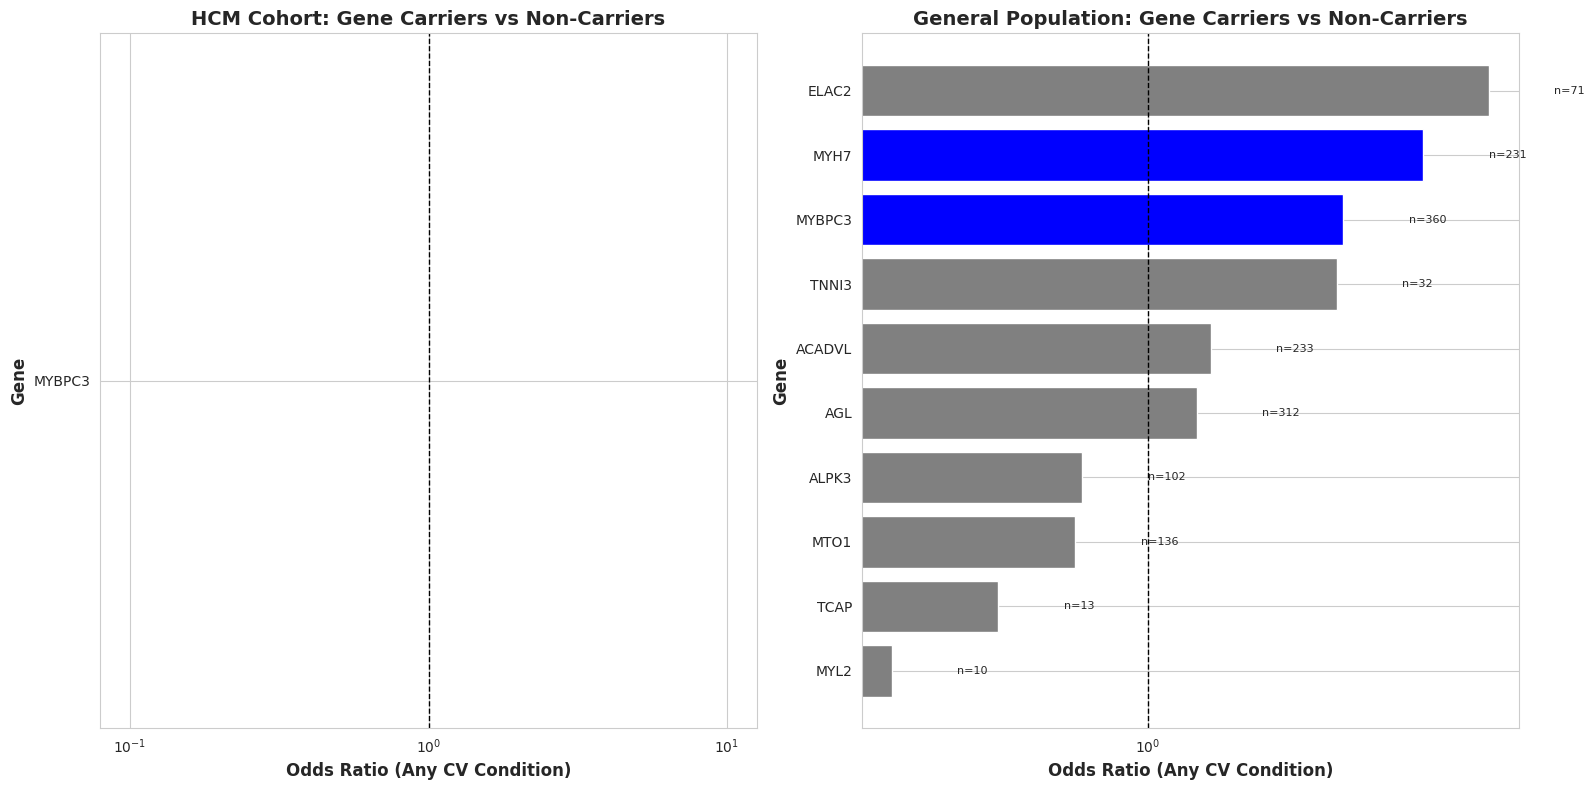


[3] Creating Figure 2: Top enriched conditions by gene...


/var/tmp/ipykernel_4833/3472019338.py:96: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_conditions = df_sig.groupby('gene').apply(


     Saved: figure2_top_conditions_hcm.png


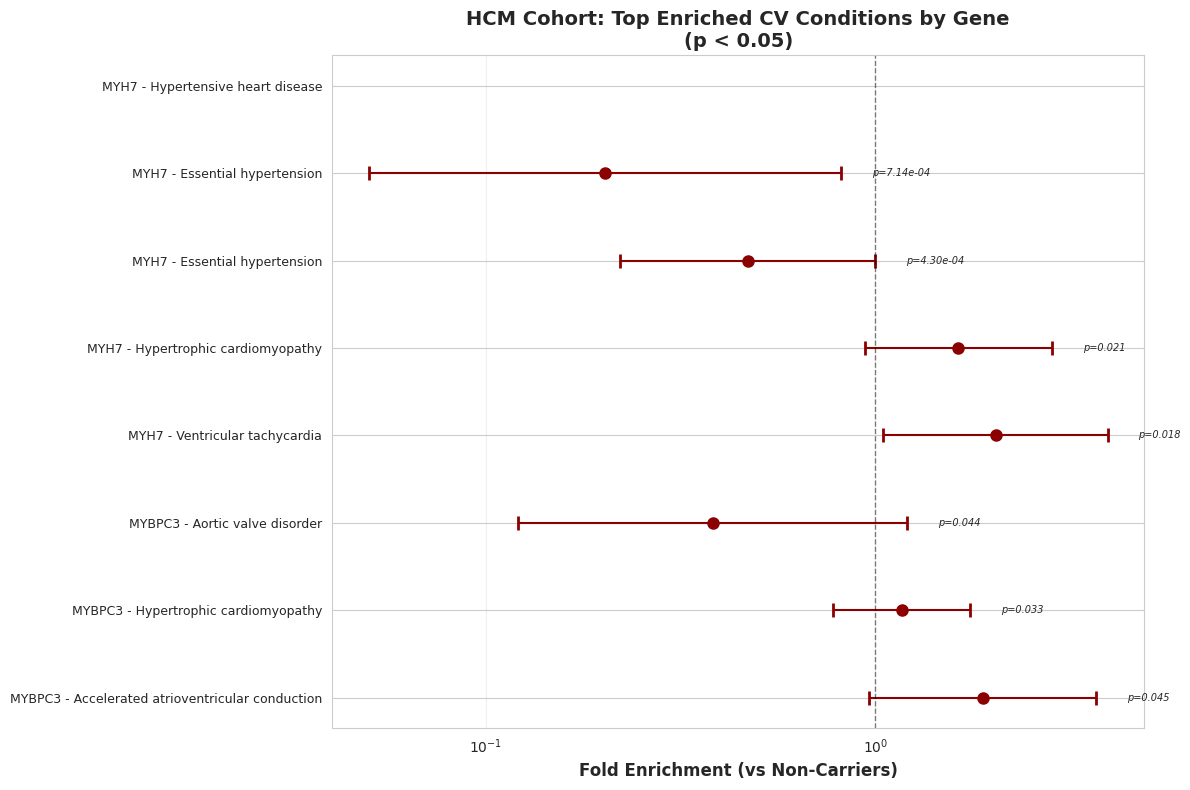

/var/tmp/ipykernel_4833/3472019338.py:96: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_conditions = df_sig.groupby('gene').apply(


     Saved: figure2_top_conditions_genpop.png


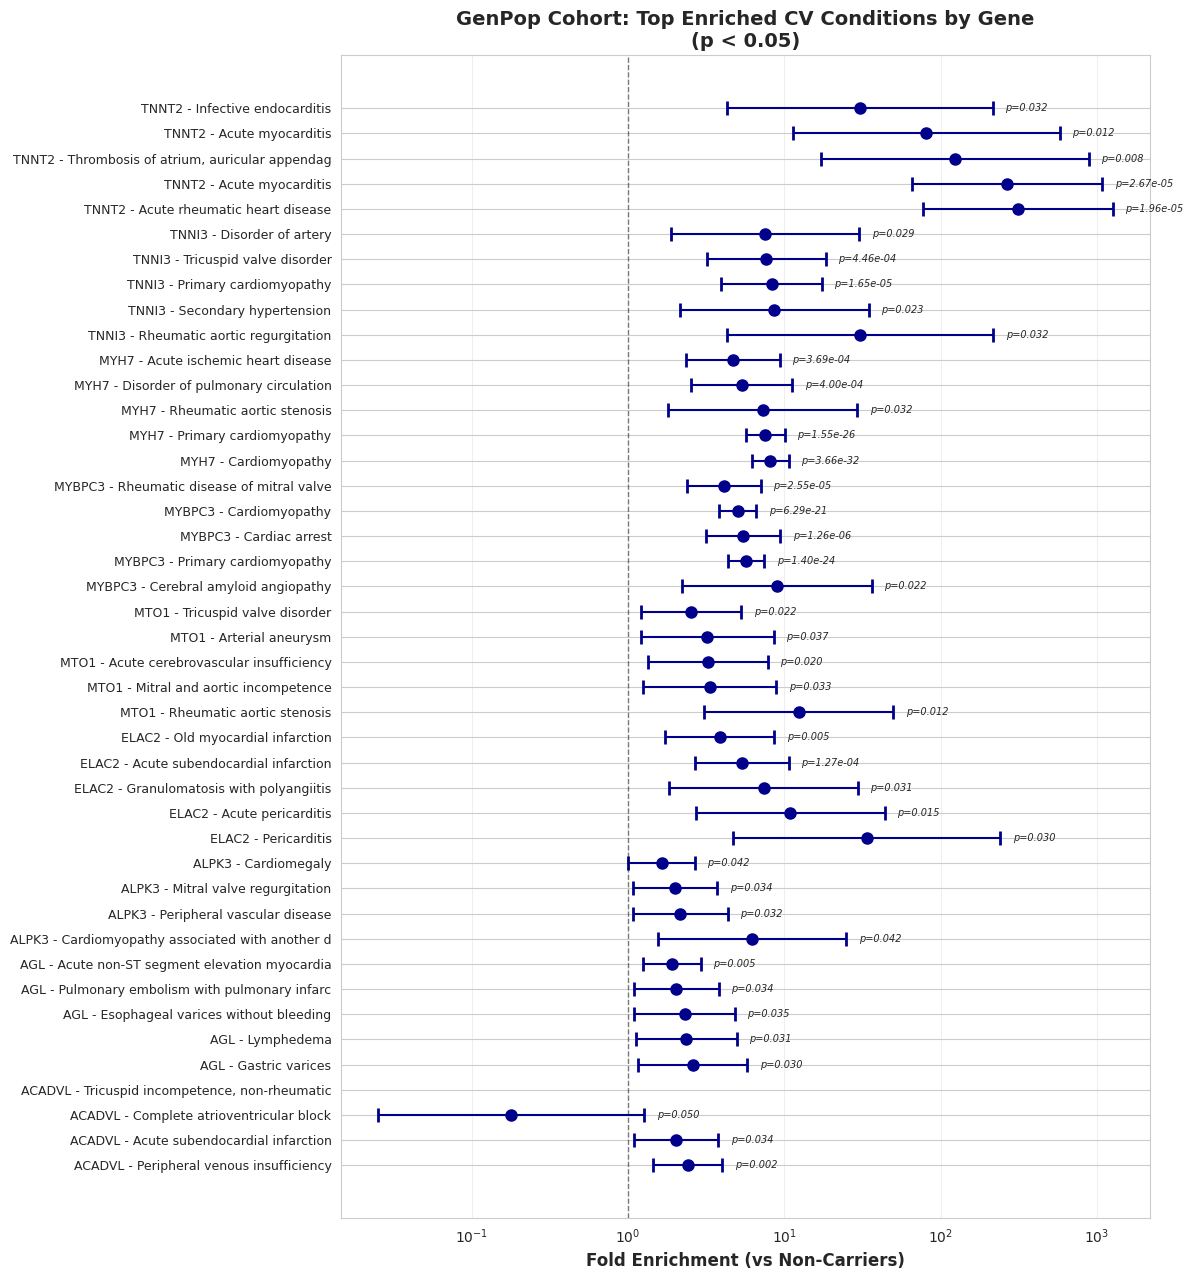


[4] Creating Figure 3: Heatmap of condition enrichment...
     Saved: figure3_heatmap_hcm.png


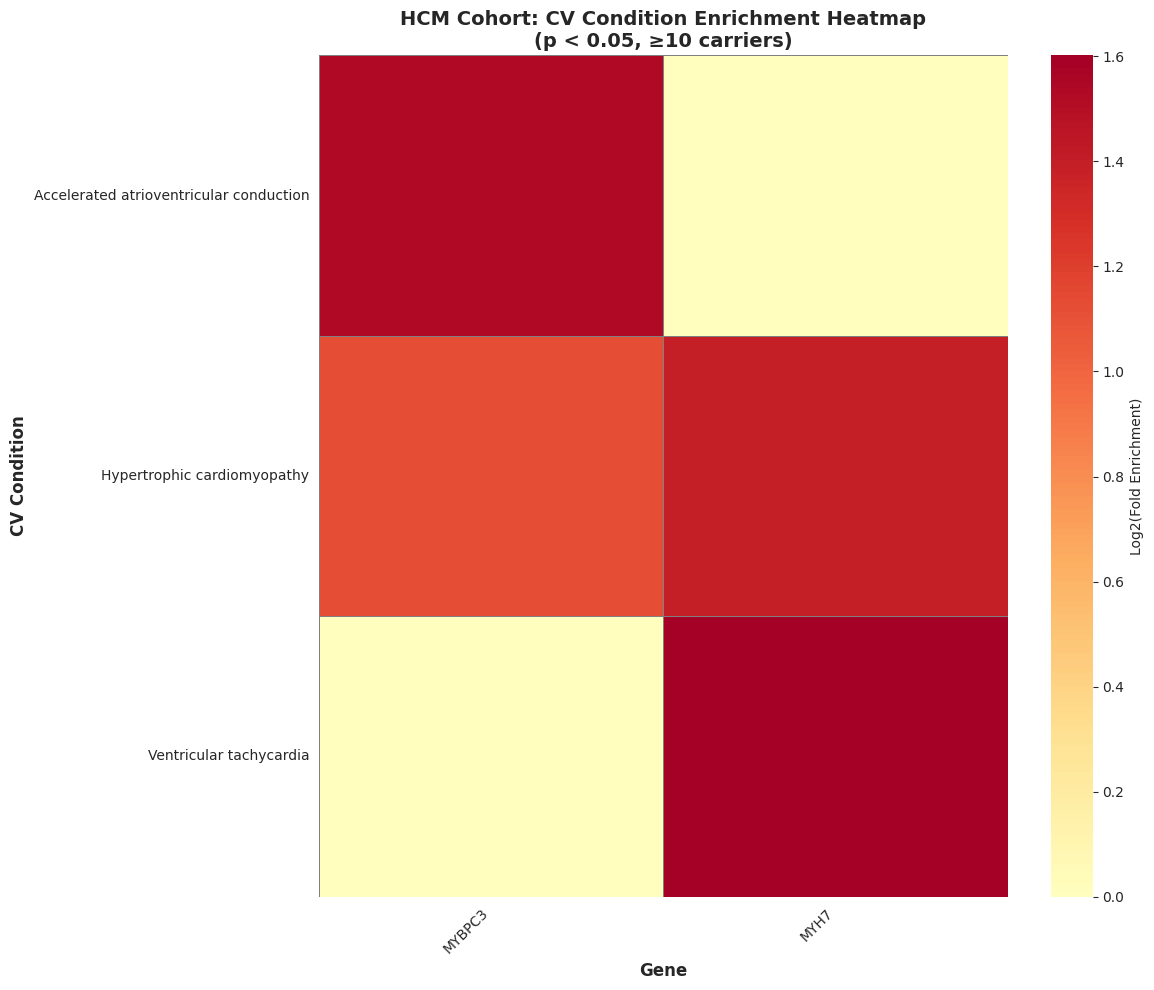

     Saved: figure3_heatmap_genpop.png


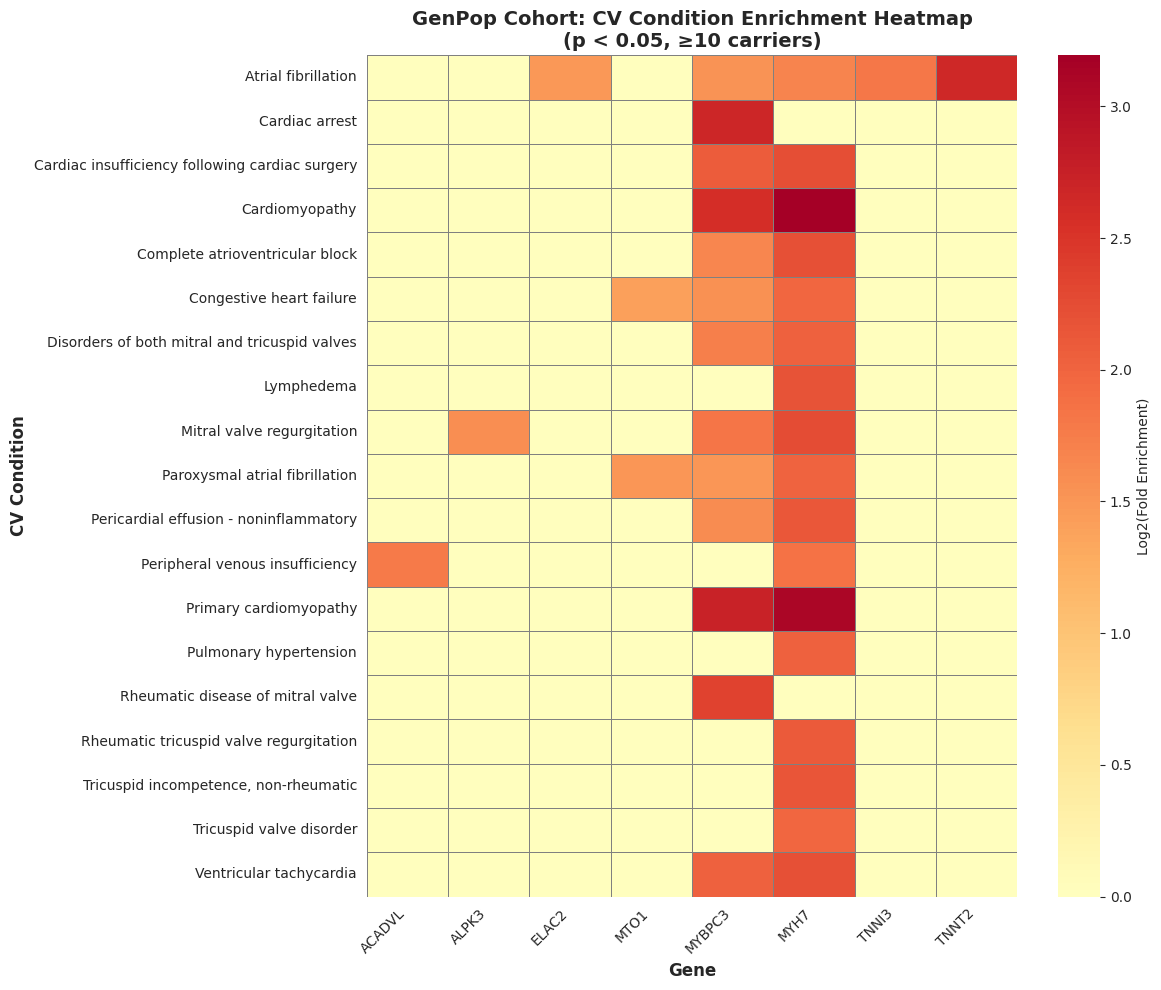


[5] Creating Figure 4: Volcano plots...
     Saved: figure4_volcano_plots.png


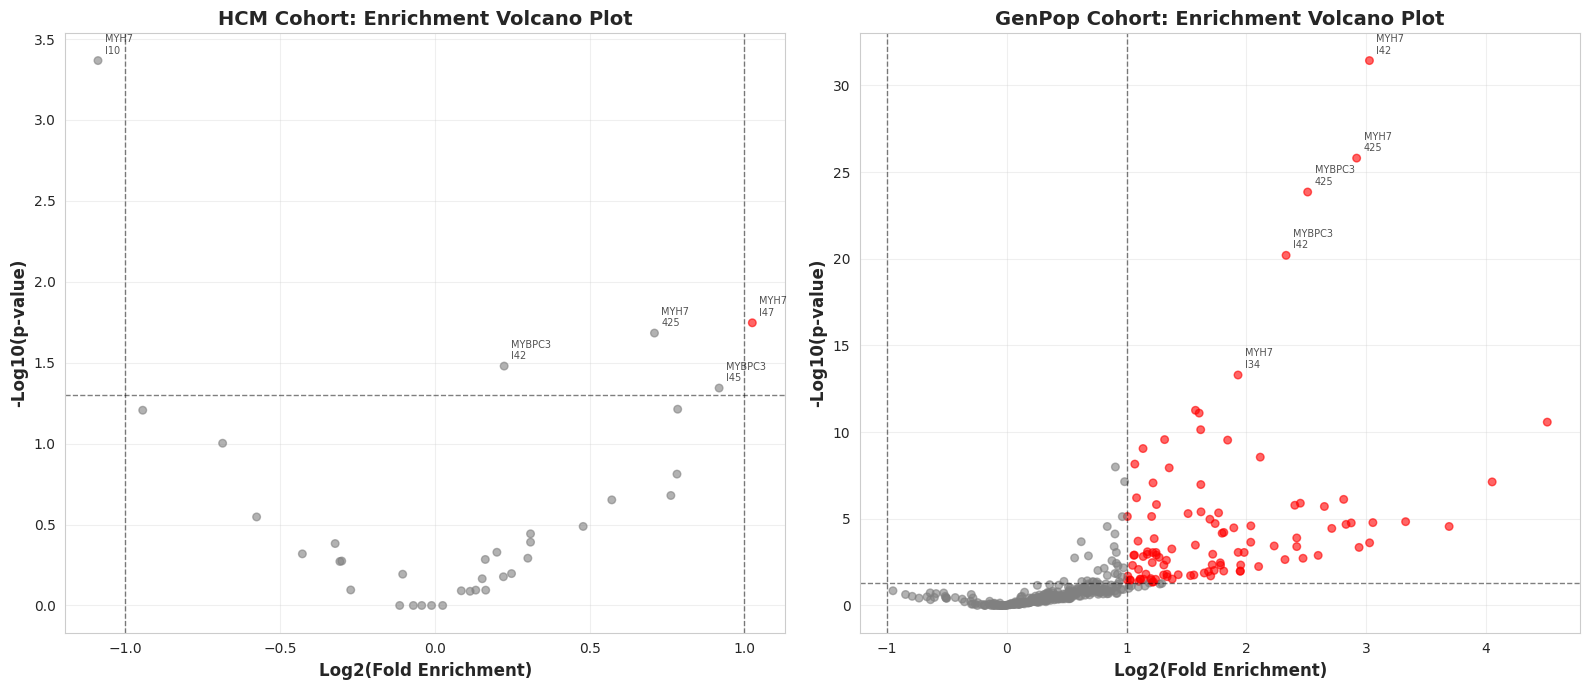


[6] Creating summary statistics table...
     Saved: summary_statistics_by_gene_cv_enrichment.tsv


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats
import numpy as np
print("VISUALIZING GENE-STRATIFIED CV ENRICHMENT RESULTS")
OUTPUT_DIR = "/home/jupyter/Invitae_HCM"
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10

print("\n[1] Loading enrichment results...")

hcm_file = f"{OUTPUT_DIR}/hcm_cohort_gene_stratified_enrichment.tsv"
genpop_file = f"{OUTPUT_DIR}/genpop_gene_stratified_enrichment.tsv"

hcm_df = pd.read_csv(hcm_file, sep='\t')
genpop_df = pd.read_csv(genpop_file, sep='\t')

print(f"    HCM cohort: {len(hcm_df)} condition-gene pairs across {hcm_df['gene'].nunique()} genes")
print(f"    GenPop: {len(genpop_df)} condition-gene pairs across {genpop_df['gene'].nunique()} genes")

# FIGURE 1: OVERALL ENRICHMENT BY GENE (HEATMAP)

print("\n[2] Creating Figure 1: Overall CV enrichment by gene...")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Get overall stats per gene
def get_gene_overall_stats(df):
    gene_stats = df.groupby('gene').agg({
        'n_carriers': 'first',
        'overall_OR': 'first',
        'overall_pvalue': 'first',
        'carrier_count': 'sum',  # total CV conditions
        'noncarrier_count': 'sum'
    }).reset_index()
    
    gene_stats['carrier_rate'] = gene_stats.apply(
        lambda row: (df[df['gene'] == row['gene']]['carrier_count'].sum() / 
                     df[df['gene'] == row['gene']]['n_carriers'].iloc[0] * 100), axis=1
    )
    return gene_stats

hcm_gene_stats = get_gene_overall_stats(hcm_df)
genpop_gene_stats = get_gene_overall_stats(genpop_df)

# Plot HCM
ax1 = axes[0]
hcm_gene_stats_sorted = hcm_gene_stats.sort_values('overall_OR', ascending=True)
colors_hcm = ['red' if p < 0.05 else 'gray' for p in hcm_gene_stats_sorted['overall_pvalue']]

ax1.barh(hcm_gene_stats_sorted['gene'], hcm_gene_stats_sorted['overall_OR'], color=colors_hcm)
ax1.axvline(x=1, color='black', linestyle='--', linewidth=1)
ax1.set_xlabel('Odds Ratio (Any CV Condition)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Gene', fontsize=12, fontweight='bold')
ax1.set_title('HCM Cohort: Gene Carriers vs Non-Carriers', fontsize=14, fontweight='bold')
ax1.set_xscale('log')

# Add sample sizes
for i, row in hcm_gene_stats_sorted.iterrows():
    ax1.text(row['overall_OR'] * 1.1, row['gene'], f"n={int(row['n_carriers'])}", 
             va='center', fontsize=8)

# Plot GenPop
ax2 = axes[1]
genpop_gene_stats_sorted = genpop_gene_stats.sort_values('overall_OR', ascending=True)
colors_genpop = ['blue' if p < 0.05 else 'gray' for p in genpop_gene_stats_sorted['overall_pvalue']]

ax2.barh(genpop_gene_stats_sorted['gene'], genpop_gene_stats_sorted['overall_OR'], color=colors_genpop)
ax2.axvline(x=1, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel('Odds Ratio (Any CV Condition)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Gene', fontsize=12, fontweight='bold')
ax2.set_title('General Population: Gene Carriers vs Non-Carriers', fontsize=14, fontweight='bold')
ax2.set_xscale('log')

# Add sample sizes
for i, row in genpop_gene_stats_sorted.iterrows():
    ax2.text(row['overall_OR'] * 1.1, row['gene'], f"n={int(row['n_carriers'])}", 
             va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure1_overall_enrichment_by_gene.png", dpi=300, bbox_inches='tight')
print(f"     Saved: figure1_overall_enrichment_by_gene.png")
plt.show()

# FIGURE 2: TOP ENRICHED CONDITIONS PER GENE (FOREST PLOT)
print("\n[3] Creating Figure 2: Top enriched conditions by gene...")

def create_forest_plot(df, cohort_name, top_n=5):
    """Create forest plot showing top N conditions per gene"""
    
    # Get top N conditions per gene by fold enrichment and significance
    df_sig = df[df['pvalue'] < 0.05].copy()
    top_conditions = df_sig.groupby('gene').apply(
        lambda x: x.nlargest(top_n, 'fold_enrichment')
    ).reset_index(drop=True)
    
    if len(top_conditions) == 0:
        print(f"      No significant enrichments found for {cohort_name}")
        return
    
    # Calculate 95% CI for fold enrichment (approximate from counts)
    def calc_ci(row):
        if row['carrier_count'] == 0 or row['noncarrier_count'] == 0:
            return (np.nan, np.nan)
        
        # Log transform for CI calculation
        log_fe = np.log(row['fold_enrichment'])
        se = np.sqrt(1/row['carrier_count'] + 1/row['noncarrier_count'])
        ci_lower = np.exp(log_fe - 1.96 * se)
        ci_upper = np.exp(log_fe + 1.96 * se)
        return (ci_lower, ci_upper)
    
    top_conditions[['ci_lower', 'ci_upper']] = top_conditions.apply(
        calc_ci, axis=1, result_type='expand'
    )
    
    # Create label
    top_conditions['label'] = (top_conditions['gene'] + ' - ' + 
                                top_conditions['condition_name'].str[:40])
    
    # Sort by gene then fold enrichment
    top_conditions = top_conditions.sort_values(['gene', 'fold_enrichment'], ascending=[True, False])
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, max(8, len(top_conditions) * 0.3)))
    
    y_positions = np.arange(len(top_conditions))
    
    # Plot points and error bars
    ax.errorbar(top_conditions['fold_enrichment'], y_positions,
                xerr=[top_conditions['fold_enrichment'] - top_conditions['ci_lower'],
                      top_conditions['ci_upper'] - top_conditions['fold_enrichment']],
                fmt='o', markersize=8, capsize=5, capthick=2,
                color='darkred' if cohort_name == 'HCM' else 'darkblue')
    
    ax.axvline(x=1, color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    ax.set_yticks(y_positions)
    ax.set_yticklabels(top_conditions['label'], fontsize=9)
    ax.set_xlabel('Fold Enrichment (vs Non-Carriers)', fontsize=12, fontweight='bold')
    ax.set_title(f'{cohort_name} Cohort: Top Enriched CV Conditions by Gene\n(p < 0.05)', 
                 fontsize=14, fontweight='bold')
    ax.set_xscale('log')
    ax.grid(axis='x', alpha=0.3)
    
    # Add p-values as text
    for i, row in top_conditions.iterrows():
        p_text = f"p={row['pvalue']:.2e}" if row['pvalue'] < 0.001 else f"p={row['pvalue']:.3f}"
        ax.text(row['ci_upper'] * 1.2, y_positions[top_conditions.index.get_loc(i)], 
                p_text, va='center', fontsize=7, style='italic')
    
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/figure2_top_conditions_{cohort_name.lower()}.png", 
                dpi=300, bbox_inches='tight')
    print(f"     Saved: figure2_top_conditions_{cohort_name.lower()}.png")
    plt.show()

create_forest_plot(hcm_df, 'HCM', top_n=5)
create_forest_plot(genpop_df, 'GenPop', top_n=5)

# FIGURE 3: HEATMAP OF CONDITION ENRICHMENT

print("\n[4] Creating Figure 3: Heatmap of condition enrichment...")

def create_enrichment_heatmap(df, cohort_name, min_carriers=10):
    """Create heatmap showing enrichment patterns"""
    
    # Filter to significant and meaningful enrichments
    df_sig = df[(df['pvalue'] < 0.05) & (df['carrier_count'] >= min_carriers)].copy()
    
    if len(df_sig) == 0:
        print(f"      No significant enrichments found for {cohort_name}")
        return
    
    # Get top conditions overall
    top_conditions = df_sig.groupby('icd_prefix')['fold_enrichment'].max().nlargest(20).index
    df_plot = df_sig[df_sig['icd_prefix'].isin(top_conditions)]
    
    # Create pivot table
    pivot = df_plot.pivot_table(
        index='condition_name', 
        columns='gene', 
        values='fold_enrichment',
        fill_value=0
    )
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Use log scale for color mapping
    sns.heatmap(np.log2(pivot + 1), 
                cmap='RdYlBu_r', 
                center=0,
                cbar_kws={'label': 'Log2(Fold Enrichment)'},
                linewidths=0.5,
                linecolor='gray',
                ax=ax)
    
    ax.set_xlabel('Gene', fontsize=12, fontweight='bold')
    ax.set_ylabel('CV Condition', fontsize=12, fontweight='bold')
    ax.set_title(f'{cohort_name} Cohort: CV Condition Enrichment Heatmap\n(p < 0.05, ≥{min_carriers} carriers)', 
                 fontsize=14, fontweight='bold')
    
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/figure3_heatmap_{cohort_name.lower()}.png", 
                dpi=300, bbox_inches='tight')
    print(f"     Saved: figure3_heatmap_{cohort_name.lower()}.png")
    plt.show()

create_enrichment_heatmap(hcm_df, 'HCM')
create_enrichment_heatmap(genpop_df, 'GenPop')


# FIGURE 4: VOLCANO PLOTS

print("\n[5] Creating Figure 4: Volcano plots...")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

def create_volcano_plot(df, ax, cohort_name):
    """Create volcano plot of enrichment vs significance"""
    
    df_plot = df[df['carrier_count'] >= 5].copy()  # Minimum carriers filter
    df_plot['-log10p'] = -np.log10(df_plot['pvalue'])
    df_plot['log2fe'] = np.log2(df_plot['fold_enrichment'])
    
    # Remove infinite values
    df_plot = df_plot[np.isfinite(df_plot['log2fe']) & np.isfinite(df_plot['-log10p'])]
    
    # Color by significance
    colors = ['red' if (p < 0.05 and fe > 2) else 'gray' 
              for p, fe in zip(df_plot['pvalue'], df_plot['fold_enrichment'])]
    
    ax.scatter(df_plot['log2fe'], df_plot['-log10p'], 
               c=colors, alpha=0.6, s=30)
    
    # Add threshold lines
    ax.axhline(y=-np.log10(0.05), color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(x=np.log2(2), color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(x=-np.log2(2), color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    ax.set_xlabel('Log2(Fold Enrichment)', fontsize=12, fontweight='bold')
    ax.set_ylabel('-Log10(p-value)', fontsize=12, fontweight='bold')
    ax.set_title(f'{cohort_name} Cohort: Enrichment Volcano Plot', 
                 fontsize=14, fontweight='bold')
    
    # Label top points
    df_top = df_plot.nlargest(5, '-log10p')
    for _, row in df_top.iterrows():
        ax.annotate(f"{row['gene']}\n{row['icd_prefix']}", 
                   xy=(row['log2fe'], row['-log10p']),
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=7, alpha=0.8)
    
    ax.grid(alpha=0.3)

create_volcano_plot(hcm_df, axes[0], 'HCM')
create_volcano_plot(genpop_df, axes[1], 'GenPop')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure4_volcano_plots.png", dpi=300, bbox_inches='tight')
print(f"     Saved: figure4_volcano_plots.png")
plt.show()


# SUMMARY STATISTICS TABLE

print("\n[6] Creating summary statistics table...")

summary_data = []

for gene in pd.concat([hcm_df['gene'], genpop_df['gene']]).unique():
    row = {'gene': gene}
    
    # HCM stats
    if gene in hcm_df['gene'].values:
        hcm_gene = hcm_df[hcm_df['gene'] == gene]
        row['hcm_n_carriers'] = int(hcm_gene['n_carriers'].iloc[0])
        row['hcm_overall_OR'] = hcm_gene['overall_OR'].iloc[0]
        row['hcm_overall_p'] = hcm_gene['overall_pvalue'].iloc[0]
        row['hcm_n_sig_conditions'] = (hcm_gene['pvalue'] < 0.05).sum()
    else:
        row['hcm_n_carriers'] = 0
        row['hcm_overall_OR'] = np.nan
        row['hcm_overall_p'] = np.nan
        row['hcm_n_sig_conditions'] = 0
    
    # GenPop stats
    if gene in genpop_df['gene'].values:
        gp_gene = genpop_df[genpop_df['gene'] == gene]
        row['genpop_n_carriers'] = int(gp_gene['n_carriers'].iloc[0])
        row['genpop_overall_OR'] = gp_gene['overall_OR'].iloc[0]
        row['genpop_overall_p'] = gp_gene['overall_pvalue'].iloc[0]
        row['genpop_n_sig_conditions'] = (gp_gene['pvalue'] < 0.05).sum()
    else:
        row['genpop_n_carriers'] = 0
        row['genpop_overall_OR'] = np.nan
        row['genpop_overall_p'] = np.nan
        row['genpop_n_sig_conditions'] = 0
    
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('hcm_n_carriers', ascending=False)

summary_df.to_csv(f"{OUTPUT_DIR}/summary_statistics_by_gene_cv_enrichment.tsv", sep='\t', index=False)
print(f"     Saved: summary_statistics_by_gene_cv_enrichment.tsv")

In [3]:
import pandas as pd
import numpy as np
from google.cloud import bigquery

# ============================================================================
# SETUP
# ============================================================================

OUTPUT_DIR = '/home/jupyter/Invitae_HCM'
OMOP_DATASET = "nb-tre-dev-2-483522.omop_dataset_v2026_1_1"

client = bigquery.Client()

print("EXTRACTING AGE AT LAST VISIT - CARRIERS ONLY")

print("\nSTEP 1: Load carrier data")

all_carriers = pd.read_csv(f"{OUTPUT_DIR}/all_carriers_long_format.tsv", sep='\t')
print(f" Loaded all carriers: {len(all_carriers['IID'].unique()):,} individuals")

# Load HCM cohort membership
hcm_cohort = pd.read_csv('/home/jupyter/prs_output/hcm_cohort.keep', sep='\s+', header=None, names=['FID', 'IID'])
print(f" Loaded HCM cohort: {len(hcm_cohort):,} individuals")

# Get unique IDs
hcm_cohort_ids = set(hcm_cohort['IID'].unique())
all_carrier_ids = set(all_carriers['IID'].unique())

# ============================================================================
# STEP 2: Define the two groups
# ============================================================================

# Group A: HCM cohort carriers
hcm_cohort_carrier_ids = list(hcm_cohort_ids & all_carrier_ids)
print(f"\nGroup A (HCM Cohort - Carriers): {len(hcm_cohort_carrier_ids):,} individuals")

# Group B: General population carriers (NOT in HCM cohort)
gen_pop_carrier_ids = list(all_carrier_ids - hcm_cohort_ids)
print(f"Group B (General Population - Carriers): {len(gen_pop_carrier_ids):,} individuals")

# Verify no overlap
overlap = set(hcm_cohort_carrier_ids) & set(gen_pop_carrier_ids)
print(f"\n Overlap check: {len(overlap)} individuals (should be 0)")

print("STEP 3: Query age at last visit from OMOP")

# Convert to strings for BigQuery
hcm_cohort_carrier_str = "', '".join(str(x) for x in hcm_cohort_carrier_ids)
gen_pop_carrier_str = "', '".join(str(x) for x in gen_pop_carrier_ids)

# Query to get age at last visit for BOTH groups
query_age_at_last_visit = f"""
WITH last_visit AS (
    SELECT 
        vo.person_id,
        MAX(vo.visit_start_date) as last_visit_date,
        COUNT(*) as total_visits
    FROM `{OMOP_DATASET}.visit_occurrence` vo
    WHERE vo.person_id IN ('{hcm_cohort_carrier_str}')
          OR vo.person_id IN ('{gen_pop_carrier_str}')
    GROUP BY vo.person_id
),

age_calculation AS (
    SELECT 
        lv.person_id,
        lv.last_visit_date,
        lv.total_visits,
        p.birth_datetime,
        p.gender_concept_id,
        DATE_DIFF(lv.last_visit_date, DATE(p.birth_datetime), YEAR) as age_at_last_visit,
        CASE 
            WHEN lv.person_id IN ('{hcm_cohort_carrier_str}') THEN 'HCM Cohort - Carriers'
            WHEN lv.person_id IN ('{gen_pop_carrier_str}') THEN 'General Population - Carriers'
            ELSE 'Other'
        END as cohort_type
    FROM last_visit lv
    INNER JOIN `{OMOP_DATASET}.person` p ON lv.person_id = p.person_id
)

SELECT *
FROM age_calculation
WHERE age_at_last_visit >= 0 AND age_at_last_visit <= 120  -- Filter out impossible ages
    AND cohort_type != 'Other'
ORDER BY cohort_type, age_at_last_visit
"""

print("\nQuerying age at last visit from OMOP...")
age_at_last_visit = client.query(query_age_at_last_visit).to_dataframe()

print("RESULTS")

print(f"\nTotal records found: {len(age_at_last_visit):,}")
print(f"\nBreakdown by group:")
print(age_at_last_visit['cohort_type'].value_counts())

if len(age_at_last_visit) > 0:
    # Summary statistics
    print("AGE AT LAST VISIT STATISTICS")
    
    for cohort_type in ['HCM Cohort - Carriers', 'General Population - Carriers']:
        data = age_at_last_visit[age_at_last_visit['cohort_type'] == cohort_type]['age_at_last_visit']
        if len(data) > 0:
            print(f"\n{cohort_type}:")
            print(f"  N = {len(data):,}")
            print(f"  Mean age: {data.mean():.1f} years (SD: {data.std():.1f})")
            print(f"  Median age: {data.median():.1f} years")
            print(f"  IQR: {data.quantile(0.25):.1f} - {data.quantile(0.75):.1f} years")
            print(f"  Range: {data.min():.0f} - {data.max():.0f} years")
        else:
            print(f"\n{cohort_type}: No data found")
    
    # Save
    output_file = f"{OUTPUT_DIR}/age_at_last_visit_carriers_only.tsv"
    age_at_last_visit.to_csv(output_file, sep='\t', index=False)
    print(f"\n Saved: {output_file}")
    
    # Check for missing people
    print("MISSING DATA CHECK")
    
    found_hcm = set(age_at_last_visit[age_at_last_visit['cohort_type'] == 'HCM Cohort - Carriers']['person_id'])
    found_gen = set(age_at_last_visit[age_at_last_visit['cohort_type'] == 'General Population - Carriers']['person_id'])
    
    missing_hcm = len(hcm_cohort_carrier_ids) - len(found_hcm)
    missing_gen = len(gen_pop_carrier_ids) - len(found_gen)
    
    print(f"\nHCM Cohort - Carriers: {len(found_hcm):,} / {len(hcm_cohort_carrier_ids):,} found ({missing_hcm:,} missing)")
    print(f"General Population - Carriers: {len(found_gen):,} / {len(gen_pop_carrier_ids):,} found ({missing_gen:,} missing)")
else:
    print("\n No age data found!")

EXTRACTING AGE AT LAST VISIT - CARRIERS ONLY

STEP 1: Load carrier data
 Loaded all carriers: 1,558 individuals
 Loaded HCM cohort: 331 individuals

Group A (HCM Cohort - Carriers): 46 individuals
Group B (General Population - Carriers): 1,512 individuals

 Overlap check: 0 individuals (should be 0)
STEP 3: Query age at last visit from OMOP

Querying age at last visit from OMOP...
RESULTS

Total records found: 1,556

Breakdown by group:
cohort_type
General Population - Carriers    1510
HCM Cohort - Carriers              46
Name: count, dtype: int64
AGE AT LAST VISIT STATISTICS

HCM Cohort - Carriers:
  N = 46
  Mean age: 50.4 years (SD: 19.7)
  Median age: 50.5 years
  IQR: 34.2 - 65.0 years
  Range: 20 - 90 years

General Population - Carriers:
  N = 1,510
  Mean age: 51.0 years (SD: 21.3)
  Median age: 54.0 years
  IQR: 35.0 - 68.0 years
  Range: 0 - 90 years

 Saved: /home/jupyter/Invitae_HCM/age_at_last_visit_carriers_only.tsv
MISSING DATA CHECK

HCM Cohort - Carriers: 46 / 46 foun

AGE AT LAST VISIT COMPARISON - CARRIERS ONLY

Total records: 1,556

Cohort breakdown:
cohort_type
General Population - Carriers    1510
HCM Cohort - Carriers              46
Name: count, dtype: int64

Final dataset: 1,556 records
GROUP STATISTICS

GROUP A: HCM Cohort - Carriers
N = 46
Mean age at last visit:   50.4 ± 19.7 years
Median age at last visit: 50.5 years
Range: 20.0 - 90.0 years
IQR: Q1=34.2, Q3=65.0

Percentiles:
   5th percentile:  22.0 years
  10th percentile:  24.0 years
  25th percentile:  34.2 years
  50th percentile:  50.5 years
  75th percentile:  65.0 years
  90th percentile:  76.0 years
  95th percentile:  82.0 years


GROUP B: General Population - Carriers
N = 1,510
Mean age at last visit:   51.0 ± 21.3 years
Median age at last visit: 54.0 years
Range: 0.0 - 90.0 years
IQR: Q1=35.0, Q3=68.0

Percentiles:
   5th percentile:  14.0 years
  10th percentile:  21.0 years
  25th percentile:  35.0 years
  50th percentile:  54.0 years
  75th percentile:  68.0 years
  90th p

/var/tmp/ipykernel_9836/644553794.py:191: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_for_box, labels=labels_for_box, patch_artist=True,



 Plot saved: age_distribution_carriers_only.png


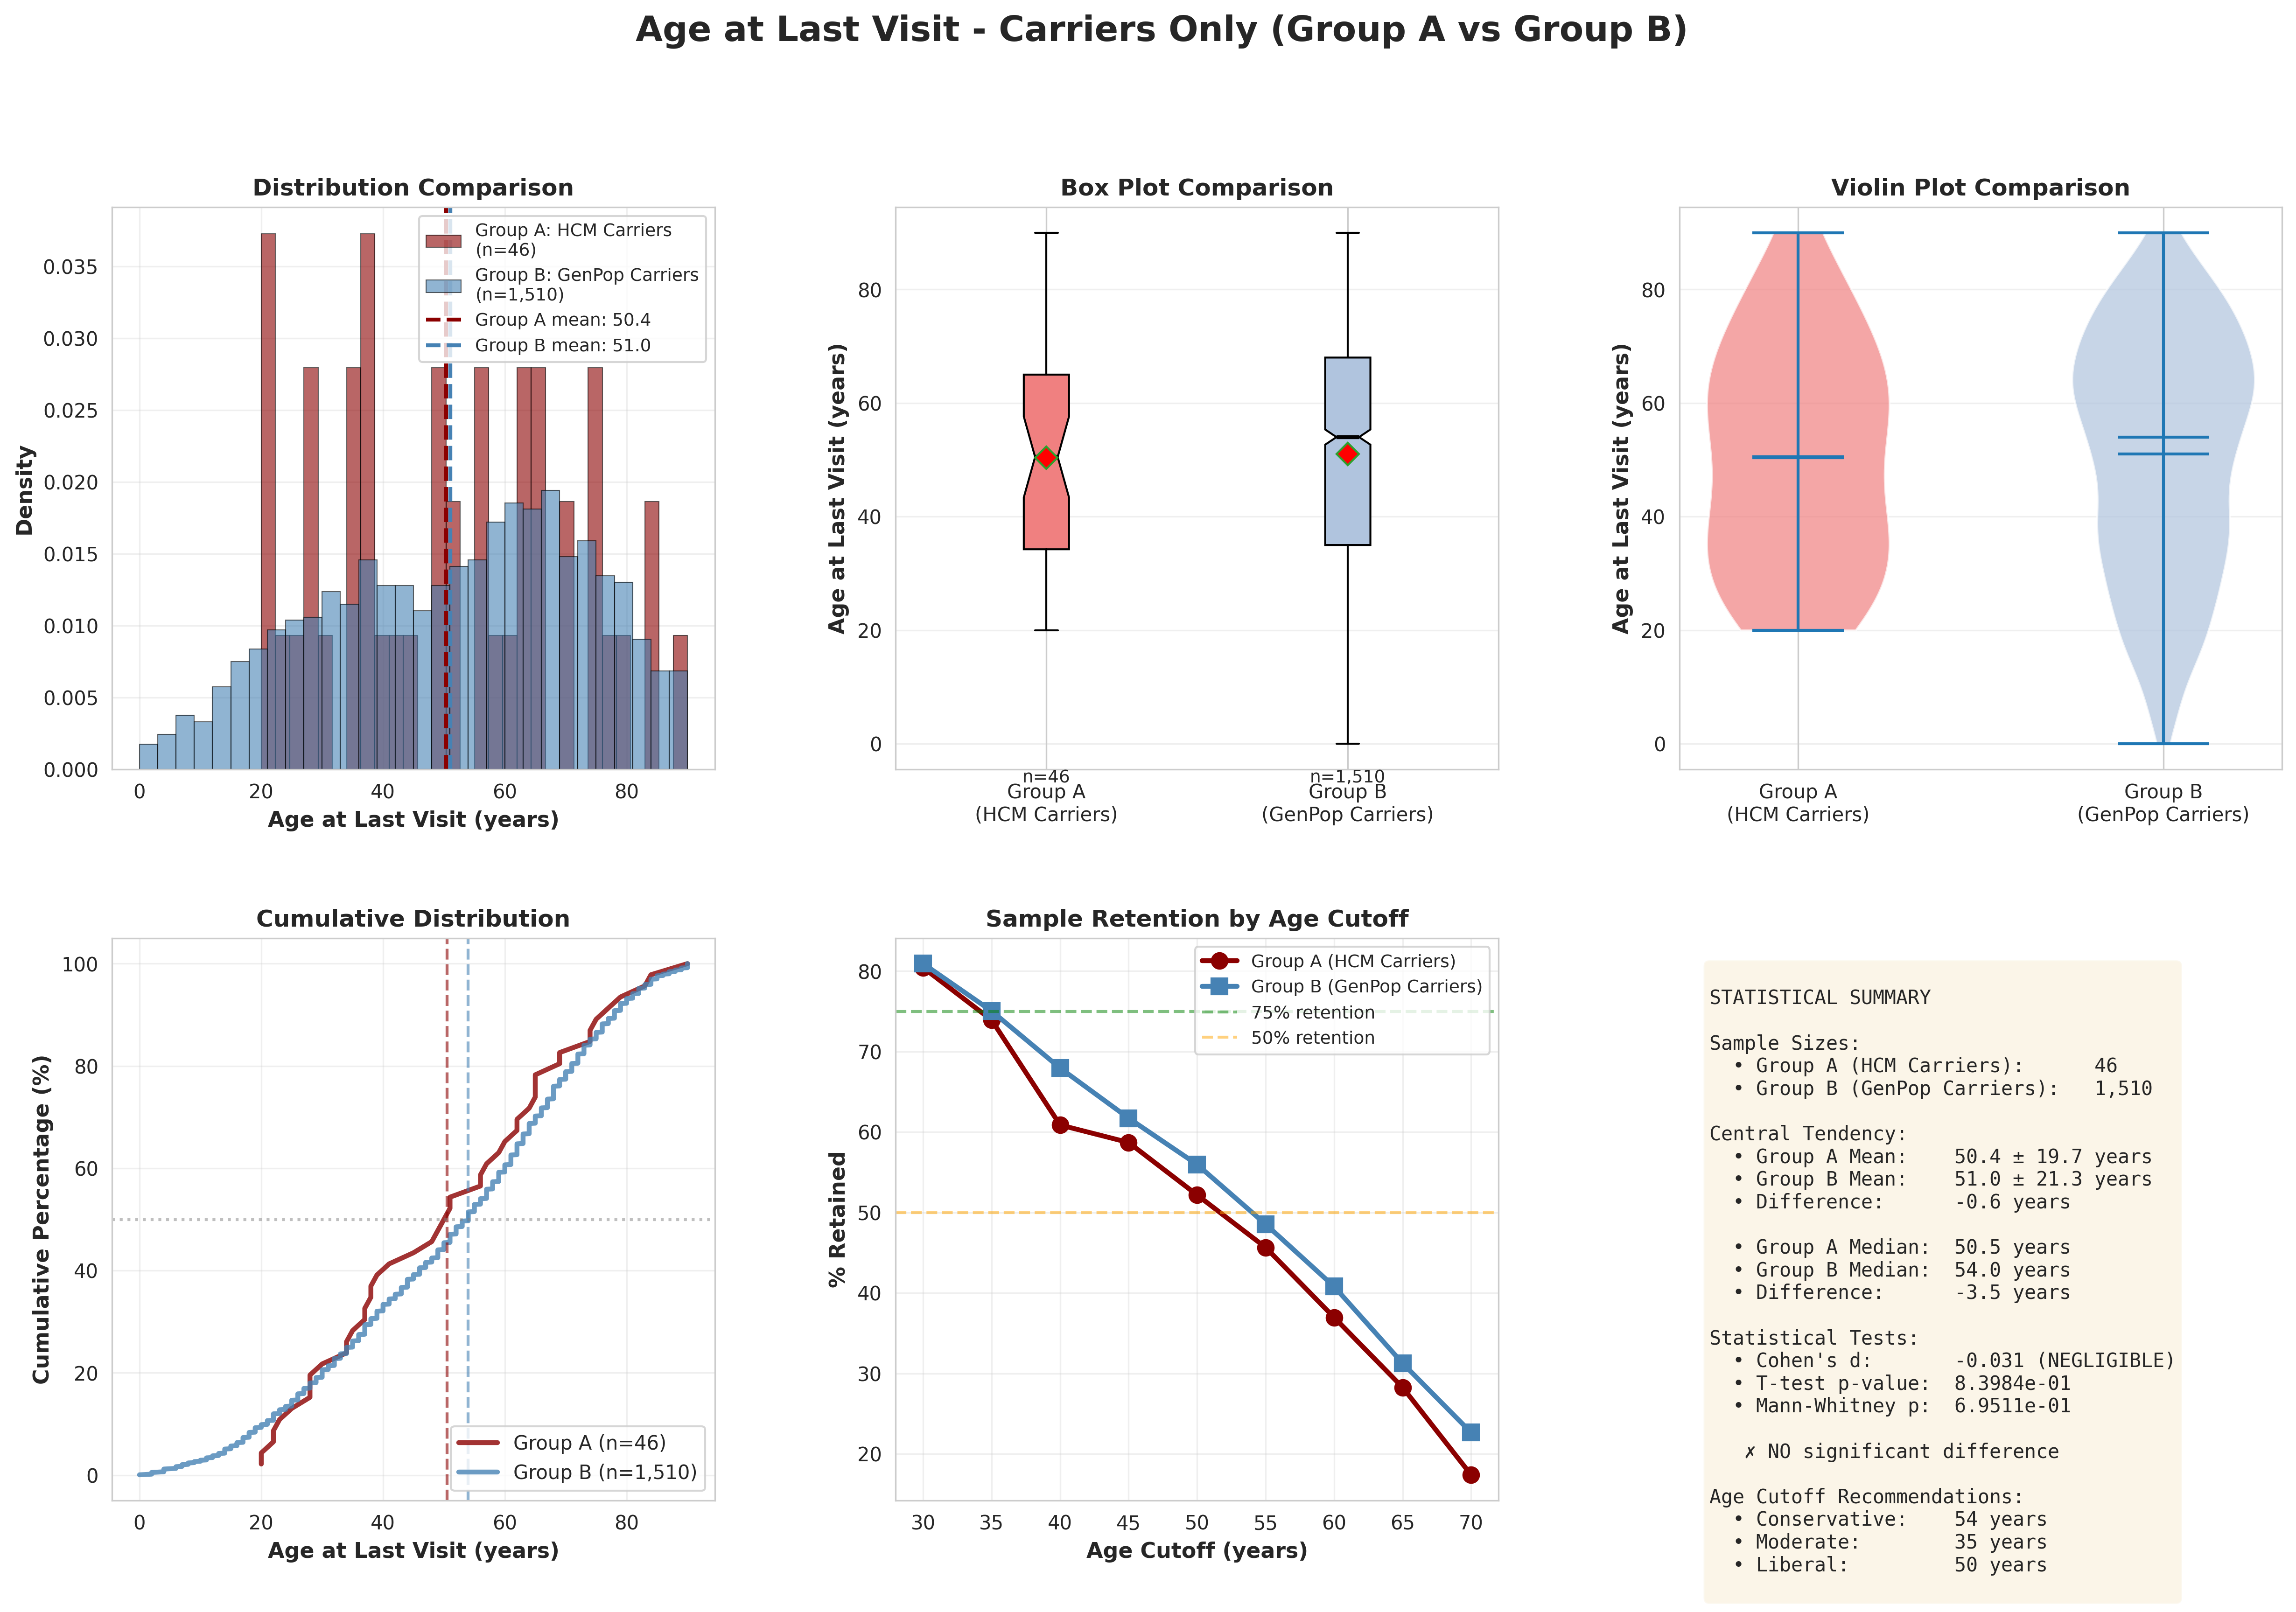

 RECOMMENDATION FOR YOUR PRS STUDY

 Effect size is NEGLIGIBLE (Cohen's d < 0.2)
Groups have similar age distributions

 RECOMMENDATION: NO age cutoff needed


In [16]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

age_data = pd.read_csv('/home/jupyter/Invitae_HCM/age_at_last_visit_carriers_only.tsv', sep='\t')

print("AGE AT LAST VISIT COMPARISON - CARRIERS ONLY")

# Check what we have
print(f"\nTotal records: {len(age_data):,}")
print(f"\nCohort breakdown:")
print(age_data['cohort_type'].value_counts())

# Remove any rows with missing age
carriers_clean = age_data.dropna(subset=['age_at_last_visit']).copy()

if len(carriers_clean) < len(age_data):
    print(f"\n Removed {len(age_data) - len(carriers_clean)} rows with missing age")

print(f"\nFinal dataset: {len(carriers_clean):,} records")

# ============================================================================
# GROUP STATISTICS
# ============================================================================

print("GROUP STATISTICS")

# Group A: HCM Cohort Carriers
group_a = carriers_clean[carriers_clean['cohort_type'] == 'HCM Cohort - Carriers'].copy()

# Group B: General Population Carriers
group_b = carriers_clean[carriers_clean['cohort_type'] == 'General Population - Carriers'].copy()

print(f"\nGROUP A: HCM Cohort - Carriers")
print(f"N = {len(group_a):,}")
print(f"Mean age at last visit:   {group_a['age_at_last_visit'].mean():.1f} ± {group_a['age_at_last_visit'].std():.1f} years")
print(f"Median age at last visit: {group_a['age_at_last_visit'].median():.1f} years")
print(f"Range: {group_a['age_at_last_visit'].min():.1f} - {group_a['age_at_last_visit'].max():.1f} years")
print(f"IQR: Q1={group_a['age_at_last_visit'].quantile(0.25):.1f}, Q3={group_a['age_at_last_visit'].quantile(0.75):.1f}")

print(f"\nPercentiles:")
for p in [5, 10, 25, 50, 75, 90, 95]:
    val = group_a['age_at_last_visit'].quantile(p/100)
    print(f"  {p:2d}th percentile: {val:5.1f} years")

print(f"\n\nGROUP B: General Population - Carriers")
print(f"N = {len(group_b):,}")
print(f"Mean age at last visit:   {group_b['age_at_last_visit'].mean():.1f} ± {group_b['age_at_last_visit'].std():.1f} years")
print(f"Median age at last visit: {group_b['age_at_last_visit'].median():.1f} years")
print(f"Range: {group_b['age_at_last_visit'].min():.1f} - {group_b['age_at_last_visit'].max():.1f} years")
print(f"IQR: Q1={group_b['age_at_last_visit'].quantile(0.25):.1f}, Q3={group_b['age_at_last_visit'].quantile(0.75):.1f}")

print(f"\nPercentiles:")
for p in [5, 10, 25, 50, 75, 90, 95]:
    val = group_b['age_at_last_visit'].quantile(p/100)
    print(f"  {p:2d}th percentile: {val:5.1f} years")

# ============================================================================
# STATISTICAL COMPARISON
# ============================================================================

print("STATISTICAL COMPARISON: GROUP A vs GROUP B")

mean_diff = group_a['age_at_last_visit'].mean() - group_b['age_at_last_visit'].mean()
median_diff = group_a['age_at_last_visit'].median() - group_b['age_at_last_visit'].median()

# T-test
t_stat, t_pval = stats.ttest_ind(group_a['age_at_last_visit'], 
                                  group_b['age_at_last_visit'])

# Mann-Whitney U test (non-parametric)
mw_stat, mw_pval = stats.mannwhitneyu(group_a['age_at_last_visit'], 
                                       group_b['age_at_last_visit'])

# Cohen's d (effect size)
pooled_std = np.sqrt((group_a['age_at_last_visit'].std()**2 + 
                      group_b['age_at_last_visit'].std()**2) / 2)
cohens_d = mean_diff / pooled_std

# Levene's test for equal variances
levene_stat, levene_pval = stats.levene(group_a['age_at_last_visit'], 
                                        group_b['age_at_last_visit'])

print(f"\nMean difference:   {mean_diff:+.2f} years")
print(f"Median difference: {median_diff:+.2f} years")
print(f"\nEffect size (Cohen's d): {cohens_d:.3f}")
if abs(cohens_d) < 0.2:
    effect_desc = "NEGLIGIBLE"
elif abs(cohens_d) < 0.5:
    effect_desc = "SMALL"
elif abs(cohens_d) < 0.8:
    effect_desc = "MEDIUM"
else:
    effect_desc = "LARGE"
print(f"    {effect_desc} effect size")

print(f"\nT-test:")
print(f"  t-statistic = {t_stat:.3f}")
print(f"  p-value = {t_pval:.4e}")
print(f"  {' SIGNIFICANT' if t_pval < 0.05 else '✗ NOT significant'} at α=0.05")

print(f"\nMann-Whitney U test:")
print(f"  U-statistic = {mw_stat:.1f}")
print(f"  p-value = {mw_pval:.4e}")
print(f"  {' SIGNIFICANT' if mw_pval < 0.05 else '✗ NOT significant'} at α=0.05")

print(f"\nLevene's test (equal variances):")
print(f"  p-value = {levene_pval:.4f}")
print(f"   Variances are {'DIFFERENT' if levene_pval < 0.05 else 'similar'}")

print("AGE CUTOFF ANALYSIS")
print("\n DIFFERENT CUTOFF OPTIONS:\n")

# Option 1: Based on younger group's median
cutoff_1 = min(group_a['age_at_last_visit'].median(), 
               group_b['age_at_last_visit'].median())
n_a_1 = (group_a['age_at_last_visit'] >= cutoff_1).sum()
n_b_1 = (group_b['age_at_last_visit'] >= cutoff_1).sum()
print(f"Option 1: Median of younger group = {cutoff_1:.0f} years")
print(f"  Group A retained: {n_a_1:,} / {len(group_a):,} ({100*n_a_1/len(group_a):.1f}%)")
print(f"  Group B retained: {n_b_1:,} / {len(group_b):,} ({100*n_b_1/len(group_b):.1f}%)")

# Option 2: Based on older group's Q1
cutoff_2 = max(group_a['age_at_last_visit'].quantile(0.25), 
               group_b['age_at_last_visit'].quantile(0.25))
n_a_2 = (group_a['age_at_last_visit'] >= cutoff_2).sum()
n_b_2 = (group_b['age_at_last_visit'] >= cutoff_2).sum()
print(f"\nOption 2: Q1 of older group = {cutoff_2:.0f} years")
print(f"  Group A retained: {n_a_2:,} / {len(group_a):,} ({100*n_a_2/len(group_a):.1f}%)")
print(f"  Group B retained: {n_b_2:,} / {len(group_b):,} ({100*n_b_2/len(group_b):.1f}%)")

# Option 3: Conservative (older group's median)
cutoff_3 = max(group_a['age_at_last_visit'].median(), 
               group_b['age_at_last_visit'].median())
n_a_3 = (group_a['age_at_last_visit'] >= cutoff_3).sum()
n_b_3 = (group_b['age_at_last_visit'] >= cutoff_3).sum()
print(f"\nOption 3: Median of older group = {cutoff_3:.0f} years (CONSERVATIVE)")
print(f"  Group A retained: {n_a_3:,} / {len(group_a):,} ({100*n_a_3/len(group_a):.1f}%)")
print(f"  Group B retained: {n_b_3:,} / {len(group_b):,} ({100*n_b_3/len(group_b):.1f}%)")

# Option 4: Round numbers
for cutoff in [40, 45, 50, 55, 60]:
    n_a = (group_a['age_at_last_visit'] >= cutoff).sum()
    n_b = (group_b['age_at_last_visit'] >= cutoff).sum()
    print(f"\nOption: Age ≥ {cutoff} years")
    print(f"  Group A retained: {n_a:,} / {len(group_a):,} ({100*n_a/len(group_a):.1f}%)")
    print(f"  Group B retained: {n_b:,} / {len(group_b):,} ({100*n_b/len(group_b):.1f}%)")

# ============================================================================
# VISUALIZATION
# ============================================================================

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

fig.suptitle('Age at Last Visit - Carriers Only (Group A vs Group B)', 
             fontsize=18, fontweight='bold', y=0.995)

# PLOT 1: Overlapping Histograms
ax1 = fig.add_subplot(gs[0, 0])

ax1.hist(group_a['age_at_last_visit'], bins=30, alpha=0.6, 
         label=f'Group A: HCM Carriers\n(n={len(group_a):,})', 
         color='darkred', density=True, edgecolor='black', linewidth=0.5)
ax1.hist(group_b['age_at_last_visit'], bins=30, alpha=0.6, 
         label=f'Group B: GenPop Carriers\n(n={len(group_b):,})', 
         color='steelblue', density=True, edgecolor='black', linewidth=0.5)

# Add mean lines
mean_a = group_a['age_at_last_visit'].mean()
mean_b = group_b['age_at_last_visit'].mean()
ax1.axvline(mean_a, color='darkred', linestyle='--', linewidth=2, 
            label=f'Group A mean: {mean_a:.1f}')
ax1.axvline(mean_b, color='steelblue', linestyle='--', linewidth=2, 
            label=f'Group B mean: {mean_b:.1f}')

ax1.set_xlabel('Age at Last Visit (years)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Density', fontsize=11, fontweight='bold')
ax1.set_title('Distribution Comparison', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

# PLOT 2: Box Plots
ax2 = fig.add_subplot(gs[0, 1])

data_for_box = [group_a['age_at_last_visit'], group_b['age_at_last_visit']]
labels_for_box = ['Group A\n(HCM Carriers)', 'Group B\n(GenPop Carriers)']

bp = ax2.boxplot(data_for_box, labels=labels_for_box, patch_artist=True,
                 notch=True, showmeans=True,
                 meanprops=dict(marker='D', markerfacecolor='red', markersize=8),
                 medianprops=dict(color='black', linewidth=2))

bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('lightsteelblue')

ax2.set_ylabel('Age at Last Visit (years)', fontsize=11, fontweight='bold')
ax2.set_title('Box Plot Comparison', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Add sample sizes
ax2.text(1, ax2.get_ylim()[0], f'n={len(group_a):,}', 
         ha='center', va='top', fontsize=9)
ax2.text(2, ax2.get_ylim()[0], f'n={len(group_b):,}', 
         ha='center', va='top', fontsize=9)

# PLOT 3: Violin Plots
ax3 = fig.add_subplot(gs[0, 2])

parts = ax3.violinplot([group_a['age_at_last_visit'], group_b['age_at_last_visit']], 
                       positions=[1, 2], showmeans=True, showmedians=True)

for i, pc in enumerate(parts['bodies']):
    if i == 0:
        pc.set_facecolor('lightcoral')
        pc.set_alpha(0.7)
    else:
        pc.set_facecolor('lightsteelblue')
        pc.set_alpha(0.7)

ax3.set_xticks([1, 2])
ax3.set_xticklabels(['Group A\n(HCM Carriers)', 'Group B\n(GenPop Carriers)'])
ax3.set_ylabel('Age at Last Visit (years)', fontsize=11, fontweight='bold')
ax3.set_title('Violin Plot Comparison', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# PLOT 4: Cumulative Distribution
ax4 = fig.add_subplot(gs[1, 0])

sorted_a = np.sort(group_a['age_at_last_visit'])
sorted_b = np.sort(group_b['age_at_last_visit'])
cum_a = np.arange(1, len(sorted_a) + 1) / len(sorted_a) * 100
cum_b = np.arange(1, len(sorted_b) + 1) / len(sorted_b) * 100

ax4.plot(sorted_a, cum_a, color='darkred', linewidth=2.5, 
         label=f'Group A (n={len(group_a):,})', alpha=0.8)
ax4.plot(sorted_b, cum_b, color='steelblue', linewidth=2.5, 
         label=f'Group B (n={len(group_b):,})', alpha=0.8)

# Add median lines
ax4.axvline(group_a['age_at_last_visit'].median(), color='darkred', 
            linestyle='--', alpha=0.6)
ax4.axvline(group_b['age_at_last_visit'].median(), color='steelblue', 
            linestyle='--', alpha=0.6)
ax4.axhline(50, color='gray', linestyle=':', alpha=0.5)

ax4.set_xlabel('Age at Last Visit (years)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Cumulative Percentage (%)', fontsize=11, fontweight='bold')
ax4.set_title('Cumulative Distribution', fontsize=12, fontweight='bold')
ax4.legend(loc='lower right', fontsize=10)
ax4.grid(True, alpha=0.3)

# PLOT 5: Age Cutoff Impact
ax5 = fig.add_subplot(gs[1, 1])

cutoffs = range(30, 75, 5)
retention_a = [(group_a['age_at_last_visit'] >= c).sum() / len(group_a) * 100 for c in cutoffs]
retention_b = [(group_b['age_at_last_visit'] >= c).sum() / len(group_b) * 100 for c in cutoffs]

ax5.plot(cutoffs, retention_a, 'o-', color='darkred', linewidth=2.5, 
         markersize=8, label='Group A (HCM Carriers)')
ax5.plot(cutoffs, retention_b, 's-', color='steelblue', linewidth=2.5, 
         markersize=8, label='Group B (GenPop Carriers)')

ax5.axhline(75, color='green', linestyle='--', alpha=0.5, label='75% retention')
ax5.axhline(50, color='orange', linestyle='--', alpha=0.5, label='50% retention')

ax5.set_xlabel('Age Cutoff (years)', fontsize=11, fontweight='bold')
ax5.set_ylabel('% Retained', fontsize=11, fontweight='bold')
ax5.set_title('Sample Retention by Age Cutoff', fontsize=12, fontweight='bold')
ax5.legend(loc='upper right', fontsize=9)
ax5.grid(True, alpha=0.3)

# PLOT 6: Statistical Summary
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')

summary_text = f"""
STATISTICAL SUMMARY

Sample Sizes:
  • Group A (HCM Carriers):      {len(group_a):,}
  • Group B (GenPop Carriers):   {len(group_b):,}

Central Tendency:
  • Group A Mean:    {group_a['age_at_last_visit'].mean():.1f} ± {group_a['age_at_last_visit'].std():.1f} years
  • Group B Mean:    {group_b['age_at_last_visit'].mean():.1f} ± {group_b['age_at_last_visit'].std():.1f} years
  • Difference:      {mean_diff:+.1f} years
  
  • Group A Median:  {group_a['age_at_last_visit'].median():.1f} years
  • Group B Median:  {group_b['age_at_last_visit'].median():.1f} years
  • Difference:      {median_diff:+.1f} years

Statistical Tests:
  • Cohen's d:       {cohens_d:.3f} ({effect_desc})
  • T-test p-value:  {t_pval:.4e}
  • Mann-Whitney p:  {mw_pval:.4e}
  
   {' SIGNIFICANT difference' if t_pval < 0.05 else '✗ NO significant difference'}

Age Cutoff Recommendations:
  • Conservative:    {cutoff_3:.0f} years
  • Moderate:        {cutoff_2:.0f} years  
  • Liberal:         {cutoff_1:.0f} years
"""

ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.savefig('/home/jupyter/Invitae_HCM/age_distribution_carriers_only.png', 
            dpi=300, bbox_inches='tight')
print("\n Plot saved: age_distribution_carriers_only.png")

plt.show()

print(" RECOMMENDATION FOR YOUR PRS STUDY")

if abs(cohens_d) < 0.2:
    print("\n Effect size is NEGLIGIBLE (Cohen's d < 0.2)")
    print("Groups have similar age distributions")
    print("\n RECOMMENDATION: NO age cutoff needed")
    
elif abs(cohens_d) < 0.5:
    print("\n Effect size is SMALL (Cohen's d = 0.2-0.5)")
    print("  Groups have somewhat different age distributions")
    print(f"\n→ RECOMMENDATION: Consider age cutoff of {cutoff_2:.0f} years")
    print(f"  This would retain:")
    print(f"    • Group A: {n_a_2:,} / {len(group_a):,} ({100*n_a_2/len(group_a):.1f}%)")
    print(f"    • Group B: {n_b_2:,} / {len(group_b):,} ({100*n_b_2/len(group_b):.1f}%)")
    
else:
    print("\n Effect size is MEDIUM-LARGE (Cohen's d ≥ 0.5)")
    print("  Groups have substantially different age distributions")
    print(f"\n→ RECOMMENDATION: Apply age cutoff of {cutoff_3:.0f} years (conservative)")
    print(f"  This would retain:")
    print(f"    • Group A: {n_a_3:,} / {len(group_a):,} ({100*n_a_3/len(group_a):.1f}%)")
    print(f"    • Group B: {n_b_3:,} / {len(group_b):,} ({100*n_b_3/len(group_b):.1f}%)")


In [17]:
import pandas as pd
from google.cloud import bigquery

print("\n Gen Pop Carriers")

# Load the age at last visit file for carriers
age_carriers = pd.read_csv('/home/jupyter/Invitae_HCM/age_at_last_visit_carriers_only.tsv', sep='\t')

print(f"Total carriers with age data: {len(age_carriers):,}")
print(f"\nBreakdown by cohort_type:")
print(age_carriers['cohort_type'].value_counts())

# Filter to Gen Pop Carriers only
gen_pop_carriers = age_carriers[age_carriers['cohort_type'] == 'General Population - Carriers'].copy()
print(f"\n Gen Pop Carriers: {len(gen_pop_carriers):,}")

# Apply age cutoff
gen_pop_carriers_filtered = gen_pop_carriers[gen_pop_carriers['age_at_last_visit'] >= 20].copy()

print(f"\n Applying age ≥20 cutoff:")
print(f"  Before: {len(gen_pop_carriers):,}")
print(f"  After:  {len(gen_pop_carriers_filtered):,}")
print(f"  Removed: {len(gen_pop_carriers) - len(gen_pop_carriers_filtered):,}")

# Save
output_file_1 = '/home/jupyter/Invitae_HCM/gen_pop_carriers_age20plus.tsv'
gen_pop_carriers_filtered.to_csv(output_file_1, sep='\t', index=False)
print(f"\n Saved: {output_file_1}")



 Gen Pop Carriers
Total carriers with age data: 1,556

Breakdown by cohort_type:
cohort_type
General Population - Carriers    1510
HCM Cohort - Carriers              46
Name: count, dtype: int64

 Gen Pop Carriers: 1,510

 Applying age ≥20 cutoff:
  Before: 1,510
  After:  1,370
  Removed: 140

 Saved: /home/jupyter/Invitae_HCM/gen_pop_carriers_age20plus.tsv


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Load PRS scores
prs_all = pd.read_csv('/home/jupyter/prs_output/prs_scores_all_samples.tsv', sep='\t')
prs_hcm = pd.read_csv('/home/jupyter/prs_output/prs_scores_hcm_cohort.tsv', sep='\t')

# Load carrier information
hcm_carriers = pd.read_csv('/home/jupyter/Invitae_HCM/hcm_carriers_long_format.tsv', sep='\t')
gen_pop_carriers = pd.read_csv('/home/jupyter/Invitae_HCM/gen_pop_carriers_age20plus.tsv', sep='\t')

print(f"PRS all samples (before filtering): {len(prs_all):,}")
print(f"PRS HCM cohort: {len(prs_hcm):,}")
print(f"HCM carriers metadata: {len(hcm_carriers):,}")
print(f"Gen Pop carriers metadata (age ≥20): {len(gen_pop_carriers):,}")

print("\nFiltering out HG00# samples from prs_scores_all_samples.tsv...")
before_filter = len(prs_all)
prs_all = prs_all[~prs_all['IID'].astype(str).str.startswith('HG00')]
after_filter = len(prs_all)
print(f"Removed {before_filter - after_filter:,} HG00# samples")
print(f"Remaining samples in prs_all: {after_filter:,}")

# Get unique sample IDs (using IID as primary identifier)
hcm_carrier_ids = set(hcm_carriers['IID'].astype(str).unique())
gen_pop_carrier_ids = set(gen_pop_carriers['person_id'].astype(str).unique())
hcm_cohort_ids = set(prs_hcm['IID'].astype(str).unique())
all_sample_ids = set(prs_all['IID'].astype(str).unique())

print(f"HCM carriers (from hcm_carriers_long_format):     {len(hcm_carrier_ids):,}")
print(f"Gen Pop carriers (age ≥20):                       {len(gen_pop_carrier_ids):,}")
print(f"HCM cohort (from prs_scores_hcm_cohort):          {len(hcm_cohort_ids):,}")
print(f"All samples (from prs_scores_all_samples):        {len(all_sample_ids):,}")

# Group 1: HCM Carriers - samples in hcm_carriers_long_format
hcm_c_ids = hcm_carrier_ids

# Group 2: HCM Non-Carriers - in HCM cohort but NOT in hcm_carriers
hcm_nc_ids = hcm_cohort_ids - hcm_carrier_ids

# Group 3: GenPop Carriers (age ≥20) - NOT in HCM cohort
genpop_c_ids = gen_pop_carrier_ids - hcm_cohort_ids

# Group 4: GenPop Non-Carriers - in all_samples but NOT in gen_pop_carriers and NOT in HCM cohort
genpop_nc_ids = all_sample_ids - gen_pop_carrier_ids - hcm_cohort_ids

print("GROUP DEFINITIONS")
print(f"Group 1 - HCM Carriers:                {len(hcm_c_ids):,} samples")
print(f"Group 2 - HCM Non-Carriers:            {len(hcm_nc_ids):,} samples")
print(f"Group 3 - GenPop Carriers (age ≥20):   {len(genpop_c_ids):,} samples")
print(f"Group 4 - GenPop Non-Carriers:         {len(genpop_nc_ids):,} samples")
print(f"TOTAL:                                 {len(hcm_c_ids) + len(hcm_nc_ids) + len(genpop_c_ids) + len(genpop_nc_ids):,} samples")

print("Verifying no overlaps between groups...")
all_groups = [hcm_c_ids, hcm_nc_ids, genpop_c_ids, genpop_nc_ids]
group_names = ['HCM Carriers', 'HCM Non-Carriers', 'GenPop Carriers', 'GenPop Non-Carriers']

overlaps_found = False
for i in range(len(all_groups)):
    for j in range(i+1, len(all_groups)):
        overlap = all_groups[i] & all_groups[j]
        if len(overlap) > 0:
            print(f"   WARNING: {len(overlap):,} samples overlap between {group_names[i]} and {group_names[j]}")
            overlaps_found = True

if not overlaps_found:
    print(" No overlaps found between any groups")

# Combine PRS dataframes
prs_combined = pd.concat([prs_all, prs_hcm]).drop_duplicates(subset=['IID'])
print(f"\nCombined PRS data: {len(prs_combined):,} unique samples")

# Create a dictionary for fast lookup
prs_dict = dict(zip(prs_combined['IID'].astype(str), prs_combined['PRS']))

# Extract PRS for each group
def get_prs_for_ids(id_set, prs_dict):
    """Extract PRS values for a set of sample IDs"""
    prs_values = []
    missing = 0
    for sample_id in id_set:
        if sample_id in prs_dict:
            prs_values.append(prs_dict[sample_id])
        else:
            missing += 1
    if missing > 0:
        print(f"     {missing:,} samples missing PRS data")
    return np.array(prs_values)

print("Extracting PRS scores for each group...")

print("HCM Carriers:")
prs_hcm_c = get_prs_for_ids(hcm_c_ids, prs_dict)
print(f"   {len(prs_hcm_c):,} samples with PRS data")

print("HCM Non-Carriers:")
prs_hcm_nc = get_prs_for_ids(hcm_nc_ids, prs_dict)
print(f"   {len(prs_hcm_nc):,} samples with PRS data")

print("GenPop Carriers:")
prs_genpop_c = get_prs_for_ids(genpop_c_ids, prs_dict)
print(f"   {len(prs_genpop_c):,} samples with PRS data")

print("GenPop Non-Carriers:")
prs_genpop_nc = get_prs_for_ids(genpop_nc_ids, prs_dict)
print(f"   {len(prs_genpop_nc):,} samples with PRS data")

print("PRS DATA SUMMARY")
print(f"HCM Carriers:         {len(prs_hcm_c):,} samples with PRS")
print(f"HCM Non-Carriers:     {len(prs_hcm_nc):,} samples with PRS")
print(f"GenPop Carriers:      {len(prs_genpop_c):,} samples with PRS")
print(f"GenPop Non-Carriers:  {len(prs_genpop_nc):,} samples with PRS")
print(f"TOTAL:                {len(prs_hcm_c) + len(prs_hcm_nc) + len(prs_genpop_c) + len(prs_genpop_nc):,} samples")

# Check if all groups have data
if len(prs_hcm_c) == 0:
    print("\n ERROR: No PRS data for HCM Carriers!")
if len(prs_hcm_nc) == 0:
    print("\n ERROR: No PRS data for HCM Non-Carriers!")
if len(prs_genpop_c) == 0:
    print("\n ERROR: No PRS data for GenPop Carriers!")
if len(prs_genpop_nc) == 0:
    print("\n ERROR: No PRS data for GenPop Non-Carriers!")

# 3-Group Analysis: GenPop NC, GenPop C, HCM All (combined carriers + non-carriers)
prs_hcm_all = np.concatenate([prs_hcm_c, prs_hcm_nc])

prs_data_3group = pd.DataFrame({
    'PRS': np.concatenate([prs_genpop_nc, prs_genpop_c, prs_hcm_all]),
    'Group': (
        ['GenPop\nNon-Carriers'] * len(prs_genpop_nc) + 
        ['GenPop\nCarriers'] * len(prs_genpop_c) + 
        ['HCM\nCohort'] * len(prs_hcm_all)
    )
})

# 4-Group Analysis: All groups separate
prs_data_4group = pd.DataFrame({
    'PRS': np.concatenate([prs_genpop_nc, prs_genpop_c, prs_hcm_nc, prs_hcm_c]),
    'Group': (
        ['GenPop\nNon-Carriers'] * len(prs_genpop_nc) + 
        ['GenPop\nCarriers'] * len(prs_genpop_c) + 
        ['HCM\nNon-Carriers'] * len(prs_hcm_nc) +
        ['HCM\nCarriers'] * len(prs_hcm_c)
    )
})

print(" Data preparation complete!")
print(f"  3-group dataset: {len(prs_data_3group):,} total samples")
print(f"  4-group dataset: {len(prs_data_4group):,} total samples")

# Display summary statistics
print("SUMMARY STATISTICS (3-GROUP)")
print(prs_data_3group.groupby('Group')['PRS'].describe())

print("SUMMARY STATISTICS (4-GROUP)")
print(prs_data_4group.groupby('Group')['PRS'].describe())

PRS all samples (before filtering): 250,115
PRS HCM cohort: 331
HCM carriers metadata: 47
Gen Pop carriers metadata (age ≥20): 1,370

Filtering out HG00# samples from prs_scores_all_samples.tsv...
Removed 10 HG00# samples
Remaining samples in prs_all: 250,105
HCM carriers (from hcm_carriers_long_format):     46
Gen Pop carriers (age ≥20):                       1,370
HCM cohort (from prs_scores_hcm_cohort):          331
All samples (from prs_scores_all_samples):        250,105

GROUP DEFINITIONS
Group 1 - HCM Carriers:                46 samples
Group 2 - HCM Non-Carriers:            285 samples
Group 3 - GenPop Carriers (age ≥20):   1,370 samples
Group 4 - GenPop Non-Carriers:         248,404 samples
TOTAL:                                 250,105 samples
Verifying no overlaps between groups...
 No overlaps found between any groups

Combined PRS data: 250,105 unique samples
Extracting PRS scores for each group...
HCM Carriers:
   46 samples with PRS data
HCM Non-Carriers:
   285 samples 

3-GROUP ANALYSIS

Summary Statistics:
                           N    Mean  Median     Std     Min     Max     Q25  \
Group                                                                          
GenPop\nCarriers        1370 -4.0384 -4.0623  0.6370 -5.8666 -1.7895 -4.4915   
GenPop\nNon-Carriers  248404 -4.0425 -4.0709  0.6339 -6.6096 -0.6894 -4.4832   
HCM\nCohort              331 -3.7097 -3.7474  0.6935 -5.5899 -1.0817 -4.1887   

                         Q75  
Group                         
GenPop\nCarriers     -3.6211  
GenPop\nNon-Carriers -3.6345  
HCM\nCohort          -3.2825  

Pairwise Mann-Whitney U Tests:
             Group 1          Group 2     N1   N2     Mean1     Mean2   Median1   Median2  U-statistic      p-value Significant
GenPop\nNon-Carriers GenPop\nCarriers 248404 1370 -4.042461 -4.038386 -4.070940 -4.062336  169741594.0 8.760465e-01          ns
GenPop\nNon-Carriers      HCM\nCohort 248404  331 -4.042461 -3.709726 -4.070940 -3.747389   29801719.5 4.603655e-18   

/var/tmp/ipykernel_9836/2273012681.py:136: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(box_data_3, labels=groups_3, patch_artist=True,



 3-group plot saved: prs_3group_analysis.png


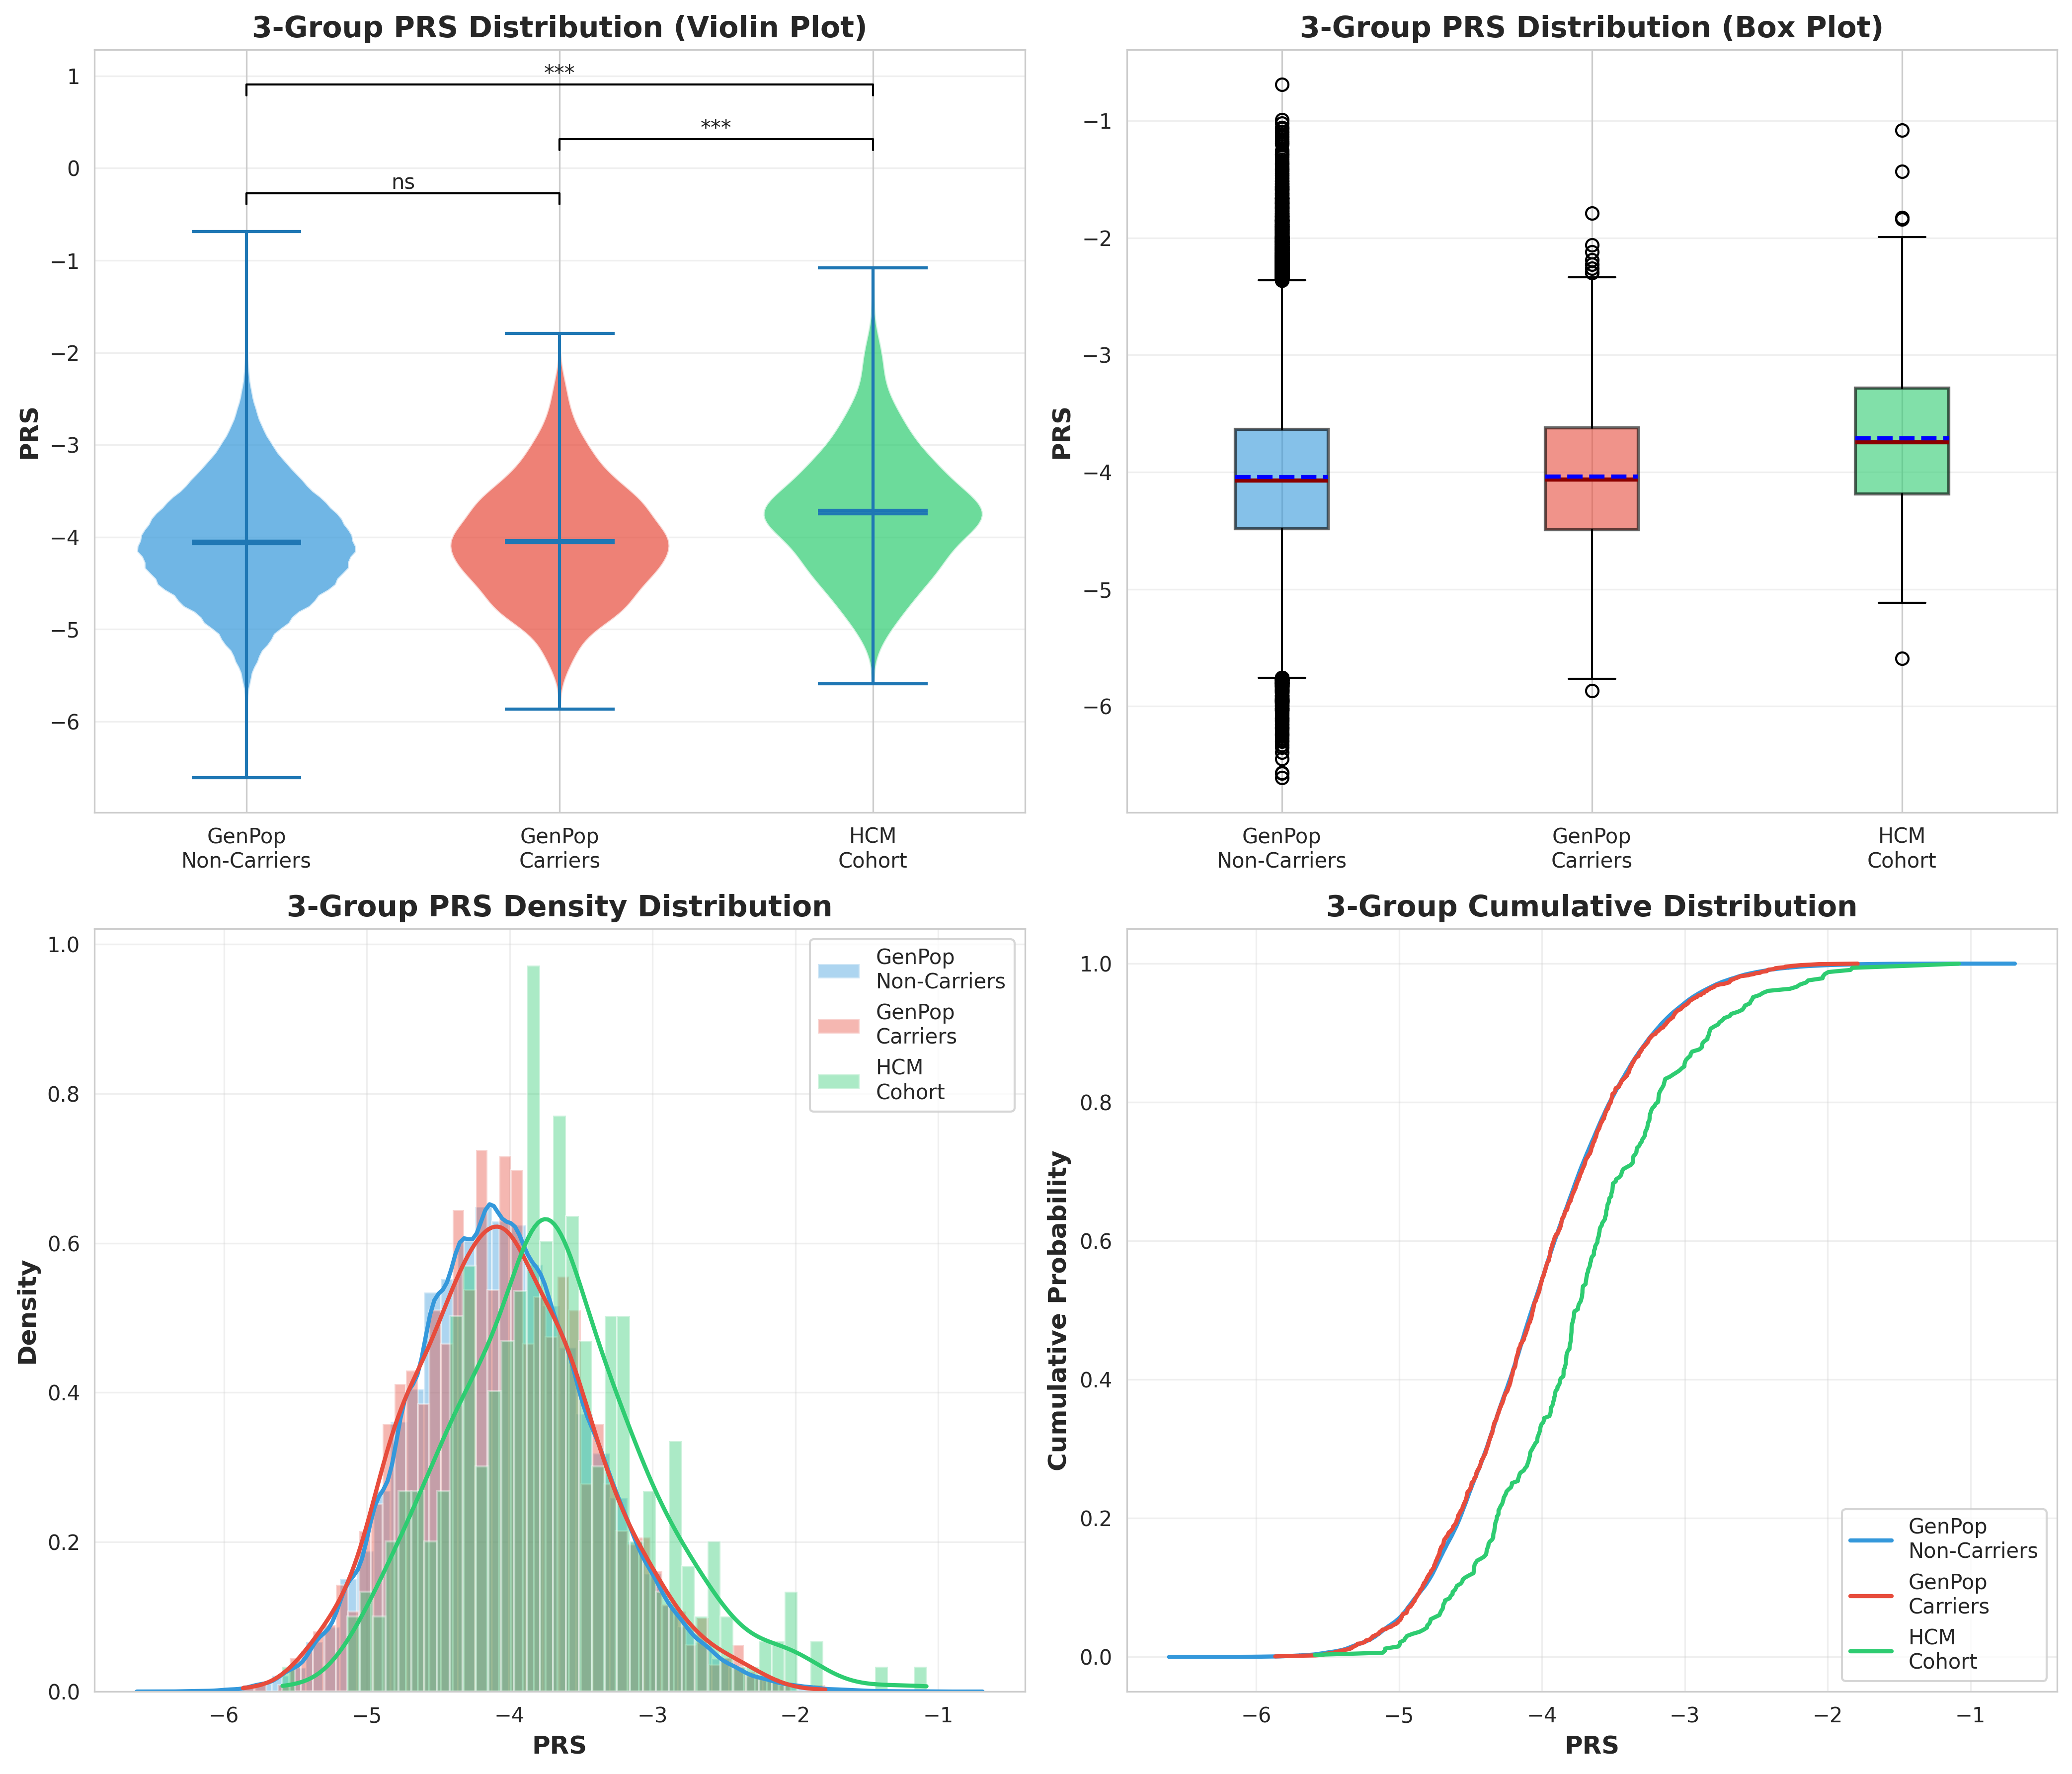

4-GROUP ANALYSIS

Summary Statistics:
                           N    Mean  Median     Std     Min     Max     Q25  \
Group                                                                          
GenPop\nCarriers        1370 -4.0384 -4.0623  0.6370 -5.8666 -1.7895 -4.4915   
GenPop\nNon-Carriers  248404 -4.0425 -4.0709  0.6339 -6.6096 -0.6894 -4.4832   
HCM\nCarriers             46 -3.6669 -3.6625  0.6887 -4.9949 -2.0315 -4.1511   
HCM\nNon-Carriers        285 -3.7166 -3.7751  0.6953 -5.5899 -1.0817 -4.2095   

                         Q75  
Group                         
GenPop\nCarriers     -3.6211  
GenPop\nNon-Carriers -3.6345  
HCM\nCarriers        -3.2987  
HCM\nNon-Carriers    -3.2781  

Pairwise Mann-Whitney U Tests:
             Group 1           Group 2     N1   N2     Mean1     Mean2   Median1   Median2  U-statistic      p-value Significant
GenPop\nNon-Carriers  GenPop\nCarriers 248404 1370 -4.042461 -4.038386 -4.070940 -4.062336  169741594.0 8.760465e-01          ns
GenPo

/var/tmp/ipykernel_9836/2273012681.py:249: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(box_data_4, labels=groups_4, patch_artist=True,



 4-group plot saved: prs_4group_analysis.png


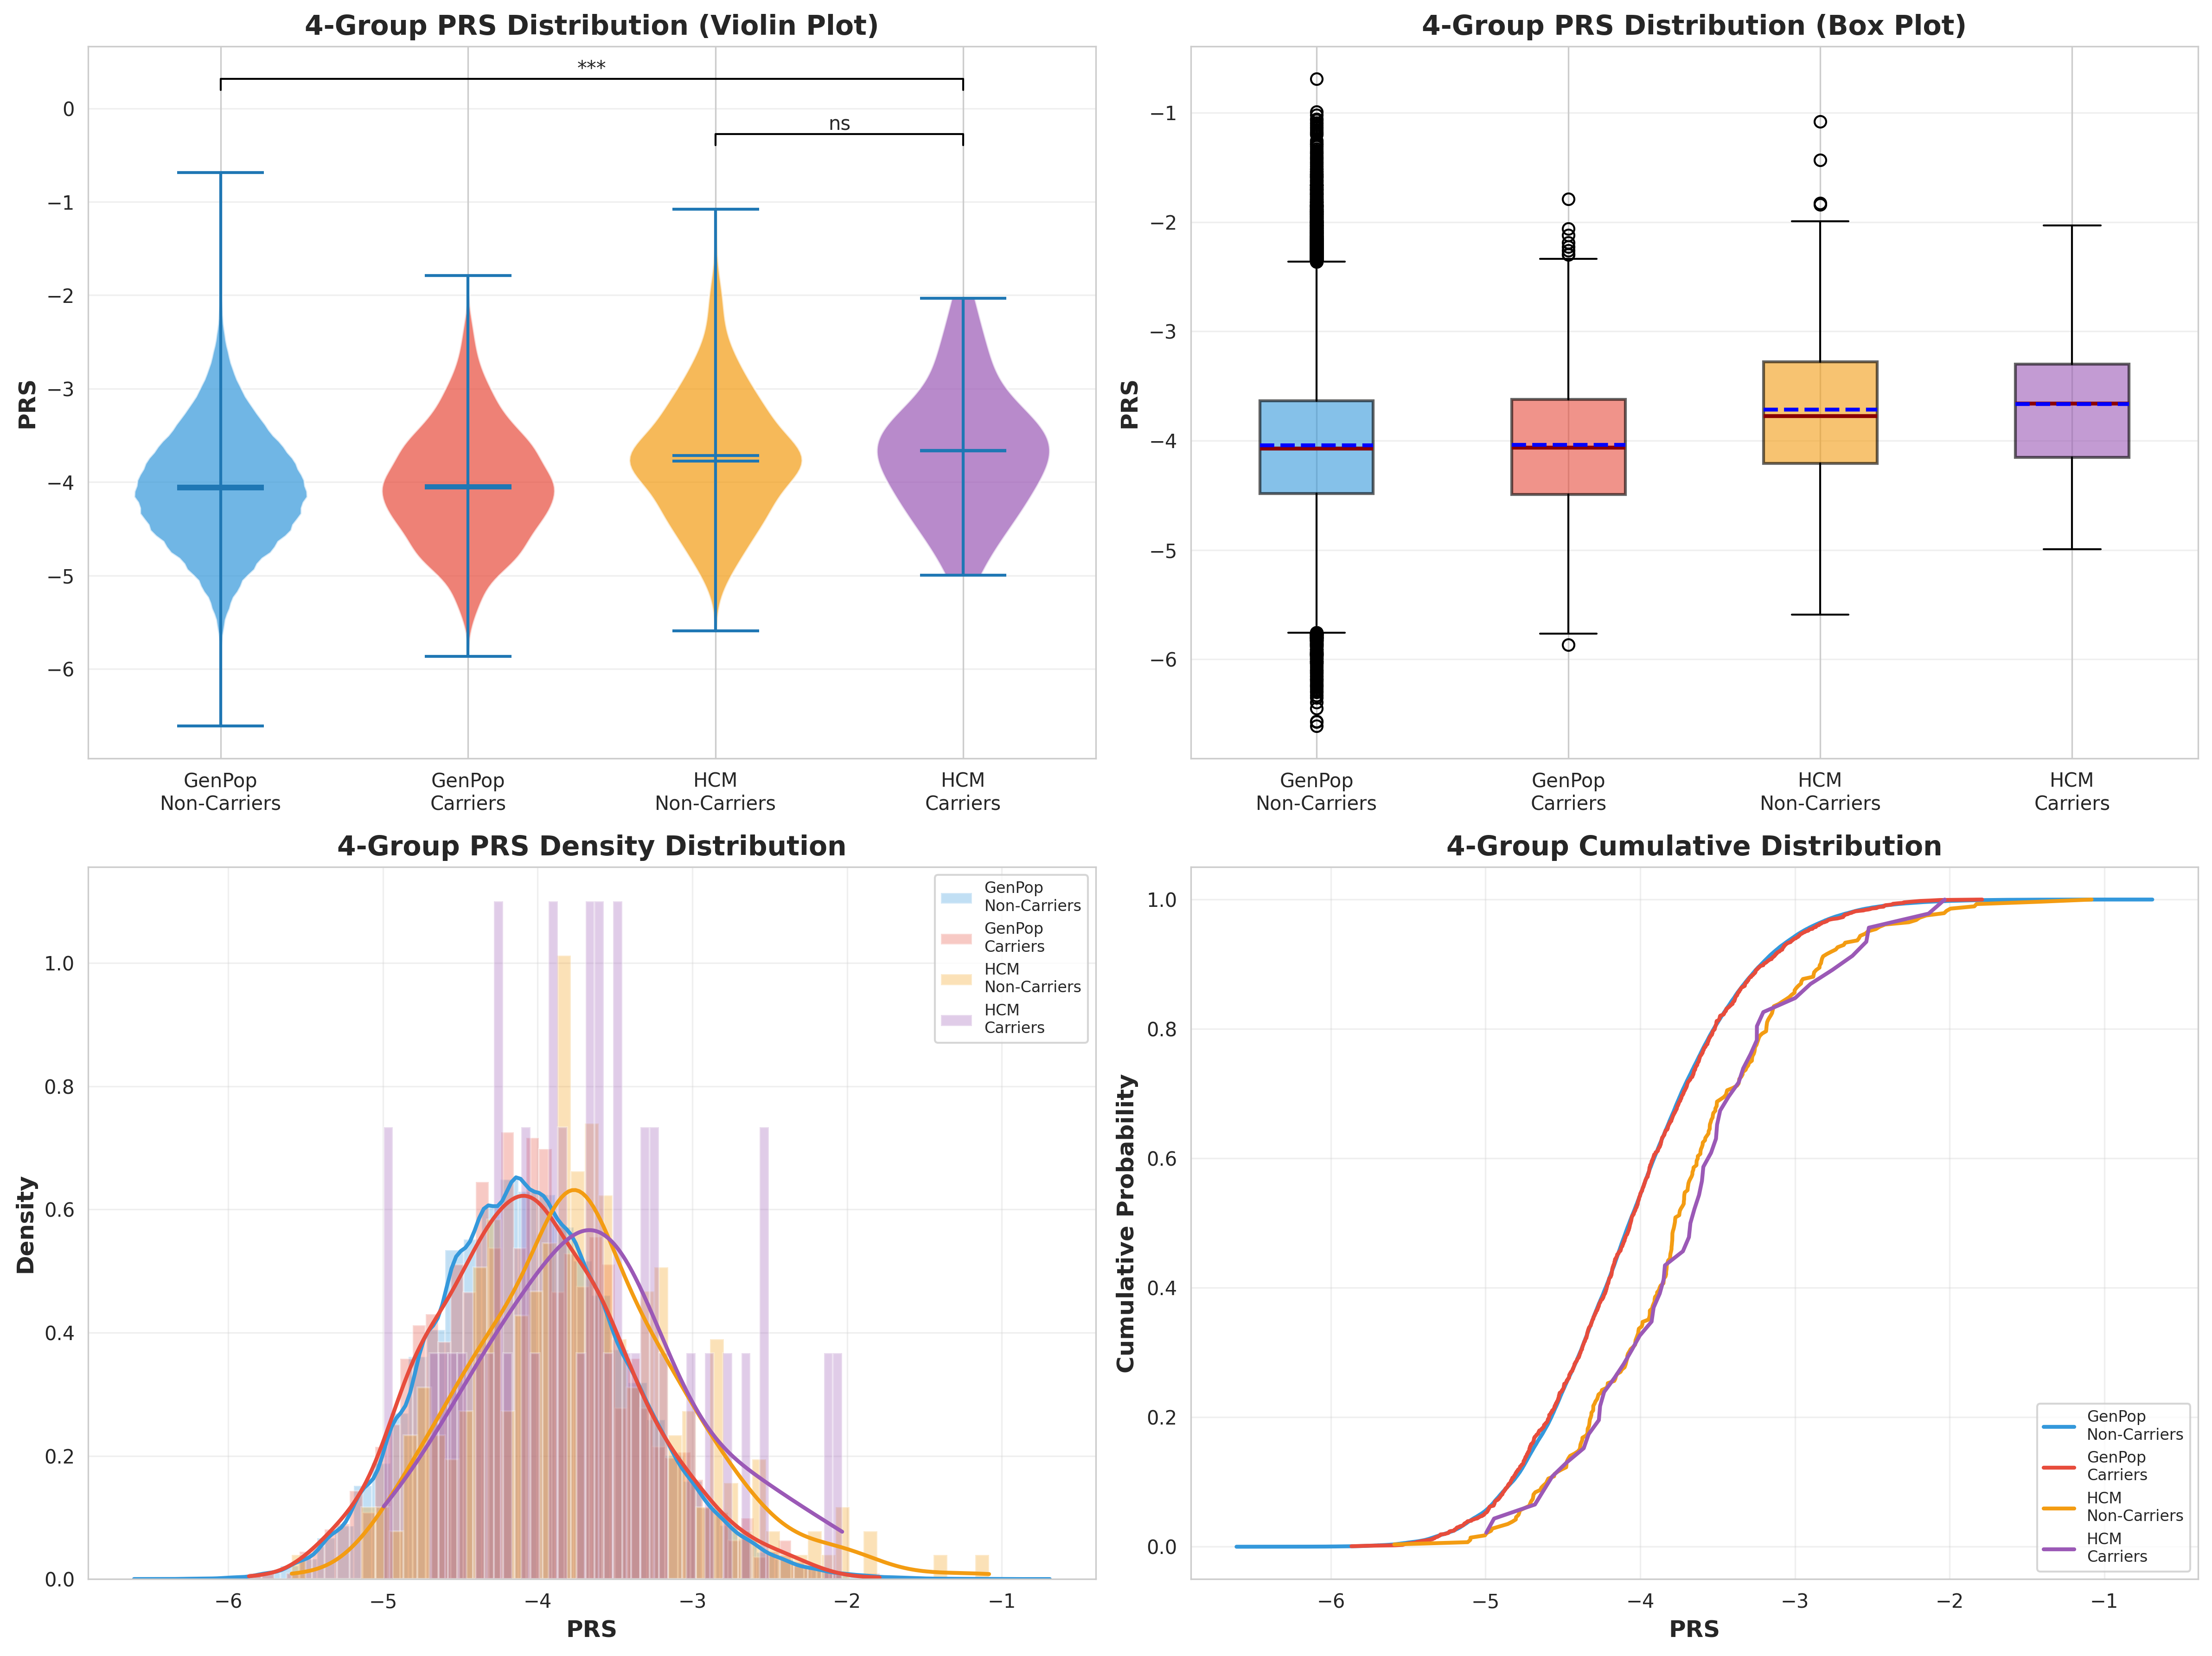


 3-group statistics saved:
  - prs_3group_summary_stats.csv
  - prs_3group_pairwise_tests.csv

 4-group statistics saved:
  - prs_4group_summary_stats.csv
  - prs_4group_pairwise_tests.csv


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from scipy.stats import mannwhitneyu, kruskal
import pandas as pd

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 10

def calculate_statistics(data, groups):
    """Calculate summary statistics for each group"""
    stats_df = data.groupby('Group')['PRS'].agg([
        ('N', 'count'),
        ('Mean', 'mean'),
        ('Median', 'median'),
        ('Std', 'std'),
        ('Min', 'min'),
        ('Max', 'max'),
        ('Q25', lambda x: np.percentile(x, 25)),
        ('Q75', lambda x: np.percentile(x, 75))
    ]).round(4)
    
    return stats_df

def perform_pairwise_tests(data, groups):
    """Perform pairwise Mann-Whitney U tests"""
    results = []
    
    for i in range(len(groups)):
        for j in range(i+1, len(groups)):
            group1 = groups[i]
            group2 = groups[j]
            
            prs1 = data[data['Group'] == group1]['PRS'].values
            prs2 = data[data['Group'] == group2]['PRS'].values
            
            statistic, pvalue = mannwhitneyu(prs1, prs2, alternative='two-sided')
            
            results.append({
                'Group 1': group1,
                'Group 2': group2,
                'N1': len(prs1),
                'N2': len(prs2),
                'Mean1': np.mean(prs1),
                'Mean2': np.mean(prs2),
                'Median1': np.median(prs1),
                'Median2': np.median(prs2),
                'U-statistic': statistic,
                'p-value': pvalue,
                'Significant': '***' if pvalue < 0.001 else '**' if pvalue < 0.01 else '*' if pvalue < 0.05 else 'ns'
            })
    
    return pd.DataFrame(results)

def add_pvalue_annotation(ax, x1, x2, y, pvalue, height=0.02):
    """Add p-value annotation between two groups"""
    if pvalue < 0.001:
        text = '***'
    elif pvalue < 0.01:
        text = '**'
    elif pvalue < 0.05:
        text = '*'
    else:
        text = 'ns'
    
    ax.plot([x1, x1, x2, x2], [y, y+height, y+height, y], 'k-', lw=1)
    ax.text((x1+x2)/2, y+height, text, ha='center', va='bottom', fontsize=10)

print("3-GROUP ANALYSIS")

groups_3 = ['GenPop\nNon-Carriers', 'GenPop\nCarriers', 'HCM\nCohort']

# Summary statistics
print("\nSummary Statistics:")
stats_3group = calculate_statistics(prs_data_3group, groups_3)
print(stats_3group)

# Pairwise tests
print("\nPairwise Mann-Whitney U Tests:")
pairwise_3group = perform_pairwise_tests(prs_data_3group, groups_3)
print(pairwise_3group.to_string(index=False))

# Kruskal-Wallis test
group_arrays_3 = [prs_data_3group[prs_data_3group['Group'] == g]['PRS'].values for g in groups_3]
h_stat_3, p_kruskal_3 = kruskal(*group_arrays_3)
print(f"\nKruskal-Wallis H-test: H={h_stat_3:.4f}, p={p_kruskal_3:.4e}")

# 3-GROUP PLOTS
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Violin plot
ax1 = axes[0, 0]
parts = ax1.violinplot(
    [prs_data_3group[prs_data_3group['Group'] == g]['PRS'].values for g in groups_3],
    positions=range(len(groups_3)),
    showmeans=True,
    showmedians=True,
    widths=0.7
)

colors_3 = ['#3498db', '#e74c3c', '#2ecc71']
for pc, color in zip(parts['bodies'], colors_3):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

ax1.set_xticks(range(len(groups_3)))
ax1.set_xticklabels(groups_3)
ax1.set_ylabel('PRS', fontsize=12, fontweight='bold')
ax1.set_title('3-Group PRS Distribution (Violin Plot)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

y_max = prs_data_3group['PRS'].max()
y_range = prs_data_3group['PRS'].max() - prs_data_3group['PRS'].min()

# GenPop NC vs GenPop C
pval = pairwise_3group[(pairwise_3group['Group 1'] == groups_3[0]) & 
                        (pairwise_3group['Group 2'] == groups_3[1])]['p-value'].values[0]
add_pvalue_annotation(ax1, 0, 1, y_max + 0.05*y_range, pval, height=0.02*y_range)

# GenPop C vs HCM
pval = pairwise_3group[(pairwise_3group['Group 1'] == groups_3[1]) & 
                        (pairwise_3group['Group 2'] == groups_3[2])]['p-value'].values[0]
add_pvalue_annotation(ax1, 1, 2, y_max + 0.15*y_range, pval, height=0.02*y_range)

# GenPop NC vs HCM
pval = pairwise_3group[(pairwise_3group['Group 1'] == groups_3[0]) & 
                        (pairwise_3group['Group 2'] == groups_3[2])]['p-value'].values[0]
add_pvalue_annotation(ax1, 0, 2, y_max + 0.25*y_range, pval, height=0.02*y_range)

# Plot 2: Box plot
ax2 = axes[0, 1]
box_data_3 = [prs_data_3group[prs_data_3group['Group'] == g]['PRS'].values for g in groups_3]
bp = ax2.boxplot(box_data_3, labels=groups_3, patch_artist=True, 
                  showmeans=True, meanline=True,
                  boxprops=dict(linewidth=1.5),
                  medianprops=dict(linewidth=2, color='darkred'),
                  meanprops=dict(linewidth=2, color='blue', linestyle='--'))

for patch, color in zip(bp['boxes'], colors_3):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax2.set_ylabel('PRS', fontsize=12, fontweight='bold')
ax2.set_title('3-Group PRS Distribution (Box Plot)', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Density plot
ax3 = axes[1, 0]
for group, color in zip(groups_3, colors_3):
    data = prs_data_3group[prs_data_3group['Group'] == group]['PRS']
    ax3.hist(data, bins=50, alpha=0.4, color=color, label=group, density=True)
    
    # Add KDE
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 200)
    ax3.plot(x_range, kde(x_range), color=color, linewidth=2)

ax3.set_xlabel('PRS', fontsize=12, fontweight='bold')
ax3.set_ylabel('Density', fontsize=12, fontweight='bold')
ax3.set_title('3-Group PRS Density Distribution', fontsize=14, fontweight='bold')
ax3.legend(loc='upper right')
ax3.grid(alpha=0.3)

# Plot 4: Cumulative distribution
ax4 = axes[1, 1]
for group, color in zip(groups_3, colors_3):
    data = prs_data_3group[prs_data_3group['Group'] == group]['PRS']
    sorted_data = np.sort(data)
    cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax4.plot(sorted_data, cumulative, color=color, linewidth=2, label=group)

ax4.set_xlabel('PRS', fontsize=12, fontweight='bold')
ax4.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax4.set_title('3-Group Cumulative Distribution', fontsize=14, fontweight='bold')
ax4.legend(loc='lower right')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('prs_3group_analysis.png', dpi=300, bbox_inches='tight')
print("\n 3-group plot saved: prs_3group_analysis.png")
plt.show()

print("4-GROUP ANALYSIS")

groups_4 = ['GenPop\nNon-Carriers', 'GenPop\nCarriers', 'HCM\nNon-Carriers', 'HCM\nCarriers']

# Summary statistics
print("\nSummary Statistics:")
stats_4group = calculate_statistics(prs_data_4group, groups_4)
print(stats_4group)

# Pairwise tests
print("\nPairwise Mann-Whitney U Tests:")
pairwise_4group = perform_pairwise_tests(prs_data_4group, groups_4)
print(pairwise_4group.to_string(index=False))

# Kruskal-Wallis test
group_arrays_4 = [prs_data_4group[prs_data_4group['Group'] == g]['PRS'].values for g in groups_4]
h_stat_4, p_kruskal_4 = kruskal(*group_arrays_4)
print(f"\nKruskal-Wallis H-test: H={h_stat_4:.4f}, p={p_kruskal_4:.4e}")

# 4-GROUP PLOTS

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Violin plot
ax1 = axes[0, 0]
parts = ax1.violinplot(
    [prs_data_4group[prs_data_4group['Group'] == g]['PRS'].values for g in groups_4],
    positions=range(len(groups_4)),
    showmeans=True,
    showmedians=True,
    widths=0.7
)

# Color the violin plots
colors_4 = ['#3498db', '#e74c3c', '#f39c12', '#9b59b6']
for pc, color in zip(parts['bodies'], colors_4):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

ax1.set_xticks(range(len(groups_4)))
ax1.set_xticklabels(groups_4, rotation=0)
ax1.set_ylabel('PRS', fontsize=12, fontweight='bold')
ax1.set_title('4-Group PRS Distribution (Violin Plot)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add key p-value annotations 
y_max = prs_data_4group['PRS'].max()
y_range = prs_data_4group['PRS'].max() - prs_data_4group['PRS'].min()

# HCM NC vs HCM C
pval = pairwise_4group[(pairwise_4group['Group 1'] == groups_4[2]) & 
                        (pairwise_4group['Group 2'] == groups_4[3])]['p-value'].values[0]
add_pvalue_annotation(ax1, 2, 3, y_max + 0.05*y_range, pval, height=0.02*y_range)

# GenPop NC vs HCM C
pval = pairwise_4group[(pairwise_4group['Group 1'] == groups_4[0]) & 
                        (pairwise_4group['Group 2'] == groups_4[3])]['p-value'].values[0]
add_pvalue_annotation(ax1, 0, 3, y_max + 0.15*y_range, pval, height=0.02*y_range)

# Plot 2: Box plot
ax2 = axes[0, 1]
box_data_4 = [prs_data_4group[prs_data_4group['Group'] == g]['PRS'].values for g in groups_4]
bp = ax2.boxplot(box_data_4, labels=groups_4, patch_artist=True, 
                  showmeans=True, meanline=True,
                  boxprops=dict(linewidth=1.5),
                  medianprops=dict(linewidth=2, color='darkred'),
                  meanprops=dict(linewidth=2, color='blue', linestyle='--'))

for patch, color in zip(bp['boxes'], colors_4):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax2.set_ylabel('PRS', fontsize=12, fontweight='bold')
ax2.set_title('4-Group PRS Distribution (Box Plot)', fontsize=14, fontweight='bold')
ax2.set_xticklabels(groups_4, rotation=0)
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Density plot
ax3 = axes[1, 0]
for group, color in zip(groups_4, colors_4):
    data = prs_data_4group[prs_data_4group['Group'] == group]['PRS']
    ax3.hist(data, bins=50, alpha=0.3, color=color, label=group, density=True)
    
    # Add KDE
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 200)
    ax3.plot(x_range, kde(x_range), color=color, linewidth=2)

ax3.set_xlabel('PRS', fontsize=12, fontweight='bold')
ax3.set_ylabel('Density', fontsize=12, fontweight='bold')
ax3.set_title('4-Group PRS Density Distribution', fontsize=14, fontweight='bold')
ax3.legend(loc='upper right', fontsize=8)
ax3.grid(alpha=0.3)

# Plot 4: Cumulative distribution
ax4 = axes[1, 1]
for group, color in zip(groups_4, colors_4):
    data = prs_data_4group[prs_data_4group['Group'] == group]['PRS']
    sorted_data = np.sort(data)
    cumulative = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax4.plot(sorted_data, cumulative, color=color, linewidth=2, label=group)

ax4.set_xlabel('PRS', fontsize=12, fontweight='bold')
ax4.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax4.set_title('4-Group Cumulative Distribution', fontsize=14, fontweight='bold')
ax4.legend(loc='lower right', fontsize=8)
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('prs_4group_analysis.png', dpi=300, bbox_inches='tight')
print("\n 4-group plot saved: prs_4group_analysis.png")
plt.show()

# Save 3-group statistics
stats_3group.to_csv('prs_3group_summary_stats.csv')
pairwise_3group.to_csv('prs_3group_pairwise_tests.csv', index=False)
print("\n 3-group statistics saved:")
print("  - prs_3group_summary_stats.csv")
print("  - prs_3group_pairwise_tests.csv")

# Save 4-group statistics
stats_4group.to_csv('prs_4group_summary_stats.csv')
pairwise_4group.to_csv('prs_4group_pairwise_tests.csv', index=False)
print("\n 4-group statistics saved:")
print("  - prs_4group_summary_stats.csv")
print("  - prs_4group_pairwise_tests.csv")


EFFECT SIZE AND ODDS RATIO ANALYSIS
PART 1: PRIMARY COMPARISON - HCM CARRIERS vs GENPOP CARRIERS

Sample sizes:
  HCM Carriers:         46
  GenPop Carriers:      1,370

Descriptive Statistics:
  HCM Carriers:         Mean=-3.6669, SD=0.6887, Median=-3.6625
  GenPop Carriers:      Mean=-4.0384, SD=0.6370, Median=-4.0623
  Difference in means:  0.3715

Statistical Tests:
  Mann-Whitney U: U=41221.00, p=3.713402e-04
  t-test:         t=3.880, p=1.091428e-04

Effect Size (Cohen's d):
  d = 0.5816 [95% CI: 0.2871, 0.8762]
  Interpretation: MEDIUM effect size
ODDS RATIO CALCULATIONS

Method 1: Split at GenPop Carriers Median
  Threshold: -4.0623

  2x2 Table:
                  High PRS    Low PRS
  HCM Carriers          33         13
  GenPop Carriers      685        685

  OR = 2.538 [95% CI: 1.325, 4.865]
  Fisher's exact p = 4.085982e-03
  Interpretation: 2.54x higher odds of HCM for high PRS carriers

Method 2: Top vs Bottom Quartile (Q4 vs Q1)
  Q1 (25th percentile): -4.4759
  Q3 (75th

/var/tmp/ipykernel_9836/2324024666.py:386: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax5.boxplot([prs_genpop_nc, prs_genpop_c, prs_hcm_nc, prs_hcm_c],



Saved figure: 'prs_effect_size_odds_ratio_comprehensive.png'
PART 4: SAVING RESULTS
 Saved: 'prs_effect_size_primary_comparison.csv'
 Saved: 'prs_pairwise_comparisons_4groups.csv'
 Saved: 'prs_summary_statistics_4groups.csv'
ANALYSIS COMPLETE!

KEY FINDINGS:
  Cohen's d = 0.582 (medium effect)
  OR (median split) = 2.54
  ROC-AUC = 0.654 (poor discrimination)
  p-value = 3.71e-04

Interpretation:
  HCM carriers have 0.58 SD higher PRS than GenPop carriers
  Carriers with PRS > median have 2.5x odds of developing HCM


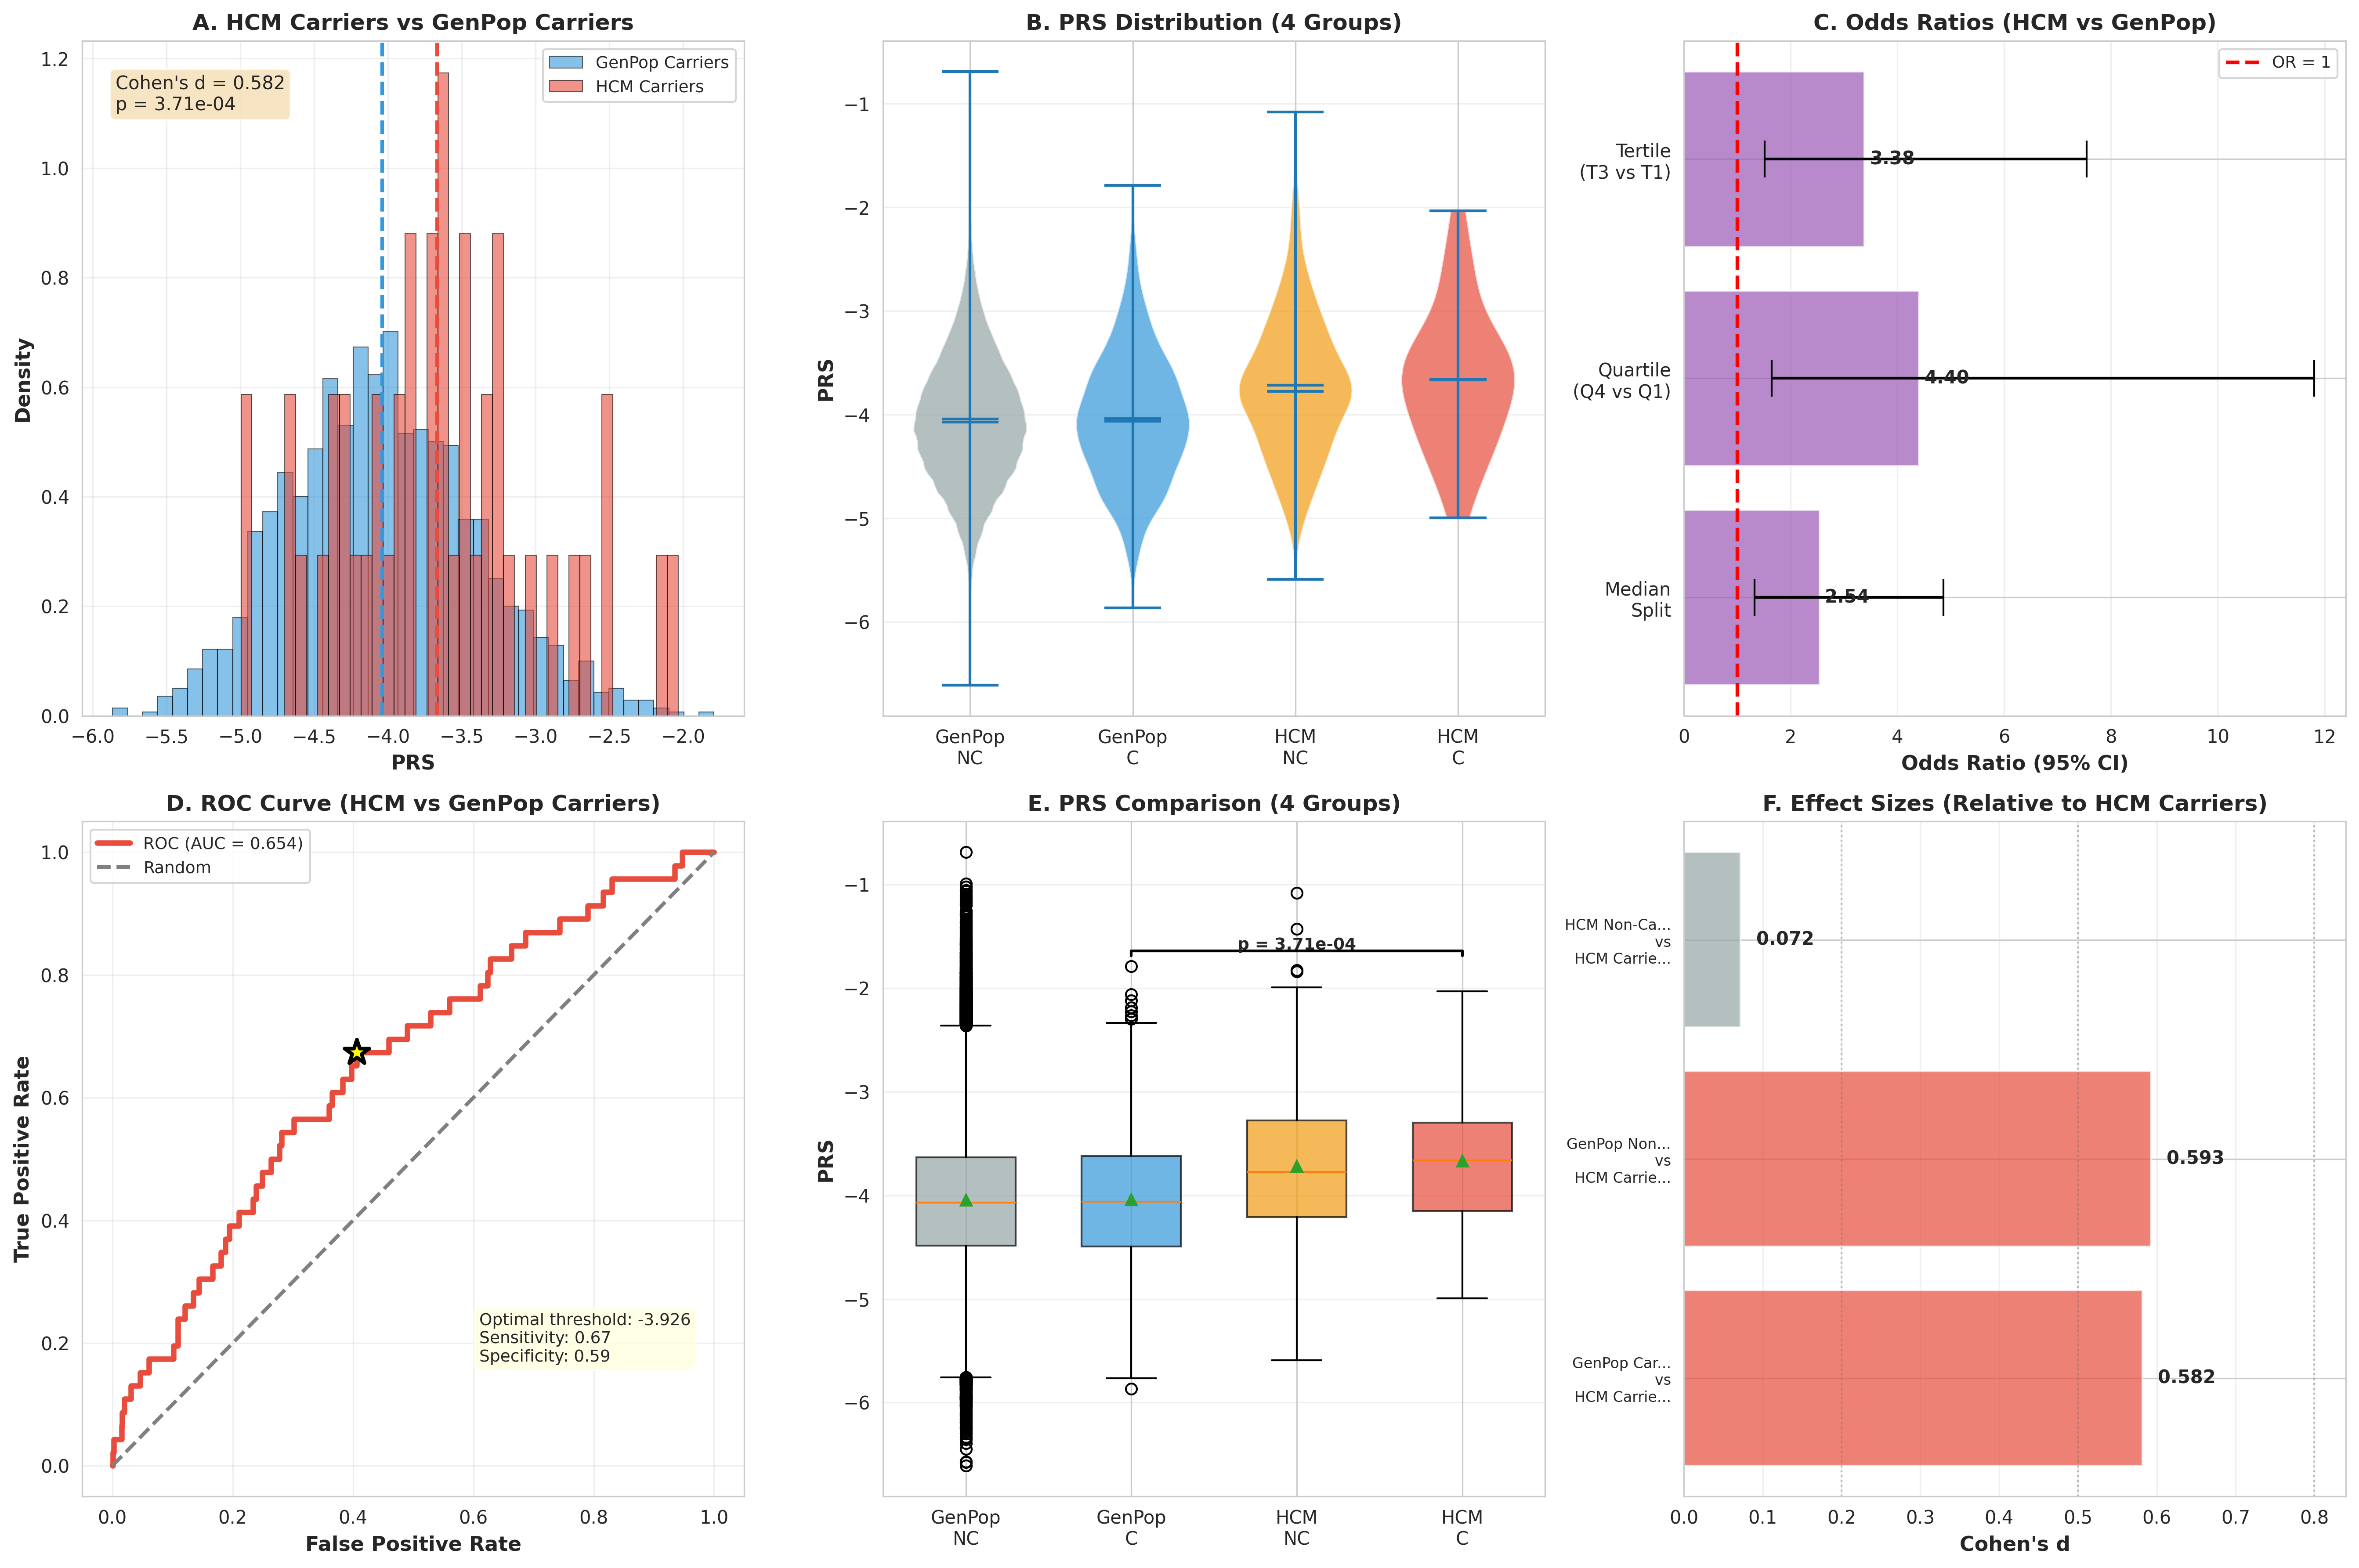

In [12]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import fisher_exact
import matplotlib.pyplot as plt
import seaborn as sns

print("EFFECT SIZE AND ODDS RATIO ANALYSIS")

print("PART 1: PRIMARY COMPARISON - HCM CARRIERS vs GENPOP CARRIERS")

# Extract the two groups for primary comparison
hcm_carriers_prs = prs_hcm_c  
genpop_carriers_prs = prs_genpop_c 

n_hcm_c = len(hcm_carriers_prs)
n_genpop_c = len(genpop_carriers_prs)

print(f"\nSample sizes:")
print(f"  HCM Carriers:         {n_hcm_c:,}")
print(f"  GenPop Carriers:      {n_genpop_c:,}")

# Descriptive statistics
hcm_c_mean = np.mean(hcm_carriers_prs)
hcm_c_sd = np.std(hcm_carriers_prs, ddof=1)
hcm_c_median = np.median(hcm_carriers_prs)

genpop_c_mean = np.mean(genpop_carriers_prs)
genpop_c_sd = np.std(genpop_carriers_prs, ddof=1)
genpop_c_median = np.median(genpop_carriers_prs)

print(f"\nDescriptive Statistics:")
print(f"  HCM Carriers:         Mean={hcm_c_mean:.4f}, SD={hcm_c_sd:.4f}, Median={hcm_c_median:.4f}")
print(f"  GenPop Carriers:      Mean={genpop_c_mean:.4f}, SD={genpop_c_sd:.4f}, Median={genpop_c_median:.4f}")
print(f"  Difference in means:  {hcm_c_mean - genpop_c_mean:.4f}")

# Statistical tests
u_stat, mannwhitney_p = stats.mannwhitneyu(hcm_carriers_prs, genpop_carriers_prs, alternative='two-sided')
t_stat, ttest_p = stats.ttest_ind(hcm_carriers_prs, genpop_carriers_prs)

print(f"\nStatistical Tests:")
print(f"  Mann-Whitney U: U={u_stat:.2f}, p={mannwhitney_p:.6e}")
print(f"  t-test:         t={t_stat:.3f}, p={ttest_p:.6e}")

# Effect Size: Cohen's d
pooled_sd = np.sqrt(((n_hcm_c - 1) * hcm_c_sd**2 + (n_genpop_c - 1) * genpop_c_sd**2) / 
                     (n_hcm_c + n_genpop_c - 2))
cohens_d = (hcm_c_mean - genpop_c_mean) / pooled_sd

# 95% CI for Cohen's d
se_d = np.sqrt((n_hcm_c + n_genpop_c) / (n_hcm_c * n_genpop_c) + 
               cohens_d**2 / (2 * (n_hcm_c + n_genpop_c)))
ci_lower = cohens_d - 1.96 * se_d
ci_upper = cohens_d + 1.96 * se_d

print(f"\nEffect Size (Cohen's d):")
print(f"  d = {cohens_d:.4f} [95% CI: {ci_lower:.4f}, {ci_upper:.4f}]")

if abs(cohens_d) < 0.2:
    interpretation = "negligible"
elif abs(cohens_d) < 0.5:
    interpretation = "small"
elif abs(cohens_d) < 0.8:
    interpretation = "medium"
else:
    interpretation = "large"
print(f"  Interpretation: {interpretation.upper()} effect size")

# Odds Ratios - Multiple Methods

print("ODDS RATIO CALCULATIONS")

# Method 1: Split at GenPop Carriers median
print("\nMethod 1: Split at GenPop Carriers Median")
threshold_1 = np.median(genpop_carriers_prs)
print(f"  Threshold: {threshold_1:.4f}")

hcm_high_1 = np.sum(hcm_carriers_prs > threshold_1)
hcm_low_1 = np.sum(hcm_carriers_prs <= threshold_1)
genpop_high_1 = np.sum(genpop_carriers_prs > threshold_1)
genpop_low_1 = np.sum(genpop_carriers_prs <= threshold_1)

print(f"\n  2x2 Table:")
print(f"                  High PRS    Low PRS")
print(f"  HCM Carriers    {hcm_high_1:>8}    {hcm_low_1:>7}")
print(f"  GenPop Carriers {genpop_high_1:>8}    {genpop_low_1:>7}")

if hcm_low_1 > 0 and genpop_high_1 > 0:
    or_1 = (hcm_high_1 * genpop_low_1) / (hcm_low_1 * genpop_high_1)
    se_log_or_1 = np.sqrt(1/hcm_high_1 + 1/hcm_low_1 + 1/genpop_high_1 + 1/genpop_low_1)
    or_ci_lower_1 = np.exp(np.log(or_1) - 1.96 * se_log_or_1)
    or_ci_upper_1 = np.exp(np.log(or_1) + 1.96 * se_log_or_1)
    
    fisher_or_1, fisher_p_1 = fisher_exact([[hcm_high_1, hcm_low_1], 
                                             [genpop_high_1, genpop_low_1]])
    
    print(f"\n  OR = {or_1:.3f} [95% CI: {or_ci_lower_1:.3f}, {or_ci_upper_1:.3f}]")
    print(f"  Fisher's exact p = {fisher_p_1:.6e}")
    print(f"  Interpretation: {or_1:.2f}x higher odds of HCM for high PRS carriers")
else:
    print("  Cannot calculate - zero cells in contingency table")
    or_1 = np.nan

# Method 2: Quartile analysis (Q4 vs Q1)
print("\nMethod 2: Top vs Bottom Quartile (Q4 vs Q1)")
combined_prs = np.concatenate([hcm_carriers_prs, genpop_carriers_prs])
q1_threshold = np.percentile(combined_prs, 25)
q3_threshold = np.percentile(combined_prs, 75)
print(f"  Q1 (25th percentile): {q1_threshold:.4f}")
print(f"  Q3 (75th percentile): {q3_threshold:.4f}")

hcm_q4 = np.sum(hcm_carriers_prs > q3_threshold)
hcm_q1 = np.sum(hcm_carriers_prs < q1_threshold)
genpop_q4 = np.sum(genpop_carriers_prs > q3_threshold)
genpop_q1 = np.sum(genpop_carriers_prs < q1_threshold)

print(f"\n  2x2 Table:")
print(f"                  Q4 (High)   Q1 (Low)")
print(f"  HCM Carriers    {hcm_q4:>9}   {hcm_q1:>8}")
print(f"  GenPop Carriers {genpop_q4:>9}   {genpop_q1:>8}")

if hcm_q1 > 0 and genpop_q4 > 0:
    or_2 = (hcm_q4 * genpop_q1) / (hcm_q1 * genpop_q4)
    se_log_or_2 = np.sqrt(1/hcm_q4 + 1/hcm_q1 + 1/genpop_q4 + 1/genpop_q1)
    or_ci_lower_2 = np.exp(np.log(or_2) - 1.96 * se_log_or_2)
    or_ci_upper_2 = np.exp(np.log(or_2) + 1.96 * se_log_or_2)
    
    fisher_or_2, fisher_p_2 = fisher_exact([[hcm_q4, hcm_q1], [genpop_q4, genpop_q1]])
    
    print(f"\n  OR = {or_2:.3f} [95% CI: {or_ci_lower_2:.3f}, {or_ci_upper_2:.3f}]")
    print(f"  Fisher's exact p = {fisher_p_2:.6e}")
else:
    print("  Cannot calculate - zero cells in contingency table")
    or_2 = np.nan

# Method 3: Tertile analysis (T3 vs T1)
print("\nMethod 3: Top vs Bottom Tertile (T3 vs T1)")
t1_threshold = np.percentile(combined_prs, 33.33)
t3_threshold = np.percentile(combined_prs, 66.67)
print(f"  T1 (33rd percentile): {t1_threshold:.4f}")
print(f"  T3 (67th percentile): {t3_threshold:.4f}")

hcm_t3 = np.sum(hcm_carriers_prs > t3_threshold)
hcm_t1 = np.sum(hcm_carriers_prs < t1_threshold)
genpop_t3 = np.sum(genpop_carriers_prs > t3_threshold)
genpop_t1 = np.sum(genpop_carriers_prs < t1_threshold)

print(f"\n  2x2 Table:")
print(f"                  T3 (High)   T1 (Low)")
print(f"  HCM Carriers    {hcm_t3:>9}   {hcm_t1:>8}")
print(f"  GenPop Carriers {genpop_t3:>9}   {genpop_t1:>8}")

if hcm_t1 > 0 and genpop_t3 > 0:
    or_3 = (hcm_t3 * genpop_t1) / (hcm_t1 * genpop_t3)
    se_log_or_3 = np.sqrt(1/hcm_t3 + 1/hcm_t1 + 1/genpop_t3 + 1/genpop_t1)
    or_ci_lower_3 = np.exp(np.log(or_3) - 1.96 * se_log_or_3)
    or_ci_upper_3 = np.exp(np.log(or_3) + 1.96 * se_log_or_3)
    
    fisher_or_3, fisher_p_3 = fisher_exact([[hcm_t3, hcm_t1], [genpop_t3, genpop_t1]])
    
    print(f"\n  OR = {or_3:.3f} [95% CI: {or_ci_lower_3:.3f}, {or_ci_upper_3:.3f}]")
    print(f"  Fisher's exact p = {fisher_p_3:.6e}")
else:
    print("  Cannot calculate - zero cells in contingency table")
    or_3 = np.nan

# ROC-AUC Analysis
print("ROC-AUC ANALYSIS")

from sklearn.metrics import roc_curve, auc, roc_auc_score

y_true = np.concatenate([np.ones(n_hcm_c), np.zeros(n_genpop_c)])
y_score = np.concatenate([hcm_carriers_prs, genpop_carriers_prs])

fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# 95% CI for AUC (DeLong approximation)
auc_se = np.sqrt((roc_auc * (1 - roc_auc) + 
                  (n_hcm_c - 1) * (roc_auc / (2 - roc_auc) - roc_auc**2) + 
                  (n_genpop_c - 1) * (2 * roc_auc**2 / (1 + roc_auc) - roc_auc**2)) / 
                 (n_hcm_c * n_genpop_c))
auc_ci_lower = max(0, roc_auc - 1.96 * auc_se)
auc_ci_upper = min(1, roc_auc + 1.96 * auc_se)

print(f"\nROC-AUC = {roc_auc:.4f} [95% CI: {auc_ci_lower:.4f}, {auc_ci_upper:.4f}]")

if roc_auc >= 0.9:
    auc_interp = "excellent"
elif roc_auc >= 0.8:
    auc_interp = "good"
elif roc_auc >= 0.7:
    auc_interp = "fair"
elif roc_auc >= 0.6:
    auc_interp = "poor"
else:
    auc_interp = "no discrimination"
print(f"Interpretation: {auc_interp.upper()} discrimination")

# Optimal threshold (Youden's J)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
optimal_sensitivity = tpr[optimal_idx]
optimal_specificity = 1 - fpr[optimal_idx]

print(f"\nOptimal PRS threshold: {optimal_threshold:.4f}")
print(f"  Sensitivity: {optimal_sensitivity:.3f}")
print(f"  Specificity: {optimal_specificity:.3f}")
print(f"  Youden's J: {optimal_sensitivity + optimal_specificity - 1:.3f}")

print("PART 2: EXTENDED COMPARISONS (4-GROUP ANALYSIS)")

# All four groups from your previous code
groups_4 = {
    'HCM Carriers': prs_hcm_c,
    'HCM Non-Carriers': prs_hcm_nc,
    'GenPop Carriers': prs_genpop_c,
    'GenPop Non-Carriers': prs_genpop_nc
}

print("\nDescriptive Statistics (All 4 Groups):")
print(f"{'Group':<25} {'n':>8} {'Mean':>10} {'SD':>10} {'Median':>10}")
print("-"*70)
for name, data in groups_4.items():
    print(f"{name:<25} {len(data):>8,} {np.mean(data):>10.4f} {np.std(data, ddof=1):>10.4f} {np.median(data):>10.4f}")

# Pairwise comparisons
print("PAIRWISE COMPARISONS (Mann-Whitney U tests)")

comparisons = [
    ('HCM Carriers', 'HCM Non-Carriers'),
    ('HCM Carriers', 'GenPop Carriers'),
    ('HCM Carriers', 'GenPop Non-Carriers'),
    ('HCM Non-Carriers', 'GenPop Carriers'),
    ('HCM Non-Carriers', 'GenPop Non-Carriers'),
    ('GenPop Carriers', 'GenPop Non-Carriers')
]

pairwise_results = []
for group1, group2 in comparisons:
    data1 = groups_4[group1]
    data2 = groups_4[group2]
    
    u, p = stats.mannwhitneyu(data1, data2, alternative='two-sided')
    
    # Cohen's d
    mean1, mean2 = np.mean(data1), np.mean(data2)
    sd1, sd2 = np.std(data1, ddof=1), np.std(data2, ddof=1)
    n1, n2 = len(data1), len(data2)
    pooled_sd_pair = np.sqrt(((n1 - 1) * sd1**2 + (n2 - 1) * sd2**2) / (n1 + n2 - 2))
    d = (mean1 - mean2) / pooled_sd_pair
    
    pairwise_results.append({
        'Comparison': f"{group1} vs {group2}",
        'Mean_Diff': mean1 - mean2,
        'Cohens_d': d,
        'U_statistic': u,
        'p_value': p
    })
    
    print(f"\n{group1} vs {group2}")
    print(f"  Mean difference: {mean1 - mean2:.4f}")
    print(f"  Cohen's d: {d:.4f}")
    print(f"  Mann-Whitney U: {u:.2f}, p = {p:.6e}")
    if p < 0.001:
        print(f"  *** Highly significant")
    elif p < 0.05:
        print(f"  ** Significant")

# Kruskal-Wallis test for all 4 groups
print("OVERALL TEST (4 GROUPS)")

h_stat, kruskal_p = stats.kruskal(prs_hcm_c, prs_hcm_nc, prs_genpop_c, prs_genpop_nc)
print(f"\nKruskal-Wallis H test:")
print(f"  H = {h_stat:.3f}, p = {kruskal_p:.6e}")
if kruskal_p < 0.001:
    print(f"  *** Highly significant differences between groups")

print("PART 3: CREATING VISUALIZATIONS")

# Create comprehensive figure
fig = plt.figure(figsize=(18, 12))

# Panel A: Distribution comparison (HCM Carriers vs GenPop Carriers)
ax1 = plt.subplot(2, 3, 1)
ax1.hist(genpop_carriers_prs, bins=40, alpha=0.6, label='GenPop Carriers', 
         color='#3498db', density=True, edgecolor='black', linewidth=0.5)
ax1.hist(hcm_carriers_prs, bins=40, alpha=0.6, label='HCM Carriers', 
         color='#e74c3c', density=True, edgecolor='black', linewidth=0.5)
ax1.axvline(genpop_c_mean, color='#3498db', linestyle='--', linewidth=2)
ax1.axvline(hcm_c_mean, color='#e74c3c', linestyle='--', linewidth=2)

textstr = f"Cohen's d = {cohens_d:.3f}\np = {mannwhitney_p:.2e}"
ax1.text(0.05, 0.95, textstr, transform=ax1.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax1.set_xlabel('PRS', fontsize=11, fontweight='bold')
ax1.set_ylabel('Density', fontsize=11, fontweight='bold')
ax1.set_title('A. HCM Carriers vs GenPop Carriers', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Panel B: Violin plot for 4 groups
ax2 = plt.subplot(2, 3, 2)
parts = ax2.violinplot([prs_genpop_nc, prs_genpop_c, prs_hcm_nc, prs_hcm_c],
                        positions=[1, 2, 3, 4],
                        widths=0.7,
                        showmeans=True,
                        showmedians=True)

for i, pc in enumerate(parts['bodies']):
    if i == 0:
        pc.set_facecolor('#95a5a6')  # GenPop NC
    elif i == 1:
        pc.set_facecolor('#3498db')  # GenPop C
    elif i == 2:
        pc.set_facecolor('#f39c12')  # HCM NC
    else:
        pc.set_facecolor('#e74c3c')  # HCM C
    pc.set_alpha(0.7)

ax2.set_xticks([1, 2, 3, 4])
ax2.set_xticklabels(['GenPop\nNC', 'GenPop\nC', 'HCM\nNC', 'HCM\nC'], fontsize=10)
ax2.set_ylabel('PRS', fontsize=11, fontweight='bold')
ax2.set_title('B. PRS Distribution (4 Groups)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Panel C: Odds ratios
ax3 = plt.subplot(2, 3, 3)
or_methods = ['Median\nSplit', 'Quartile\n(Q4 vs Q1)', 'Tertile\n(T3 vs T1)']
or_values = [or_1 if not np.isnan(or_1) else 0,
             or_2 if not np.isnan(or_2) else 0,
             or_3 if not np.isnan(or_3) else 0]
or_errors = [[0, 0], [0, 0], [0, 0]]

if not np.isnan(or_1):
    or_errors[0] = [or_1 - or_ci_lower_1, or_ci_upper_1 - or_1]
if not np.isnan(or_2):
    or_errors[1] = [or_2 - or_ci_lower_2, or_ci_upper_2 - or_2]
if not np.isnan(or_3):
    or_errors[2] = [or_3 - or_ci_lower_3, or_ci_upper_3 - or_3]

y_pos = np.arange(len(or_methods))
valid_idx = [i for i, v in enumerate(or_values) if v > 0]

if valid_idx:
    ax3.barh([y_pos[i] for i in valid_idx],
             [or_values[i] for i in valid_idx],
             xerr=np.array([or_errors[i] for i in valid_idx]).T,
             color='#9b59b6', alpha=0.7, capsize=10)
    
    for i in valid_idx:
        ax3.text(or_values[i] + 0.1, y_pos[i], f'{or_values[i]:.2f}',
                va='center', fontsize=10, fontweight='bold')

ax3.axvline(1, color='red', linestyle='--', linewidth=2, label='OR = 1')
ax3.set_yticks(y_pos)
ax3.set_yticklabels(or_methods, fontsize=10)
ax3.set_xlabel('Odds Ratio (95% CI)', fontsize=11, fontweight='bold')
ax3.set_title('C. Odds Ratios (HCM vs GenPop)', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='x')

# Panel D: ROC Curve
ax4 = plt.subplot(2, 3, 4)
ax4.plot(fpr, tpr, color='#e74c3c', linewidth=3, label=f'ROC (AUC = {roc_auc:.3f})')
ax4.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=2, label='Random')
ax4.scatter(1 - optimal_specificity, optimal_sensitivity,
           s=200, color='yellow', edgecolors='black', linewidths=2,
           marker='*', zorder=5)

textstr = f'Optimal threshold: {optimal_threshold:.3f}\n'
textstr += f'Sensitivity: {optimal_sensitivity:.2f}\n'
textstr += f'Specificity: {optimal_specificity:.2f}'
ax4.text(0.6, 0.2, textstr, transform=ax4.transAxes, fontsize=9,
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax4.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
ax4.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
ax4.set_title('D. ROC Curve (HCM vs GenPop Carriers)', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# Panel E: Box plot with significance brackets
ax5 = plt.subplot(2, 3, 5)
bp = ax5.boxplot([prs_genpop_nc, prs_genpop_c, prs_hcm_nc, prs_hcm_c],
                  labels=['GenPop\nNC', 'GenPop\nC', 'HCM\nNC', 'HCM\nC'],
                  patch_artist=True,
                  widths=0.6,
                  showmeans=True)

colors = ['#95a5a6', '#3498db', '#f39c12', '#e74c3c']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax5.set_ylabel('PRS', fontsize=11, fontweight='bold')
ax5.set_title('E. PRS Comparison (4 Groups)', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='y')

# Add significance bracket between GenPop C and HCM C
y_max = max(np.max(prs_genpop_c), np.max(prs_hcm_c))
h = y_max + 0.1
ax5.plot([2, 2, 4, 4], [h, h+0.05, h+0.05, h], 'k-', linewidth=1.5)
ax5.text(3, h+0.06, f'p = {mannwhitney_p:.2e}', ha='center', fontsize=9, fontweight='bold')

# Panel F: Effect sizes comparison
ax6 = plt.subplot(2, 3, 6)

# Calculate effect sizes for key comparisons
effect_sizes = []
effect_labels = []
for comp in [('GenPop Carriers', 'HCM Carriers'),
             ('GenPop Non-Carriers', 'HCM Carriers'),
             ('HCM Non-Carriers', 'HCM Carriers')]:
    data1 = groups_4[comp[0]]
    data2 = groups_4[comp[1]]
    n1, n2 = len(data1), len(data2)
    mean1, mean2 = np.mean(data1), np.mean(data2)
    sd1, sd2 = np.std(data1, ddof=1), np.std(data2, ddof=1)
    pooled = np.sqrt(((n1 - 1) * sd1**2 + (n2 - 1) * sd2**2) / (n1 + n2 - 2))
    d = (mean2 - mean1) / pooled
    
    effect_sizes.append(d)
    effect_labels.append(f"{comp[0][:10]}...\nvs\n{comp[1][:10]}...")

y_pos = np.arange(len(effect_labels))
colors_bar = ['#e74c3c' if d > 0.5 else '#f39c12' if d > 0.2 else '#95a5a6' for d in effect_sizes]
ax6.barh(y_pos, effect_sizes, color=colors_bar, alpha=0.7)

for i, d in enumerate(effect_sizes):
    ax6.text(d + 0.02, i, f'{d:.3f}', va='center', fontsize=10, fontweight='bold')

ax6.axvline(0.2, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax6.axvline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax6.axvline(0.8, color='gray', linestyle=':', linewidth=1, alpha=0.5)

ax6.set_yticks(y_pos)
ax6.set_yticklabels(effect_labels, fontsize=8)
ax6.set_xlabel("Cohen's d", fontsize=11, fontweight='bold')
ax6.set_title("F. Effect Sizes (Relative to HCM Carriers)", fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('prs_effect_size_odds_ratio_comprehensive.png', dpi=300, bbox_inches='tight')
print("\nSaved figure: 'prs_effect_size_odds_ratio_comprehensive.png'")

print("PART 4: SAVING RESULTS")

# Primary comparison results
primary_results = {
    'Comparison': 'HCM Carriers vs GenPop Carriers',
    'n_HCM_Carriers': n_hcm_c,
    'n_GenPop_Carriers': n_genpop_c,
    'HCM_mean_PRS': hcm_c_mean,
    'HCM_SD': hcm_c_sd,
    'GenPop_mean_PRS': genpop_c_mean,
    'GenPop_SD': genpop_c_sd,
    'Mean_difference': hcm_c_mean - genpop_c_mean,
    'Mann_Whitney_U': u_stat,
    'Mann_Whitney_p': mannwhitney_p,
    'Cohens_d': cohens_d,
    'Cohens_d_CI_lower': ci_lower,
    'Cohens_d_CI_upper': ci_upper,
    'Effect_size_interpretation': interpretation,
    'OR_median_split': or_1 if not np.isnan(or_1) else None,
    'OR_median_CI_lower': or_ci_lower_1 if not np.isnan(or_1) else None,
    'OR_median_CI_upper': or_ci_upper_1 if not np.isnan(or_1) else None,
    'OR_quartile': or_2 if not np.isnan(or_2) else None,
    'OR_quartile_CI_lower': or_ci_lower_2 if not np.isnan(or_2) else None,
    'OR_quartile_CI_upper': or_ci_upper_2 if not np.isnan(or_2) else None,
    'ROC_AUC': roc_auc,
    'ROC_AUC_CI_lower': auc_ci_lower,
    'ROC_AUC_CI_upper': auc_ci_upper,
    'AUC_interpretation': auc_interp,
    'Optimal_threshold': optimal_threshold,
    'Optimal_sensitivity': optimal_sensitivity,
    'Optimal_specificity': optimal_specificity
}

primary_df = pd.DataFrame([primary_results])
primary_df.to_csv('prs_effect_size_primary_comparison.csv', index=False)
print(" Saved: 'prs_effect_size_primary_comparison.csv'")

# Pairwise comparison results
pairwise_df = pd.DataFrame(pairwise_results)
pairwise_df.to_csv('prs_pairwise_comparisons_4groups.csv', index=False)
print(" Saved: 'prs_pairwise_comparisons_4groups.csv'")

summary_data = {
    'Group': ['HCM Carriers', 'HCM Non-Carriers', 'GenPop Carriers', 'GenPop Non-Carriers'],
    'n': [len(prs_hcm_c), len(prs_hcm_nc), len(prs_genpop_c), len(prs_genpop_nc)],
    'Mean_PRS': [np.mean(prs_hcm_c), np.mean(prs_hcm_nc), np.mean(prs_genpop_c), np.mean(prs_genpop_nc)],
    'SD': [np.std(prs_hcm_c, ddof=1), np.std(prs_hcm_nc, ddof=1), 
           np.std(prs_genpop_c, ddof=1), np.std(prs_genpop_nc, ddof=1)],
    'Median': [np.median(prs_hcm_c), np.median(prs_hcm_nc), 
               np.median(prs_genpop_c), np.median(prs_genpop_nc)],
    'Q1': [np.percentile(prs_hcm_c, 25), np.percentile(prs_hcm_nc, 25),
           np.percentile(prs_genpop_c, 25), np.percentile(prs_genpop_nc, 25)],
    'Q3': [np.percentile(prs_hcm_c, 75), np.percentile(prs_hcm_nc, 75),
           np.percentile(prs_genpop_c, 75), np.percentile(prs_genpop_nc, 75)]
}

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('prs_summary_statistics_4groups.csv', index=False)
print(" Saved: 'prs_summary_statistics_4groups.csv'")

print(f"\nKEY FINDINGS:")
print(f"  Cohen's d = {cohens_d:.3f} ({interpretation} effect)")
print(f"  OR (median split) = {or_1:.2f}" if not np.isnan(or_1) else "  OR: Cannot calculate")
print(f"  ROC-AUC = {roc_auc:.3f} ({auc_interp} discrimination)")
print(f"  p-value = {mannwhitney_p:.2e}")
print(f"\nInterpretation:")
print(f"  HCM carriers have {cohens_d:.2f} SD higher PRS than GenPop carriers")
if not np.isnan(or_1):
    print(f"  Carriers with PRS > median have {or_1:.1f}x odds of developing HCM")

COMPARING VARIANT DISTRIBUTION BETWEEN CARRIER GROUPS

HCM Carriers (long format): 47 records
All Carriers (long format): 1,563 records
GenPop Carriers age ≥20 (person_ids): 1,370 person_ids

GenPop Carriers (age ≥20, long format): 1,372 records
HCM Carriers columns:
['Gene', 'IID', 'FID', 'variant_id', 'dosage', 'genotype']

GenPop Carriers columns:
['Gene', 'IID', 'FID', 'is_hcm', 'variant_id', 'dosage', 'genotype']
Unique individuals:
HCM Carriers: 46 unique individuals
GenPop Carriers (age ≥20): 1,370 unique individuals
1. DISTRIBUTION BY GENE
        HCM_Carriers_Count  GenPop_Carriers_Count  HCM_Carriers_Pct  \
Gene                                                                  
MYBPC3                  26                    334             55.32   
MYH7                    20                    211             42.55   
ALPK3                    1                     92              2.13   
AGL                      0                    280              0.00   
ACADVL              

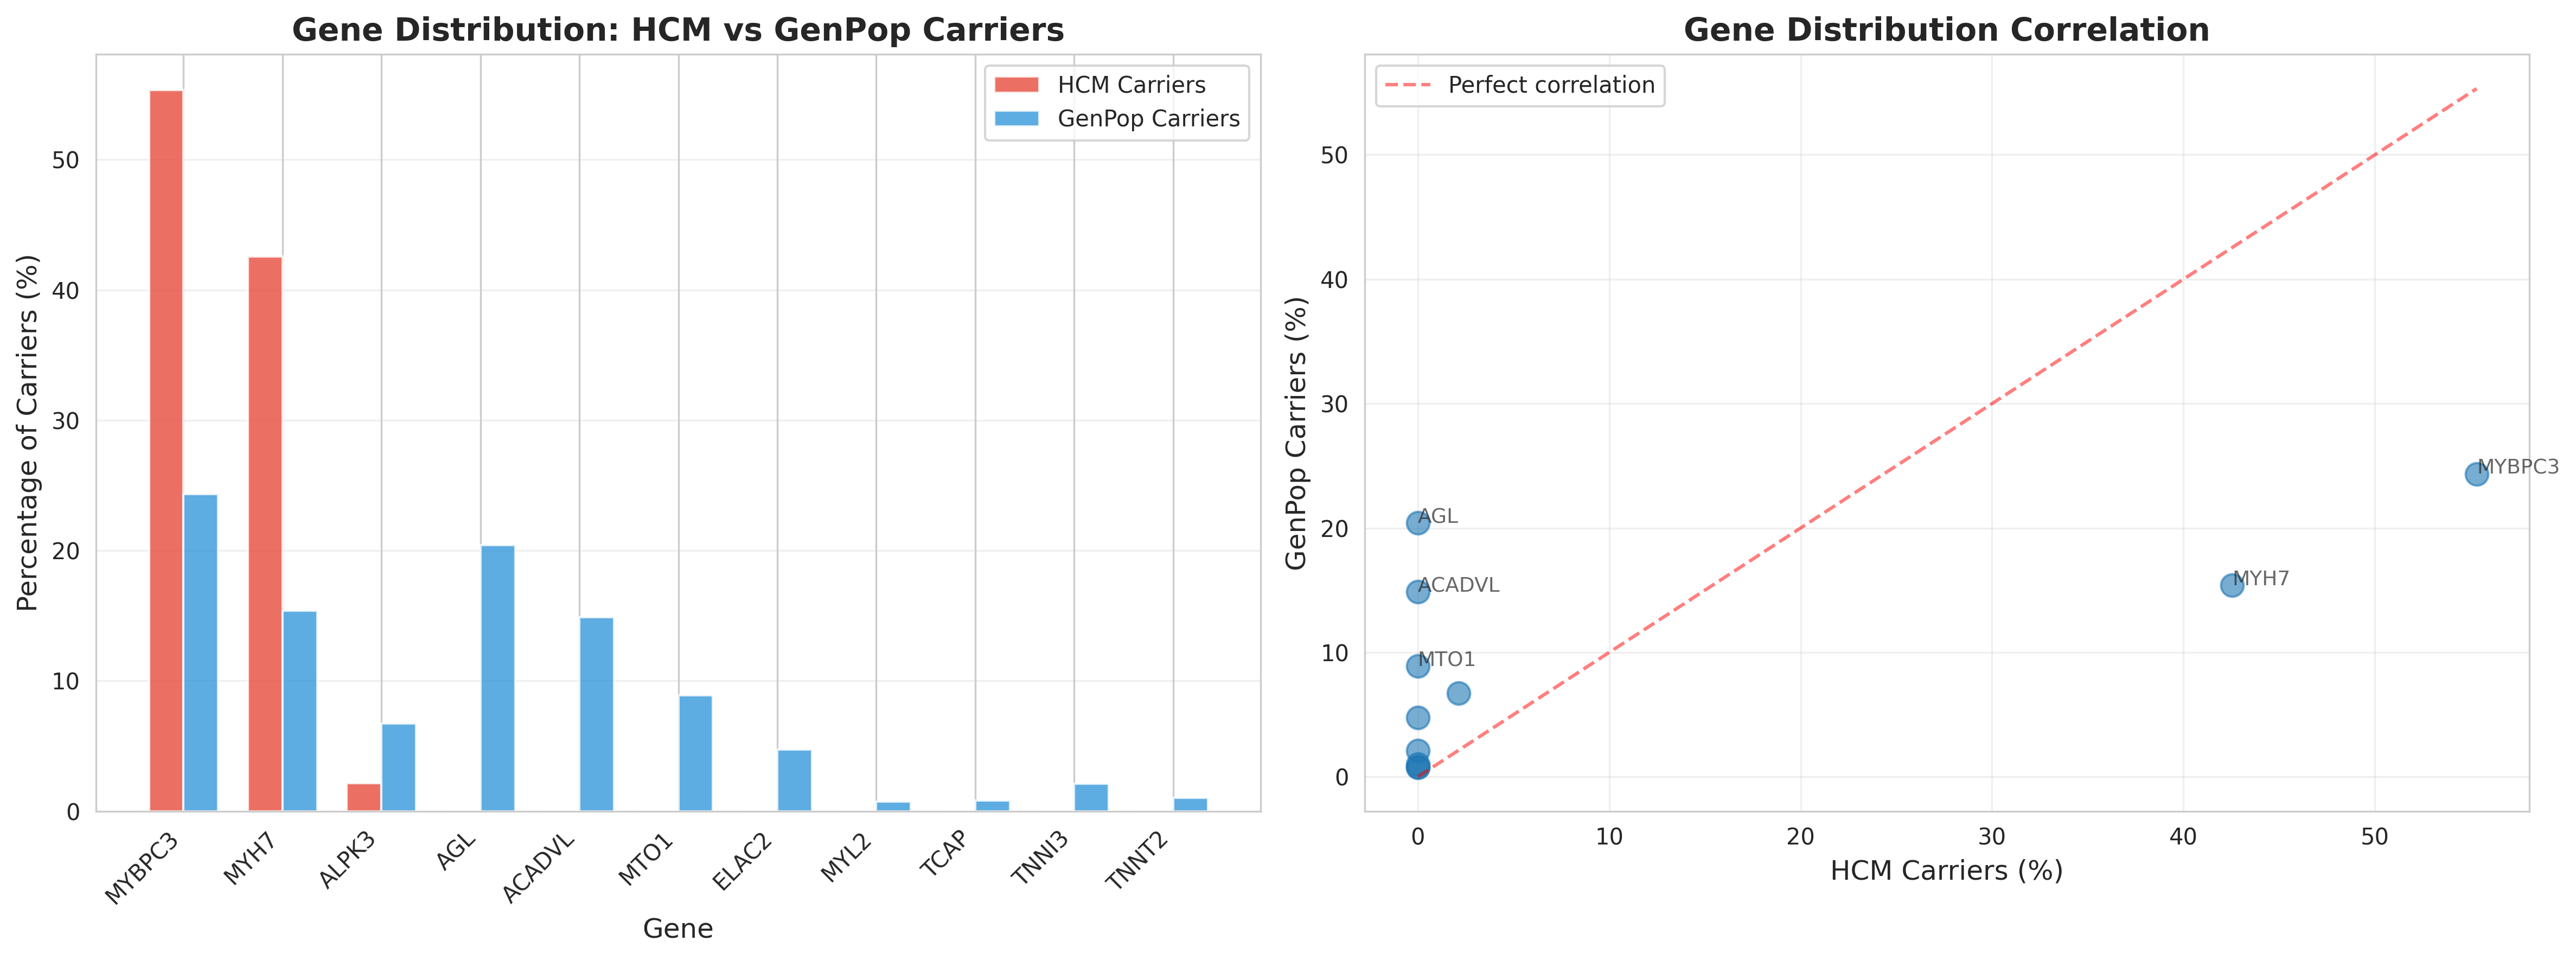


 Plot saved to: /home/jupyter/variant_distribution_comparison.png
 SUMMARY OF KEY DIFFERENCES

Genes with >5% difference in frequency:
        HCM_Carriers_Pct  GenPop_Carriers_Pct  Difference_Pct
Gene                                                         
MYBPC3             55.32                24.34           30.98
MYH7               42.55                15.38           27.17
MTO1                0.00                 8.89           -8.89
ACADVL              0.00                14.87          -14.87
AGL                 0.00                20.41          -20.41


In [18]:
print("COMPARING VARIANT DISTRIBUTION BETWEEN CARRIER GROUPS")

# Load the carrier data
hcm_carriers_df = pd.read_csv('/home/jupyter/Invitae_HCM/hcm_carriers_long_format.tsv', sep='\t')
all_carriers_df = pd.read_csv('/home/jupyter/Invitae_HCM/all_carriers_long_format.tsv', sep='\t')
gen_pop_age20plus = pd.read_csv('/home/jupyter/Invitae_HCM/gen_pop_carriers_age20plus.tsv', sep='\t')

print(f"\nHCM Carriers (long format): {len(hcm_carriers_df):,} records")
print(f"All Carriers (long format): {len(all_carriers_df):,} records")
print(f"GenPop Carriers age ≥20 (person_ids): {len(gen_pop_age20plus):,} person_ids")

# Subset all_carriers to only include GenPop carriers age ≥20
gen_pop_carrier_ids = set(gen_pop_age20plus['person_id'].astype(str))
gen_pop_carriers_df = all_carriers_df[all_carriers_df['IID'].astype(str).isin(gen_pop_carrier_ids)].copy()

print(f"\nGenPop Carriers (age ≥20, long format): {len(gen_pop_carriers_df):,} records")

# Check what columns are available
print("HCM Carriers columns:")
print(hcm_carriers_df.columns.tolist())

print("\nGenPop Carriers columns:")
print(gen_pop_carriers_df.columns.tolist())

# Verify unique individuals
print("Unique individuals:")
print(f"HCM Carriers: {hcm_carriers_df['IID'].nunique():,} unique individuals")
print(f"GenPop Carriers (age ≥20): {gen_pop_carriers_df['IID'].nunique():,} unique individuals")

# 1. Compare by GENE
print("1. DISTRIBUTION BY GENE")

hcm_gene_counts = hcm_carriers_df['Gene'].value_counts()
genpop_gene_counts = gen_pop_carriers_df['Gene'].value_counts()

gene_comparison = pd.DataFrame({
    'HCM_Carriers_Count': hcm_gene_counts,
    'GenPop_Carriers_Count': genpop_gene_counts
}).fillna(0).astype(int)

gene_comparison['HCM_Carriers_Pct'] = (gene_comparison['HCM_Carriers_Count'] / gene_comparison['HCM_Carriers_Count'].sum() * 100).round(2)
gene_comparison['GenPop_Carriers_Pct'] = (gene_comparison['GenPop_Carriers_Count'] / gene_comparison['GenPop_Carriers_Count'].sum() * 100).round(2)
gene_comparison['Difference_Pct'] = (gene_comparison['HCM_Carriers_Pct'] - gene_comparison['GenPop_Carriers_Pct']).round(2)

gene_comparison = gene_comparison.sort_values('HCM_Carriers_Count', ascending=False)

print(gene_comparison)

# 2. Compare by specific VARIANT
print("2. DISTRIBUTION BY VARIANT")

hcm_variant_counts = hcm_carriers_df['variant_id'].value_counts()
genpop_variant_counts = gen_pop_carriers_df['variant_id'].value_counts()

print(f"\nHCM Carriers: {len(hcm_variant_counts)} unique variants")
print(f"GenPop Carriers: {len(genpop_variant_counts)} unique variants")

# Show top 20 most common variants in each group
print("\nTop 20 variants in HCM Carriers:")
print(hcm_variant_counts.head(20))

print("\nTop 20 variants in GenPop Carriers:")
print(genpop_variant_counts.head(20))

# Check overlap
common_variants = set(hcm_variant_counts.index) & set(genpop_variant_counts.index)
print(f"\n{len(common_variants)} variants are shared between both groups")

# 3. Statistical test for gene distribution
print("3. CHI-SQUARE TEST FOR GENE DISTRIBUTION")

# Create contingency table (only genes present in both groups)
common_genes = set(hcm_gene_counts.index) | set(genpop_gene_counts.index)
contingency_data = []
gene_list = []
for gene in common_genes:
    hcm_count = hcm_gene_counts.get(gene, 0)
    genpop_count = genpop_gene_counts.get(gene, 0)
    contingency_data.append([hcm_count, genpop_count])
    gene_list.append(gene)

contingency_table = np.array(contingency_data)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4e}")
print(f"Degrees of freedom: {dof}")

if p_value < 0.05:
    print("\n  The gene distributions are SIGNIFICANTLY DIFFERENT between groups (p < 0.05)")
else:
    print("\n The gene distributions are NOT significantly different between groups (p ≥ 0.05)")

# 4. Visualize the comparison
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Side-by-side bar chart
top_genes = gene_comparison.head(15).index
plot_data = gene_comparison.loc[top_genes, ['HCM_Carriers_Pct', 'GenPop_Carriers_Pct']]

x = np.arange(len(top_genes))
width = 0.35

axes[0].bar(x - width/2, plot_data['HCM_Carriers_Pct'], width, label='HCM Carriers', alpha=0.8, color='#e74c3c')
axes[0].bar(x + width/2, plot_data['GenPop_Carriers_Pct'], width, label='GenPop Carriers', alpha=0.8, color='#3498db')
axes[0].set_xlabel('Gene', fontsize=12)
axes[0].set_ylabel('Percentage of Carriers (%)', fontsize=12)
axes[0].set_title('Gene Distribution: HCM vs GenPop Carriers', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(top_genes, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Scatter plot of percentages
axes[1].scatter(gene_comparison['HCM_Carriers_Pct'], 
                gene_comparison['GenPop_Carriers_Pct'], 
                alpha=0.6, s=100)

# Add diagonal line (perfect correlation)
max_val = max(gene_comparison['HCM_Carriers_Pct'].max(), 
              gene_comparison['GenPop_Carriers_Pct'].max())
axes[1].plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Perfect correlation')

# Label outliers
for gene in gene_comparison.index:
    if abs(gene_comparison.loc[gene, 'Difference_Pct']) > 5:  # Label if >5% difference
        axes[1].annotate(gene, 
                        (gene_comparison.loc[gene, 'HCM_Carriers_Pct'], 
                         gene_comparison.loc[gene, 'GenPop_Carriers_Pct']),
                        fontsize=9, alpha=0.7)

axes[1].set_xlabel('HCM Carriers (%)', fontsize=12)
axes[1].set_ylabel('GenPop Carriers (%)', fontsize=12)
axes[1].set_title('Gene Distribution Correlation', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/home/jupyter/variant_distribution_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Plot saved to: /home/jupyter/variant_distribution_comparison.png")

# 5. Summary of key differences
print(" SUMMARY OF KEY DIFFERENCES")

large_diff_genes = gene_comparison[abs(gene_comparison['Difference_Pct']) > 5].sort_values('Difference_Pct', ascending=False)
if len(large_diff_genes) > 0:
    print(f"\nGenes with >5% difference in frequency:")
    print(large_diff_genes[['HCM_Carriers_Pct', 'GenPop_Carriers_Pct', 'Difference_Pct']])
else:
    print("\nNo genes show >5% difference in frequency between groups")

CHECKING IF PRS DIFFERS BY GENE (MYBPC3 vs MYH7)

HCM Cohort:
  MYBPC3 carriers: 26
  MYH7 carriers: 20

GenPop Cohort:
  MYBPC3 carriers: 334
  MYH7 carriers: 211

PRS data available:
  MYBPC3 HCM: 26
  MYH7 HCM: 20
  MYBPC3 GenPop: 334
  MYH7 GenPop: 211
TEST 1: MYBPC3 vs MYH7 within HCM Cohort

MYBPC3 carriers (HCM):
  Mean PRS: -3.5502
  SD: 0.6912
  Median: -3.6475

MYH7 carriers (HCM):
  Mean PRS: -3.8185
  SD: 0.6368
  Median: -3.6867

T-test: t = 1.3202, p = 1.9360e-01
Cohen's d = 0.4036
 MYBPC3 and MYH7 carriers have SIMILAR PRS distributions in HCM cohort
TEST 2: MYBPC3 vs MYH7 within GenPop

MYBPC3 carriers (GenPop):
  Mean PRS: -4.0191
  SD: 0.6364
  Median: -4.0319

MYH7 carriers (GenPop):
  Mean PRS: -4.0009
  SD: 0.6162
  Median: -3.9848

T-test: t = -0.3299, p = 7.4160e-01
Cohen's d = -0.0292
 MYBPC3 and MYH7 carriers have SIMILAR PRS distributions in GenPop


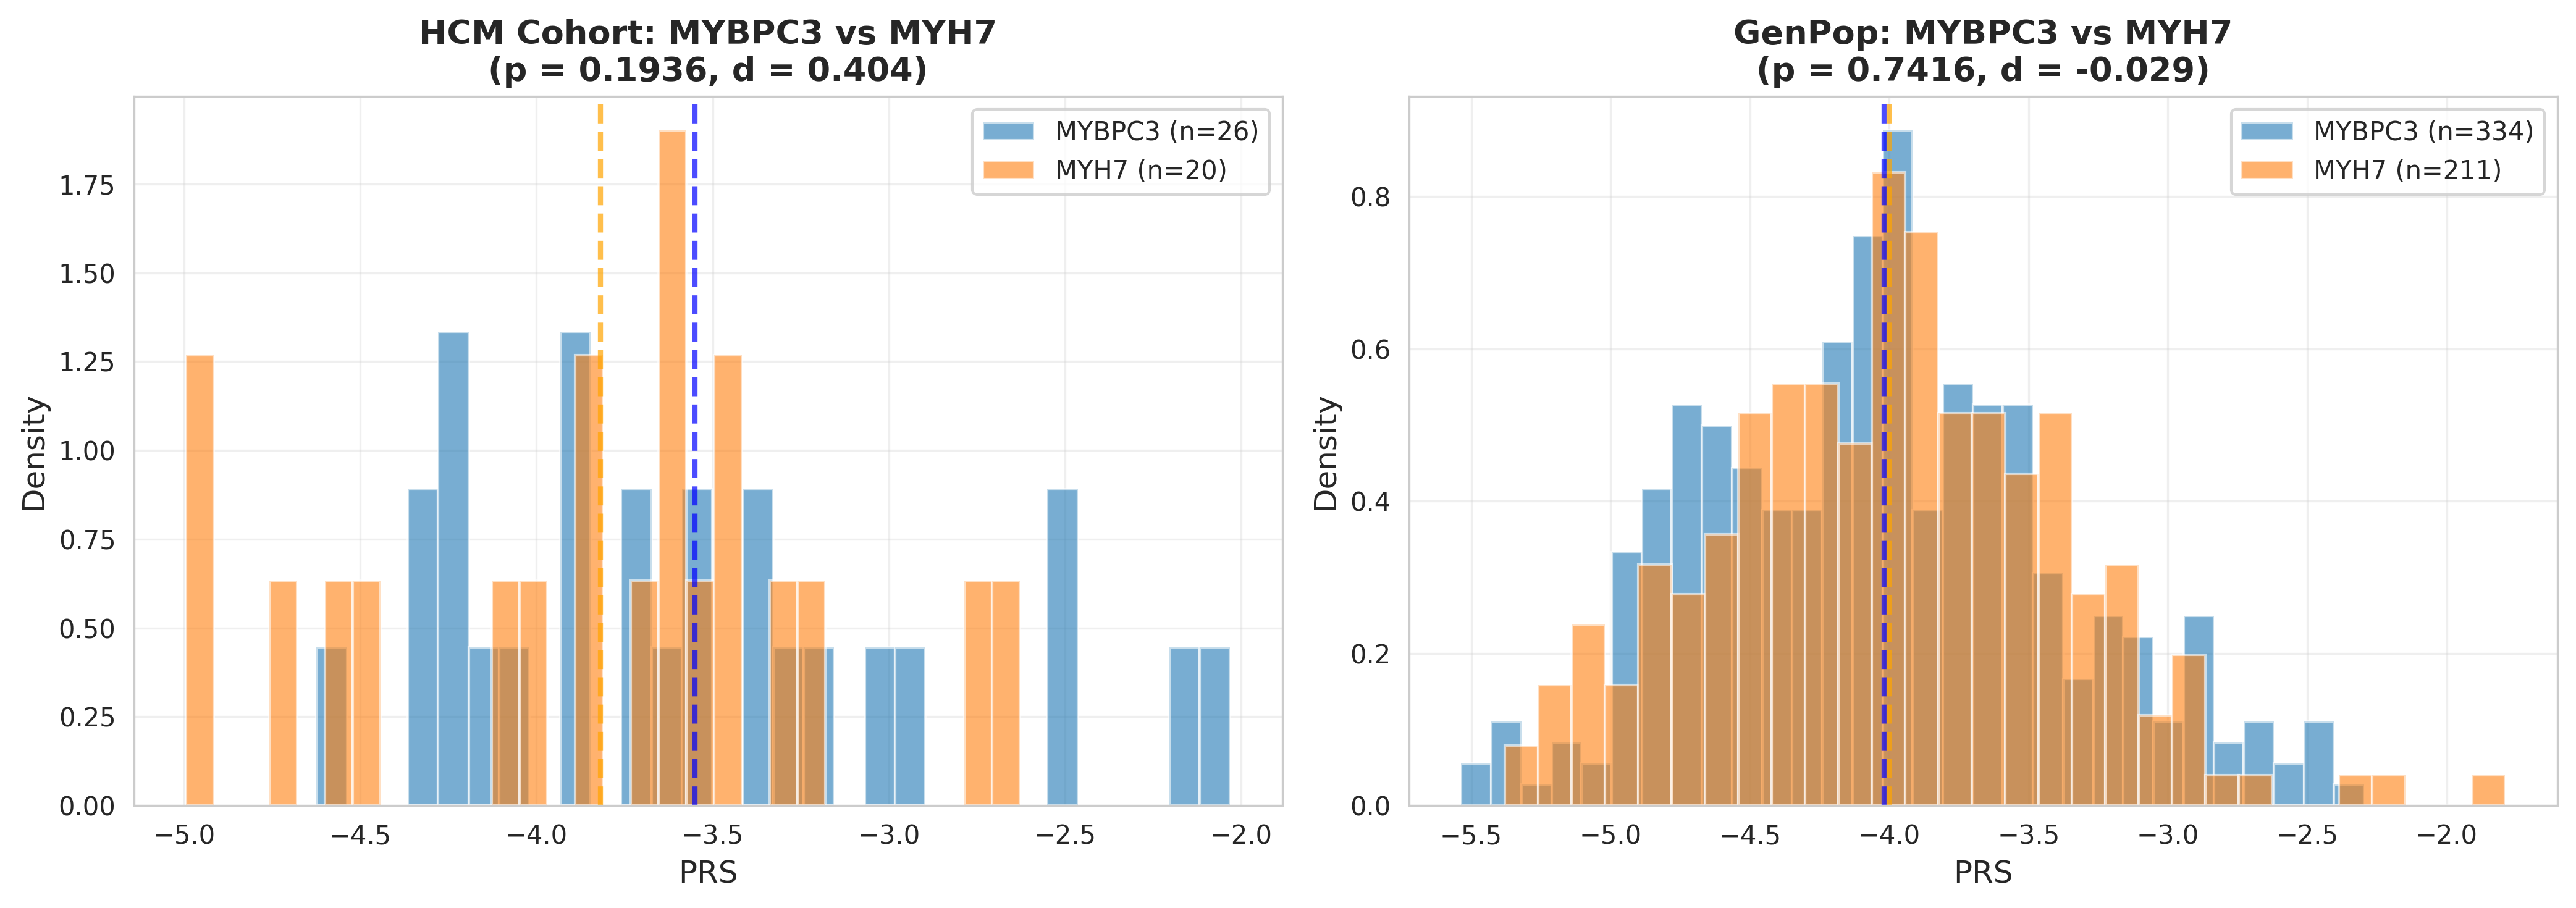


 Plot saved to: /home/jupyter/prs_by_gene_comparison.png

  MYBPC3 and MYH7 have similar PRS distributions


In [19]:
print("CHECKING IF PRS DIFFERS BY GENE (MYBPC3 vs MYH7)")

# Get MYBPC3 and MYH7 carriers from both cohorts
mybpc3_carriers = hcm_carriers_df[hcm_carriers_df['Gene'] == 'MYBPC3']['IID'].unique()
myh7_carriers = hcm_carriers_df[hcm_carriers_df['Gene'] == 'MYH7']['IID'].unique()

mybpc3_genpop = gen_pop_carriers_df[gen_pop_carriers_df['Gene'] == 'MYBPC3']['IID'].unique()
myh7_genpop = gen_pop_carriers_df[gen_pop_carriers_df['Gene'] == 'MYH7']['IID'].unique()

print(f"\nHCM Cohort:")
print(f"  MYBPC3 carriers: {len(mybpc3_carriers):,}")
print(f"  MYH7 carriers: {len(myh7_carriers):,}")

print(f"\nGenPop Cohort:")
print(f"  MYBPC3 carriers: {len(mybpc3_genpop):,}")
print(f"  MYH7 carriers: {len(myh7_genpop):,}")

# Extract PRS for each gene
prs_mybpc3_hcm = get_prs_for_ids(set(mybpc3_carriers), prs_dict)
prs_myh7_hcm = get_prs_for_ids(set(myh7_carriers), prs_dict)
prs_mybpc3_genpop = get_prs_for_ids(set(mybpc3_genpop), prs_dict)
prs_myh7_genpop = get_prs_for_ids(set(myh7_genpop), prs_dict)

print(f"\nPRS data available:")
print(f"  MYBPC3 HCM: {len(prs_mybpc3_hcm):,}")
print(f"  MYH7 HCM: {len(prs_myh7_hcm):,}")
print(f"  MYBPC3 GenPop: {len(prs_mybpc3_genpop):,}")
print(f"  MYH7 GenPop: {len(prs_myh7_genpop):,}")

# Test 1: Do MYBPC3 and MYH7 have different PRS distributions?
print("TEST 1: MYBPC3 vs MYH7 within HCM Cohort")

print(f"\nMYBPC3 carriers (HCM):")
print(f"  Mean PRS: {np.mean(prs_mybpc3_hcm):.4f}")
print(f"  SD: {np.std(prs_mybpc3_hcm):.4f}")
print(f"  Median: {np.median(prs_mybpc3_hcm):.4f}")

print(f"\nMYH7 carriers (HCM):")
print(f"  Mean PRS: {np.mean(prs_myh7_hcm):.4f}")
print(f"  SD: {np.std(prs_myh7_hcm):.4f}")
print(f"  Median: {np.median(prs_myh7_hcm):.4f}")

# T-test
t_stat, p_val = stats.ttest_ind(prs_mybpc3_hcm, prs_myh7_hcm)
cohens_d = (np.mean(prs_mybpc3_hcm) - np.mean(prs_myh7_hcm)) / np.sqrt(
    (np.std(prs_mybpc3_hcm)**2 + np.std(prs_myh7_hcm)**2) / 2
)

print(f"\nT-test: t = {t_stat:.4f}, p = {p_val:.4e}")
print(f"Cohen's d = {cohens_d:.4f}")

if p_val < 0.05:
    print("  MYBPC3 and MYH7 carriers have DIFFERENT PRS distributions in HCM cohort")
else:
    print(" MYBPC3 and MYH7 carriers have SIMILAR PRS distributions in HCM cohort")

#  Do MYBPC3 and MYH7 have different PRS distributions in GenPop?
print("TEST 2: MYBPC3 vs MYH7 within GenPop")

print(f"\nMYBPC3 carriers (GenPop):")
print(f"  Mean PRS: {np.mean(prs_mybpc3_genpop):.4f}")
print(f"  SD: {np.std(prs_mybpc3_genpop):.4f}")
print(f"  Median: {np.median(prs_mybpc3_genpop):.4f}")

print(f"\nMYH7 carriers (GenPop):")
print(f"  Mean PRS: {np.mean(prs_myh7_genpop):.4f}")
print(f"  SD: {np.std(prs_myh7_genpop):.4f}")
print(f"  Median: {np.median(prs_myh7_genpop):.4f}")

# T-test
t_stat2, p_val2 = stats.ttest_ind(prs_mybpc3_genpop, prs_myh7_genpop)
cohens_d2 = (np.mean(prs_mybpc3_genpop) - np.mean(prs_myh7_genpop)) / np.sqrt(
    (np.std(prs_mybpc3_genpop)**2 + np.std(prs_myh7_genpop)**2) / 2
)

print(f"\nT-test: t = {t_stat2:.4f}, p = {p_val2:.4e}")
print(f"Cohen's d = {cohens_d2:.4f}")

if p_val2 < 0.05:
    print("  MYBPC3 and MYH7 carriers have DIFFERENT PRS distributions in GenPop")
else:
    print(" MYBPC3 and MYH7 carriers have SIMILAR PRS distributions in GenPop")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: HCM Cohort
axes[0].hist(prs_mybpc3_hcm, bins=30, alpha=0.6, label=f'MYBPC3 (n={len(prs_mybpc3_hcm)})', density=True)
axes[0].hist(prs_myh7_hcm, bins=30, alpha=0.6, label=f'MYH7 (n={len(prs_myh7_hcm)})', density=True)
axes[0].axvline(np.mean(prs_mybpc3_hcm), color='blue', linestyle='--', linewidth=2, alpha=0.7)
axes[0].axvline(np.mean(prs_myh7_hcm), color='orange', linestyle='--', linewidth=2, alpha=0.7)
axes[0].set_xlabel('PRS', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title(f'HCM Cohort: MYBPC3 vs MYH7\n(p = {p_val:.4f}, d = {cohens_d:.3f})', 
                  fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: GenPop
axes[1].hist(prs_mybpc3_genpop, bins=30, alpha=0.6, label=f'MYBPC3 (n={len(prs_mybpc3_genpop)})', density=True)
axes[1].hist(prs_myh7_genpop, bins=30, alpha=0.6, label=f'MYH7 (n={len(prs_myh7_genpop)})', density=True)
axes[1].axvline(np.mean(prs_mybpc3_genpop), color='blue', linestyle='--', linewidth=2, alpha=0.7)
axes[1].axvline(np.mean(prs_myh7_genpop), color='orange', linestyle='--', linewidth=2, alpha=0.7)
axes[1].set_xlabel('PRS', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title(f'GenPop: MYBPC3 vs MYH7\n(p = {p_val2:.4f}, d = {cohens_d2:.3f})', 
                  fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/home/jupyter/prs_by_gene_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n Plot saved to: /home/jupyter/prs_by_gene_comparison.png")

# Decision guide

if p_val > 0.05 and p_val2 > 0.05:
    print("\n  MYBPC3 and MYH7 have similar PRS distributions")
elif abs(cohens_d) < 0.2 and abs(cohens_d2) < 0.2:
    print("\n ACCEPTABLE: Small effect size difference between genes")
    
else:
    print("\n  MYBPC3 and MYH7 have different PRS distributions")

PENETRANCE ANALYSIS: Risk of HCM by PRS Level

Total carriers analyzed: 1,416
  HCM cases: 46
  Unaffected carriers: 1,370
  Overall penetrance: 3.25%
METHOD 1: TERTILES (Low / Medium / High)
Tertile boundaries: -4.3287, -3.7681

Low (T1):
  Total carriers: 472
  HCM cases: 8
  Penetrance: 1.69% (95% CI: 0.86%-3.31%)

Medium (T2):
  Total carriers: 472
  HCM cases: 12
  Penetrance: 2.54% (95% CI: 1.46%-4.39%)

High (T3):
  Total carriers: 472
  HCM cases: 26
  Penetrance: 5.51% (95% CI: 3.79%-7.95%)

--------------------------------------------------------------------------------
Relative to Low PRS carriers (1.69% penetrance):
  Medium (T2): 1.50x relative risk
  High (T3): 3.25x relative risk
METHOD 2: QUARTILES (Q1 / Q2 / Q3 / Q4)
Quartile boundaries: -4.4759, -4.0554, -3.6141

Q1 (Lowest):
  Total carriers: 354
  HCM cases: 5
  Penetrance: 1.41% (95% CI: 0.60%-3.26%)

Q2:
  Total carriers: 354
  HCM cases: 8
  Penetrance: 2.26% (95% CI: 1.15%-4.40%)

Q3:
  Total carriers: 354
  HCM

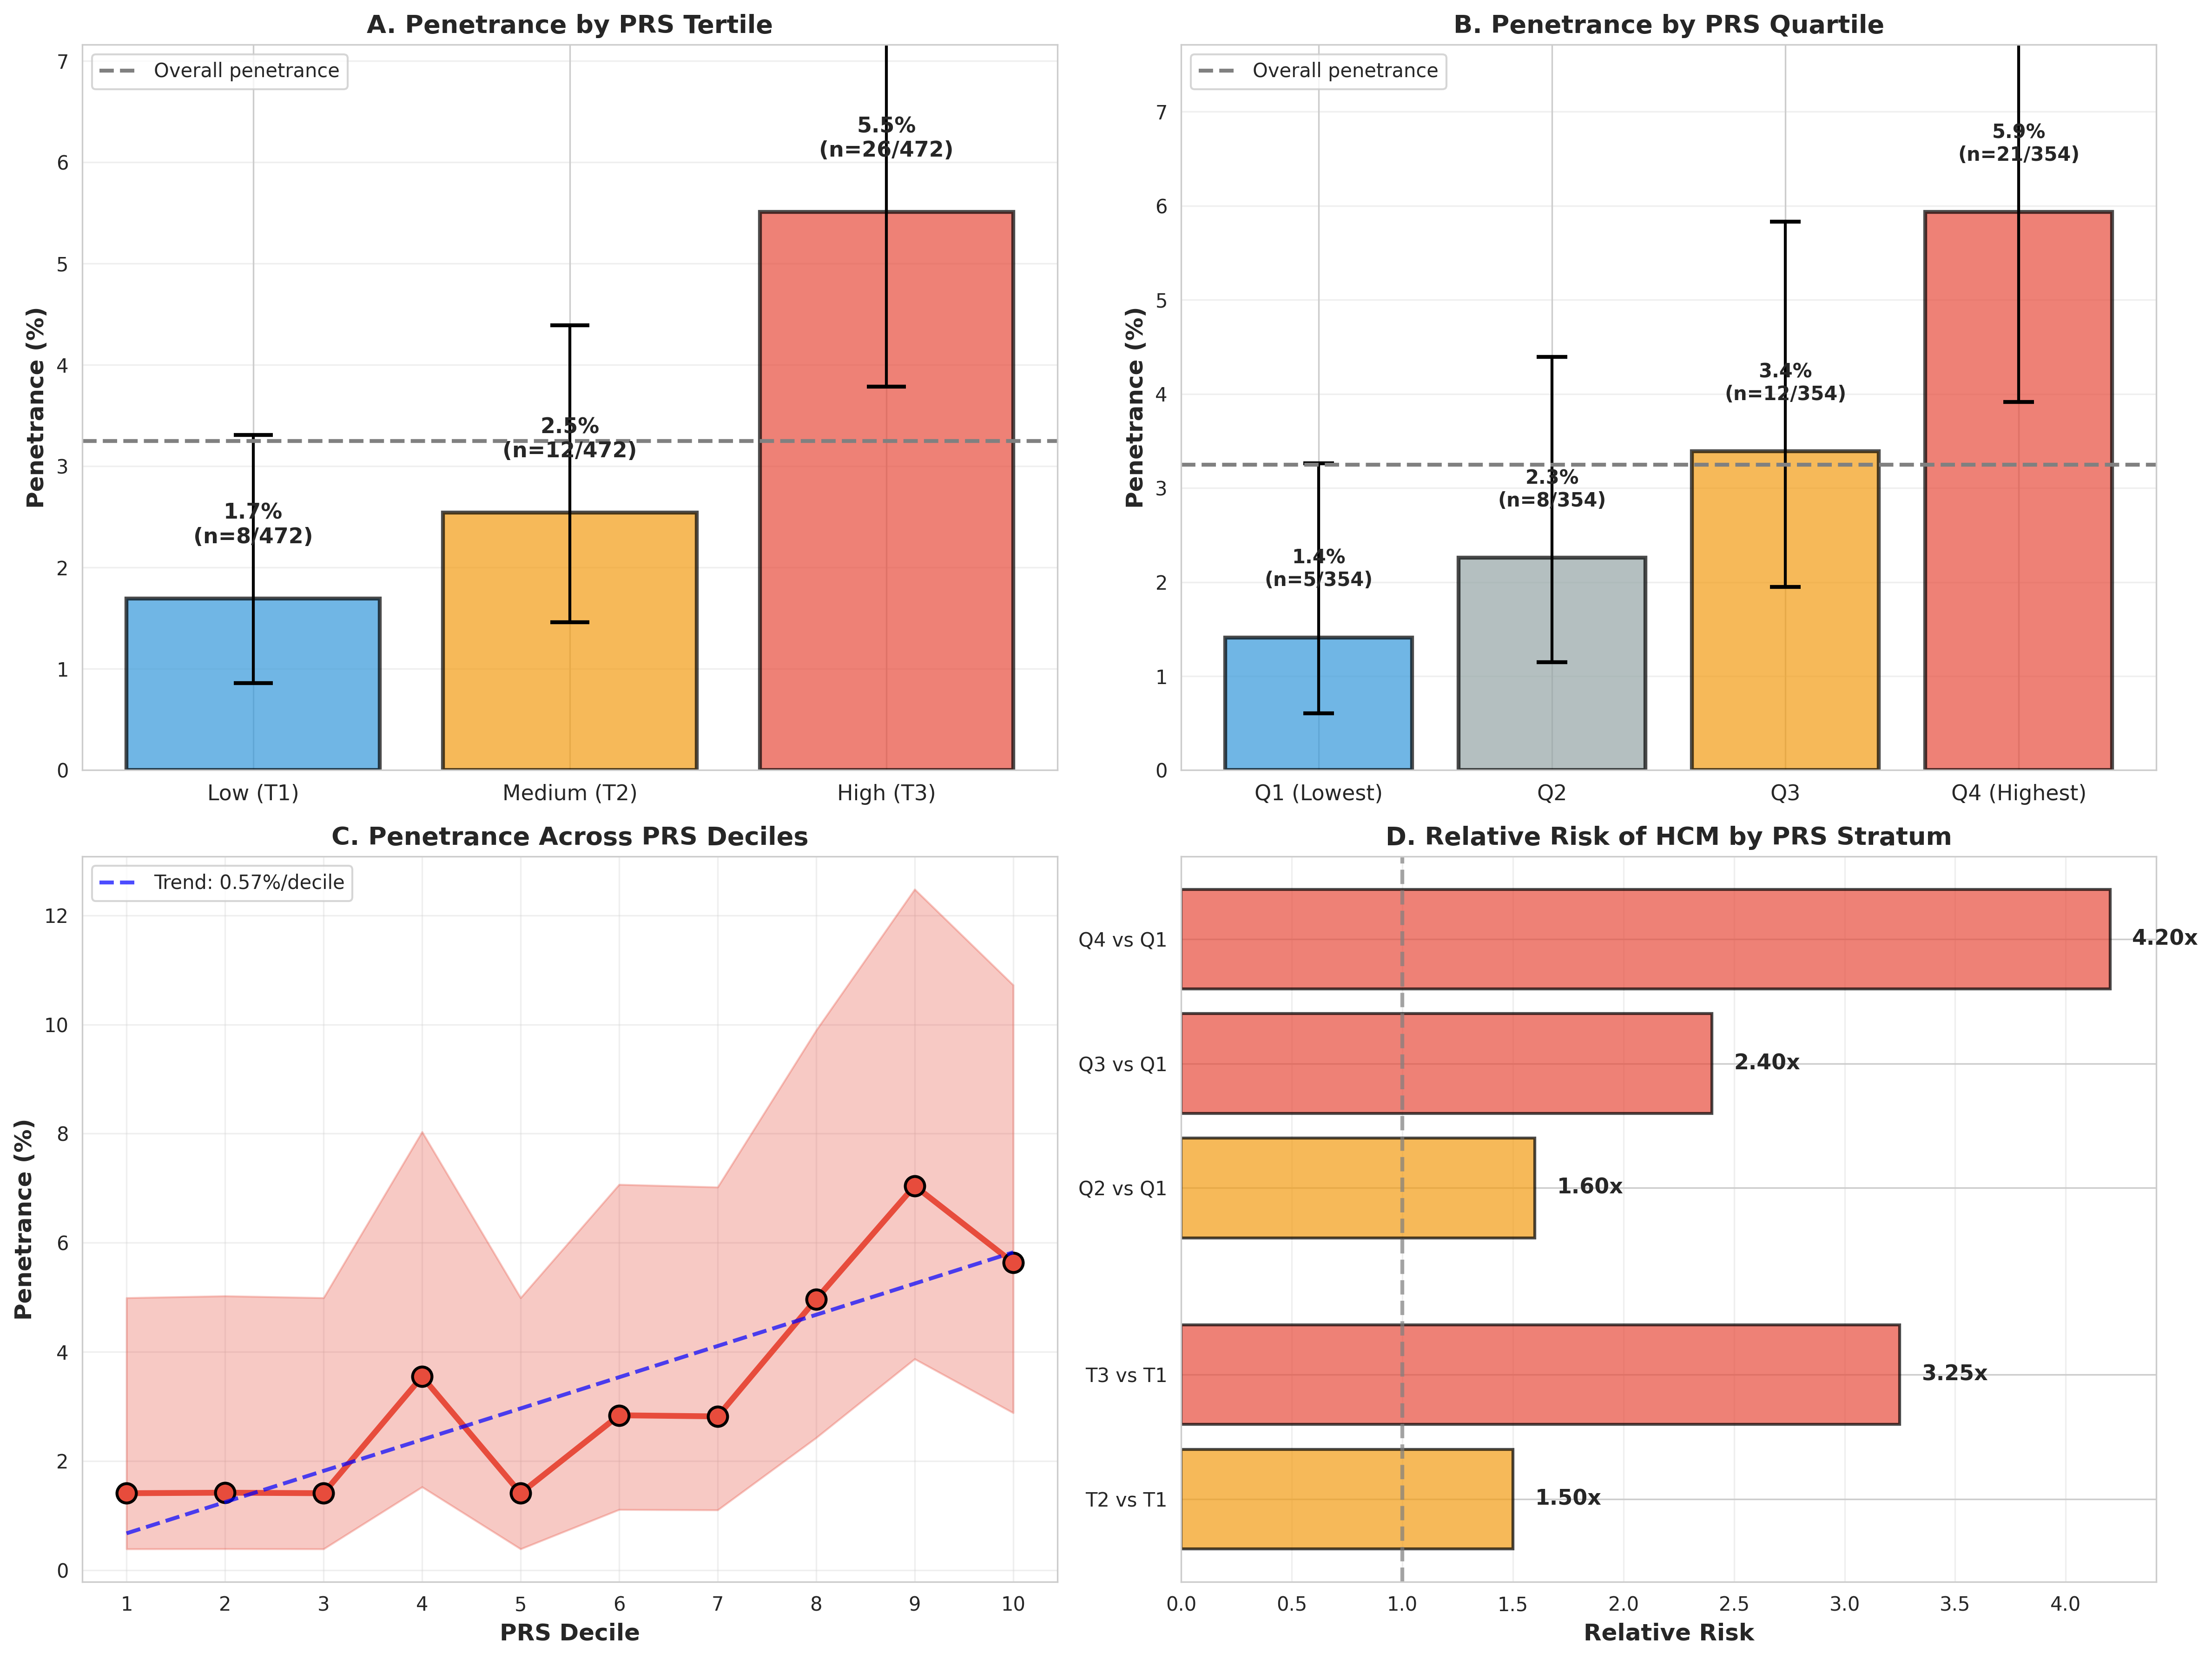

In [15]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

print("PENETRANCE ANALYSIS: Risk of HCM by PRS Level")

# Combine your carrier groups
all_carriers_prs = np.concatenate([prs_hcm_c, prs_genpop_c])
all_carriers_status = np.concatenate([
    np.ones(len(prs_hcm_c)),   # HCM = 1
    np.zeros(len(prs_genpop_c)) # No HCM = 0
])

print(f"\nTotal carriers analyzed: {len(all_carriers_prs):,}")
print(f"  HCM cases: {len(prs_hcm_c):,}")
print(f"  Unaffected carriers: {len(prs_genpop_c):,}")
print(f"  Overall penetrance: {len(prs_hcm_c) / len(all_carriers_prs) * 100:.2f}%")

# Define PRS strata (multiple methods)
print("METHOD 1: TERTILES (Low / Medium / High)")

tertile_thresholds = np.percentile(all_carriers_prs, [33.33, 66.67])
print(f"Tertile boundaries: {tertile_thresholds[0]:.4f}, {tertile_thresholds[1]:.4f}")

# Classify into tertiles
tertile_labels = np.digitize(all_carriers_prs, tertile_thresholds)

tertile_results = []
for t in range(3):
    mask = (tertile_labels == t)
    n_total = np.sum(mask)
    n_hcm = np.sum(all_carriers_status[mask] == 1)
    penetrance = (n_hcm / n_total * 100) if n_total > 0 else 0
    
    # 95% CI for proportion (Wilson score interval)
    if n_total > 0:
        p = n_hcm / n_total
        z = 1.96
        denominator = 1 + z**2 / n_total
        centre = (p + z**2 / (2 * n_total)) / denominator
        spread = z * np.sqrt(p * (1 - p) / n_total + z**2 / (4 * n_total**2)) / denominator
        ci_lower = max(0, (centre - spread) * 100)
        ci_upper = min(100, (centre + spread) * 100)
    else:
        ci_lower = ci_upper = 0
    
    tertile_name = ['Low (T1)', 'Medium (T2)', 'High (T3)'][t]
    
    print(f"\n{tertile_name}:")
    print(f"  Total carriers: {n_total:,}")
    print(f"  HCM cases: {n_hcm}")
    print(f"  Penetrance: {penetrance:.2f}% (95% CI: {ci_lower:.2f}%-{ci_upper:.2f}%)")
    
    tertile_results.append({
        'Stratum': tertile_name,
        'N_total': n_total,
        'N_HCM': n_hcm,
        'Penetrance': penetrance,
        'CI_lower': ci_lower,
        'CI_upper': ci_upper
    })

# Calculate relative risks
low_penetrance = tertile_results[0]['Penetrance']
print(f"\n" + "-"*80)
print(f"Relative to Low PRS carriers ({low_penetrance:.2f}% penetrance):")
for i in range(1, 3):
    rr = tertile_results[i]['Penetrance'] / low_penetrance if low_penetrance > 0 else np.nan
    print(f"  {tertile_results[i]['Stratum']}: {rr:.2f}x relative risk")

# METHOD 2: QUARTILES
print("METHOD 2: QUARTILES (Q1 / Q2 / Q3 / Q4)")

quartile_thresholds = np.percentile(all_carriers_prs, [25, 50, 75])
print(f"Quartile boundaries: {quartile_thresholds[0]:.4f}, {quartile_thresholds[1]:.4f}, {quartile_thresholds[2]:.4f}")

quartile_labels = np.digitize(all_carriers_prs, quartile_thresholds)

quartile_results = []
for q in range(4):
    mask = (quartile_labels == q)
    n_total = np.sum(mask)
    n_hcm = np.sum(all_carriers_status[mask] == 1)
    penetrance = (n_hcm / n_total * 100) if n_total > 0 else 0
    
    if n_total > 0:
        p = n_hcm / n_total
        z = 1.96
        denominator = 1 + z**2 / n_total
        centre = (p + z**2 / (2 * n_total)) / denominator
        spread = z * np.sqrt(p * (1 - p) / n_total + z**2 / (4 * n_total**2)) / denominator
        ci_lower = max(0, (centre - spread) * 100)
        ci_upper = min(100, (centre + spread) * 100)
    else:
        ci_lower = ci_upper = 0
    
    quartile_name = ['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)'][q]
    
    print(f"\n{quartile_name}:")
    print(f"  Total carriers: {n_total:,}")
    print(f"  HCM cases: {n_hcm}")
    print(f"  Penetrance: {penetrance:.2f}% (95% CI: {ci_lower:.2f}%-{ci_upper:.2f}%)")
    
    quartile_results.append({
        'Stratum': quartile_name,
        'N_total': n_total,
        'N_HCM': n_hcm,
        'Penetrance': penetrance,
        'CI_lower': ci_lower,
        'CI_upper': ci_upper
    })

# Calculate relative risks for quartiles
q1_penetrance = quartile_results[0]['Penetrance']
print(f"\n" + "-"*80)
print(f"Relative to Q1 carriers ({q1_penetrance:.2f}% penetrance):")
for i in range(1, 4):
    rr = quartile_results[i]['Penetrance'] / q1_penetrance if q1_penetrance > 0 else np.nan
    print(f"  {quartile_results[i]['Stratum']}: {rr:.2f}x relative risk")

# METHOD 3: DECILES (for more granular view)
print("METHOD 3: DECILES (D1 through D10)")

decile_thresholds = np.percentile(all_carriers_prs, np.arange(10, 100, 10))
decile_labels = np.digitize(all_carriers_prs, decile_thresholds)

decile_results = []
for d in range(10):
    mask = (decile_labels == d)
    n_total = np.sum(mask)
    n_hcm = np.sum(all_carriers_status[mask] == 1)
    penetrance = (n_hcm / n_total * 100) if n_total > 0 else 0
    
    if n_total > 0:
        p = n_hcm / n_total
        z = 1.96
        denominator = 1 + z**2 / n_total
        centre = (p + z**2 / (2 * n_total)) / denominator
        spread = z * np.sqrt(p * (1 - p) / n_total + z**2 / (4 * n_total**2)) / denominator
        ci_lower = max(0, (centre - spread) * 100)
        ci_upper = min(100, (centre + spread) * 100)
    else:
        ci_lower = ci_upper = 0
    
    decile_results.append({
        'Decile': f'D{d+1}',
        'N_total': n_total,
        'N_HCM': n_hcm,
        'Penetrance': penetrance,
        'CI_lower': ci_lower,
        'CI_upper': ci_upper
    })
    
    print(f"D{d+1:2d}: {n_total:>5} carriers, {n_hcm:>3} HCM cases → {penetrance:>5.2f}% penetrance")

# Test for trend
print("TEST FOR TREND")

# Cochran-Armitage trend test
from scipy.stats import chi2

# Use deciles as ordinal exposure
exposure_scores = np.arange(10)
n_cases_by_decile = [r['N_HCM'] for r in decile_results]
n_total_by_decile = [r['N_total'] for r in decile_results]

# Calculate trend statistic
total_cases = sum(n_cases_by_decile)
total_n = sum(n_total_by_decile)
expected_prop = total_cases / total_n

numerator = sum(n_cases_by_decile[i] * exposure_scores[i] for i in range(10)) - \
            expected_prop * sum(n_total_by_decile[i] * exposure_scores[i] for i in range(10))

var_numerator = expected_prop * (1 - expected_prop) * \
                (sum(n_total_by_decile[i] * exposure_scores[i]**2 for i in range(10)) - \
                 (sum(n_total_by_decile[i] * exposure_scores[i] for i in range(10))**2 / total_n))

if var_numerator > 0:
    z_trend = numerator / np.sqrt(var_numerator)
    p_trend = 2 * (1 - stats.norm.cdf(abs(z_trend)))
    print(f"Cochran-Armitage trend test: Z = {z_trend:.3f}, p = {p_trend:.2e}")
    if p_trend < 0.001:
        print("*** Highly significant positive trend")
else:
    print("Cannot calculate trend test")

# VISUALIZATION
print("CREATING VISUALIZATIONS")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel A: Tertile penetrance
ax1 = axes[0, 0]
tertile_names = [r['Stratum'] for r in tertile_results]
tertile_pens = [r['Penetrance'] for r in tertile_results]
tertile_errs = [[r['Penetrance'] - r['CI_lower'] for r in tertile_results],
                [r['CI_upper'] - r['Penetrance'] for r in tertile_results]]

bars1 = ax1.bar(range(3), tertile_pens, color=['#3498db', '#f39c12', '#e74c3c'], 
                alpha=0.7, edgecolor='black', linewidth=2)
ax1.errorbar(range(3), tertile_pens, yerr=tertile_errs, fmt='none', 
             ecolor='black', capsize=10, capthick=2)

for i, (bar, result) in enumerate(zip(bars1, tertile_results)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{result["Penetrance"]:.1f}%\n(n={result["N_HCM"]}/{result["N_total"]})',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_xticks(range(3))
ax1.set_xticklabels(tertile_names, fontsize=11)
ax1.set_ylabel('Penetrance (%)', fontsize=12, fontweight='bold')
ax1.set_title('A. Penetrance by PRS Tertile', fontsize=13, fontweight='bold')
ax1.set_ylim(0, max(tertile_pens) * 1.3)
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(len(prs_hcm_c) / len(all_carriers_prs) * 100, 
            color='gray', linestyle='--', linewidth=2, label='Overall penetrance')
ax1.legend()

# Panel B: Quartile penetrance
ax2 = axes[0, 1]
quartile_names = [r['Stratum'] for r in quartile_results]
quartile_pens = [r['Penetrance'] for r in quartile_results]
quartile_errs = [[r['Penetrance'] - r['CI_lower'] for r in quartile_results],
                 [r['CI_upper'] - r['Penetrance'] for r in quartile_results]]

colors_q = ['#3498db', '#95a5a6', '#f39c12', '#e74c3c']
bars2 = ax2.bar(range(4), quartile_pens, color=colors_q, alpha=0.7, 
                edgecolor='black', linewidth=2)
ax2.errorbar(range(4), quartile_pens, yerr=quartile_errs, fmt='none',
             ecolor='black', capsize=8, capthick=2)

for i, (bar, result) in enumerate(zip(bars2, quartile_results)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{result["Penetrance"]:.1f}%\n(n={result["N_HCM"]}/{result["N_total"]})',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_xticks(range(4))
ax2.set_xticklabels(quartile_names, fontsize=11)
ax2.set_ylabel('Penetrance (%)', fontsize=12, fontweight='bold')
ax2.set_title('B. Penetrance by PRS Quartile', fontsize=13, fontweight='bold')
ax2.set_ylim(0, max(quartile_pens) * 1.3)
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(len(prs_hcm_c) / len(all_carriers_prs) * 100,
            color='gray', linestyle='--', linewidth=2, label='Overall penetrance')
ax2.legend()

# Panel C: Decile trend
ax3 = axes[1, 0]
decile_nums = np.arange(1, 11)
decile_pens = [r['Penetrance'] for r in decile_results]
decile_ci_lower = [r['CI_lower'] for r in decile_results]
decile_ci_upper = [r['CI_upper'] for r in decile_results]

ax3.plot(decile_nums, decile_pens, 'o-', color='#e74c3c', linewidth=3, 
         markersize=10, markeredgecolor='black', markeredgewidth=1.5)
ax3.fill_between(decile_nums, decile_ci_lower, decile_ci_upper, 
                 alpha=0.3, color='#e74c3c')

# Add trend line
z = np.polyfit(decile_nums, decile_pens, 1)
p = np.poly1d(z)
ax3.plot(decile_nums, p(decile_nums), "--", color='blue', linewidth=2, 
         alpha=0.7, label=f'Trend: {z[0]:.2f}%/decile')

ax3.set_xlabel('PRS Decile', fontsize=12, fontweight='bold')
ax3.set_ylabel('Penetrance (%)', fontsize=12, fontweight='bold')
ax3.set_title('C. Penetrance Across PRS Deciles', fontsize=13, fontweight='bold')
ax3.set_xticks(decile_nums)
ax3.grid(True, alpha=0.3)
ax3.legend()

# Panel D: Relative risk comparison
ax4 = axes[1, 1]

# Calculate relative risks relative to lowest tertile
rr_data = {
    'Tertiles': {
        'labels': ['T2 vs T1', 'T3 vs T1'],
        'rr': [
            tertile_results[1]['Penetrance'] / tertile_results[0]['Penetrance'],
            tertile_results[2]['Penetrance'] / tertile_results[0]['Penetrance']
        ]
    },
    'Quartiles': {
        'labels': ['Q2 vs Q1', 'Q3 vs Q1', 'Q4 vs Q1'],
        'rr': [
            quartile_results[1]['Penetrance'] / quartile_results[0]['Penetrance'],
            quartile_results[2]['Penetrance'] / quartile_results[0]['Penetrance'],
            quartile_results[3]['Penetrance'] / quartile_results[0]['Penetrance']
        ]
    }
}

y_pos = 0
yticks = []
ytick_labels = []
for method, data in rr_data.items():
    for label, rr in zip(data['labels'], data['rr']):
        color = '#e74c3c' if '3' in label or '4' in label else '#f39c12'
        ax4.barh(y_pos, rr, color=color, alpha=0.7, edgecolor='black', linewidth=1.5)
        ax4.text(rr + 0.1, y_pos, f'{rr:.2f}x', va='center', fontsize=11, fontweight='bold')
        yticks.append(y_pos)
        ytick_labels.append(label)
        y_pos += 1
    y_pos += 0.5  # Space between methods

ax4.axvline(1, color='gray', linestyle='--', linewidth=2, alpha=0.7)
ax4.set_yticks(yticks)
ax4.set_yticklabels(ytick_labels, fontsize=10)
ax4.set_xlabel('Relative Risk', fontsize=12, fontweight='bold')
ax4.set_title('D. Relative Risk of HCM by PRS Stratum', fontsize=13, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('penetrance_by_prs_stratification.png', dpi=300, bbox_inches='tight')
print(" Saved: 'penetrance_by_prs_stratification.png'")

# Save results to CSV
print("SAVING RESULTS")

# Tertile results
tertile_df = pd.DataFrame(tertile_results)
tertile_df.to_csv('penetrance_by_tertile.csv', index=False)
print(" Saved: 'penetrance_by_tertile.csv'")

# Quartile results
quartile_df = pd.DataFrame(quartile_results)
quartile_df.to_csv('penetrance_by_quartile.csv', index=False)
print(" Saved: 'penetrance_by_quartile.csv'")

# Decile results
decile_df = pd.DataFrame(decile_results)
decile_df.to_csv('penetrance_by_decile.csv', index=False)
print(" Saved: 'penetrance_by_decile.csv'")

# Summary table
print("SUMMARY TABLE FOR MANUSCRIPT")

summary = f"""
PENETRANCE OF HCM BY PRS STRATIFICATION

Overall penetrance: {len(prs_hcm_c) / len(all_carriers_prs) * 100:.2f}% 
({len(prs_hcm_c)}/{len(all_carriers_prs)} carriers)

TERTILE ANALYSIS:
  Low PRS (T1):    {tertile_results[0]['Penetrance']:.2f}% ({tertile_results[0]['N_HCM']}/{tertile_results[0]['N_total']})
  Medium PRS (T2): {tertile_results[1]['Penetrance']:.2f}% ({tertile_results[1]['N_HCM']}/{tertile_results[1]['N_total']})  [{tertile_results[1]['Penetrance']/tertile_results[0]['Penetrance']:.2f}x vs T1]
  High PRS (T3):   {tertile_results[2]['Penetrance']:.2f}% ({tertile_results[2]['N_HCM']}/{tertile_results[2]['N_total']})  [{tertile_results[2]['Penetrance']/tertile_results[0]['Penetrance']:.2f}x vs T1]

QUARTILE ANALYSIS:
  Q1 (Lowest):  {quartile_results[0]['Penetrance']:.2f}% ({quartile_results[0]['N_HCM']}/{quartile_results[0]['N_total']})
  Q2:           {quartile_results[1]['Penetrance']:.2f}% ({quartile_results[1]['N_HCM']}/{quartile_results[1]['N_total']})  [{quartile_results[1]['Penetrance']/quartile_results[0]['Penetrance']:.2f}x vs Q1]
  Q3:           {quartile_results[2]['Penetrance']:.2f}% ({quartile_results[2]['N_HCM']}/{quartile_results[2]['N_total']})  [{quartile_results[2]['Penetrance']/quartile_results[0]['Penetrance']:.2f}x vs Q1]
  Q4 (Highest): {quartile_results[3]['Penetrance']:.2f}% ({quartile_results[3]['N_HCM']}/{quartile_results[3]['N_total']})  [{quartile_results[3]['Penetrance']/quartile_results[0]['Penetrance']:.2f}x vs Q1]

KEY FINDING:
Carriers in the highest PRS tertile have {tertile_results[2]['Penetrance']/tertile_results[0]['Penetrance']:.1f}-fold 
increased penetrance compared to lowest tertile carriers.
"""

print(summary)

with open('penetrance_summary.txt', 'w') as f:
    f.write(summary)
print("\n Saved: 'penetrance_summary.txt'")